In [2]:
## Import libraries and shape file for Germany

import numpy as np
import matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt 
import rasterio
from scipy.integrate import quad
from scipy.special import erf, i0
from scipy.optimize import fsolve, minimize_scalar
from joblib import Parallel, delayed
import folium
from folium import plugins
from io import BytesIO
import base64
import warnings
import geopandas as gpd

# Optional: suppress integration warnings for cleaner output.
warnings.filterwarnings("ignore", category=UserWarning)

# 1) Download a worldwide countries GeoJSON from GitHub 
#    (public domain: https://github.com/datasets/geo-countries).
world_url = "https://raw.githubusercontent.com/datasets/geo-countries/master/data/countries.geojson"
world = gpd.read_file(world_url)

# 2) Filter for Germany and ensure it is lat/lon (EPSG:4326).
#    Depending on the dataset, the column might be named 'ADMIN', 'NAME', etc.
germany_shape = world[world["name"] == "Germany"].to_crs(epsg=4326)

# Confirm that germany_shape is correct:
print(f"Found {len(germany_shape)} shape(s) for Germany.")


Found 1 shape(s) for Germany.


In [3]:
# Function definition

def MeanMFLS(am, Lm, ql, vt, H, r, t):
    lower_limit = (r**2) / (4.0 * am * t)
    def integrand(tc):
        term1 = (1.0 / tc) * np.exp(-tc - ((r * vt / (4.0 * am))**2) / tc)
        term2 = (4.0 * erf(H * np.sqrt(tc) / r)
                 - 2.0 * erf(2.0 * H * np.sqrt(tc) / r)
                 + (4.0 * r / (H * np.sqrt(np.pi * tc))) * np.exp(-tc * (H / r)**2)
                 - (r / (H * np.sqrt(np.pi * tc))) * np.exp(-tc * (2.0 * H / r)**2)
                 - 3.0 * r / (H * np.sqrt(np.pi * tc)))
        return term1 * term2
    val, _ = quad(integrand, lower_limit, np.inf, epsabs=1e-4, epsrel=1e-4)
    return (ql / (8.0 * Lm * np.pi)) * i0(r * vt / (2.0 * am)) * val

def MeanTempInfinitePlane(H, t, Tm, Ta, to, s, am):
    lower_limit = (H**2) / (4.0 * am * t)
    def integrand(tc):
        return (1.0 / (2.0 * (tc**1.5))) * (1.0 - np.exp(-tc)) * (
            Tm + Ta * np.cos(2.0 * np.pi * ((t / to) - (H**2) / (4.0 * am * tc * to) + s))
        )
    val, _ = quad(integrand, lower_limit, np.inf, epsabs=1e-4, epsrel=1e-4)
    return val / np.sqrt(np.pi)

def MeanTempIni(H, t, Ts, am, k):
    return Ts * (erf(H / np.sqrt(4.0 * am * t))
                 + (2.0 / H) * np.sqrt(am * t / np.pi) 
                   * (np.exp(-(H**2)/(4.0*am*t)) - 1.0)
                ) + k * H / 2.0

def meanFluidTemp(am, Lm, ql, vt, H, r, t, Ts, k, Rtb):
    return -MeanMFLS(am, Lm, ql, vt, H, r, t) - Rtb * ql + (Ts + Ts + k * H) * 0.5

def findQlsustainSingle(turban, am, Lm, ql, vt, H, rb, Tm, Ta, to, s, Ts, k, Rtb, Tmin):
    def meanTotalFluidTemp(am, Lm, ql_, vt, H_, r_, t_, turban_, Ts_, k_, Tm_, Ta_, to_, s_, Rtb_):
        return (-MeanMFLS(am, Lm, ql_, vt, H_, r_, t_) +
                MeanTempInfinitePlane(H_, t_ + turban_, Tm_, Ta_, to_, s_, am) +
                MeanTempIni(H_, t_ + turban_, Ts_, am, k_) -
                Rtb_ * ql_)

    def objective_function(t_, ql_):
        return meanTotalFluidTemp(am, Lm, ql_, vt, H, rb, t_, turban, Ts, k,
                                  Tm + Ts, Ta, to, s, Rtb)  # Tm + Ts is as per your original usage

    if Tm != 0:
        qlo = 1.0
        qlf = 40.0
        res1 = minimize_scalar(lambda t_: objective_function(t_, qlo),
                               bounds=(0.5*365*86400, 5000000*365*86400),
                               method='bounded')
        minto = res1.x
        minTo = objective_function(minto, qlo)
        res2 = minimize_scalar(lambda t_: objective_function(t_, qlf),
                               bounds=(0.5*365*86400, 5000000*365*86400),
                               method='bounded')
        mintf = res2.x
        minTf = objective_function(mintf, qlf)
        res3 = minimize_scalar(lambda t_: objective_function(t_, ql),
                               bounds=(0.5*365*86400, 5000000*365*86400),
                               method='bounded')
        mint_ = res3.x
        minT = objective_function(mint_, ql)
        while abs(minT - Tmin) > 0.001:
            if minT > Tmin:
                qlo = ql
                minTo = minT
            else:
                qlf = ql
                minTf = minT
            denom = (minTf - minTo)
            if abs(denom) < 1e-14:
                break
            ql = qlf - (qlf - qlo) * (minTf - Tmin) / denom
            res4 = minimize_scalar(lambda t_: objective_function(t_, ql),
                                   bounds=(0.5*365*86400, 5000000*365*86400),
                                   method='bounded')
            mint_ = res4.x
            minT = objective_function(mint_, ql)
        return ql, mint_
    else:
        mint_ = 5e6 * 365 * 86400
        denom = MeanMFLS(am, Lm, 1.0, vt, H, rb, mint_) + Rtb
        ql_ = ((2.0 * Ts + k * H) * 0.5 - Tmin) / denom
        return ql_, mint_

def meanTotalFluidTemp_main(am, Lm, ql, vt, H, r, t, turban, Ts, k, Tm, Ta, to, s, Rtb):
    return (-MeanMFLS(am, Lm, ql, vt, H, r, t) +
            MeanTempInfinitePlane(H, t + turban, Tm, Ta, to, s, am) +
            MeanTempIni(H, t + turban, Ts, am, k) -
            Rtb * ql)


In [4]:
# Model Varibales and Parameters definiton

am = 1e-6        # thermal diffusivity [m^2/s]
H = 150          # Borehole depth [m]
Lm = 2.5         # Borehole spacing [m]
vt = 0           # groundwater advection speed [m/s]
r = 0.06         # borehole radius for MFLS [m]
rb = 0.1         # borehole radius for fluid temperature evaluation [m]
Ts = 10          # fixed initial temperature [°C]
k = 0.03         # geothermal gradient [°C/m]
Ta = 0           # seasonal temperature amplitude or change
to = 1           # period (not used if Ta==0)
s = 1            # phase shift

t50 = 50 * 365 * 86400    # 50 years in seconds
Tmin = -1.5               # minimum acceptable fluid temperature [°C]
turban_sec = np.array([0, 100]) * 365 * 86400   # urban delay scenarios: 0 and 100 years
time_long = 100 * 365 * 86400  # 100-year horizon
Rtb = 0.15                     # borehole thermal resistance


In [5]:
# Helper Functions (Colorbars, Overlays, etc.)

def create_colorbar_image(cmap_name, vmin, vmax, orientation='vertical',
                          width=50, height=300, n_ticks=6):
    """
    Creates a colorbar PNG image and returns it as base64-encoded string.
    """
    fig, ax = plt.subplots(figsize=(width/100, height/100))
    norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = mpl.colormaps.get_cmap(cmap_name)
    cbar = matplotlib.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation=orientation)
    
    # define ticks
    ticks = np.linspace(vmin, vmax, n_ticks)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([f"{val:.1f}" for val in ticks])
    ax.tick_params(labelsize=8)

    buf = BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', pad_inches=0.05)
    plt.close(fig)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode('utf-8')

def add_fixed_legend(m, legend_id, cmap_name, vmin, vmax, position='left', 
                     top_px=50, width=50, height=300, legend_title=""):
    """
    Places a fixed legend on the Folium map using base64-encoded colorbar PNG.
    """
    html_children = m.get_root().html._children
    if legend_id in html_children:
        del html_children[legend_id]

    cb_img = create_colorbar_image(cmap_name, vmin, vmax, orientation='vertical',
                                   width=width, height=height, n_ticks=6)

    side = 'left' if position == 'left' else 'right'

    # The title is added as an extra div at the top of the map
    title_html = ""
    if legend_title:
        title_html = f"""
        <div style="text-align:center; font-weight:bold; font-size:12px; padding:4px;">
            {legend_title}
        </div>
        """
    
    fixed_html = f"""
    <div id="{legend_id}" style="
         position: fixed;
         top: {top_px}px;
         {side}: 10px;
         z-index: 9999;
         border: 2px solid grey;
         background-color: rgba(255,255,255,0.8);
         text-align: center;
    ">
         {title_html}
         <img src="data:image/png;base64,{cb_img}" 
              style="width:{width}px; height:{height}px;">
    </div>
    """
    m.get_root().html.add_child(folium.Element(fixed_html))

def create_image_overlay(data, extent, cmap_name='plasma'):
    """
    Converts a 2D NumPy array (data) into a PNG with given colormap,
    returns base64 string for Folium ImageOverlay.
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(data, cmap=cmap_name, extent=extent, origin='upper')
    ax.axis('off')
    buf = BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', pad_inches=0)
    plt.close(fig)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode('utf-8')

def add_overlay_to_map(m, data, layer_name, cmap_name, extent, opacity=0.7,
                       vmin=None, vmax=None):
    """
    Add a custom overlay to the folium map. Optionally specify a vmin and vmax
    to control color scale across all layers using that colormap.
    """
    # set vmin, vmax
    plt.ioff()
    fig, ax = plt.subplots(figsize=(8, 6))
    # If vmin,vmax are not None, pass them to imshow for consistent scale
    im = ax.imshow(data, cmap=cmap_name, extent=extent, origin='upper',
                   vmin=vmin, vmax=vmax)
    ax.axis('off')

    buf = BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', pad_inches=0)
    plt.close(fig)
    plt.ion()
    buf.seek(0)

    img_data = base64.b64encode(buf.read()).decode('utf-8')
    image_bounds = [[extent[2], extent[0]], [extent[3], extent[1]]]
    folium.raster_layers.ImageOverlay(
        image='data:image/png;base64,{}'.format(img_data),
        bounds=image_bounds,
        opacity=opacity,
        name=layer_name,
        show=False
    ).add_to(m)

def add_germany_boundary(m, germany_gdf, name="Germany Boundary", style_kwargs=None):
    """
    Adds the Germany boundary from a GeoDataFrame to the map.
    """
    if style_kwargs is None:
        style_kwargs = {"fill": False, "color": "black", "weight": 2}
    folium.GeoJson(data=germany_gdf.__geo_interface__,
                   name=name,
                   style_function=lambda x: style_kwargs
                  ).add_to(m)


In [6]:
# Main Model for (2) Technical Potential (50-year) and (3) Sustainable Rates (100-year)

def run_model_for_geotiff(geotiff_path, ds_factor=10):
    """
    Loads the input GeoTIFF, downsample it, runs your model (Sections 2 & 3),
    and returns a dictionary of the relevant arrays for later mapping.
    """
    import rasterio

    # --- 1. Load and Downsample Tm ---
    with rasterio.open(geotiff_path) as src:
        Tm_data = src.read(1)
        transform = src.transform
        extent = (src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top)

    Tm_map = Tm_data[::ds_factor, ::ds_factor]
    ny, nx = Tm_map.shape
    print(f"Loaded '{geotiff_path}' with shape {Tm_data.shape}.")
    print(f"Downsampled to shape: {Tm_map.shape}")
    print("Extent:", extent)

    # Pre-allocate results
    # Section 2
   # ql_NoUrban_map = np.zeros_like(Tm_map)
    ql_Urban_map   = np.zeros((ny, nx, len(turban_sec)))
    EnerUrb_map    = np.zeros((ny, nx, len(turban_sec)))

    # Section 3
    ql_UrbanRenew_map     = np.zeros((ny, nx, len(turban_sec)))
    ql_UrbanRenew_max_map = np.zeros((ny, nx, len(turban_sec)))
    EnerUrbRenew_map      = np.zeros((ny, nx, len(turban_sec)))

    # --- 2. Section 2: Technical Potential (50-year) ---
    #     For each pixel, compute ql_noUrban, ql_urban, etc.
    for i in range(ny):
        for j in range(nx):
            Tm_local = Tm_map[i, j]

            # # No urban delay
            # def fzero_no_urban(ql_guess, Tm_local):
            #     T_inf = MeanTempInfinitePlane(H, t50, Tm_local, Ta, to, s, am)
            #     T_ini = MeanTempIni(H, t50, Ts, am, k)
            #     val = -MeanMFLS(am, Lm, ql_guess, vt, H, rb, t50) + T_inf + T_ini - (Rtb * ql_guess)
            #     return val - Tmin

            # sol_no = fsolve(lambda ql: fzero_no_urban(ql, Tm_local), 10.0, xtol=1e-5)[0]
            # ql_NoUrban_map[i, j] = sol_no

            # Urban scenarios
            for idx, turban in enumerate(turban_sec):
                def fzero_urban(ql_guess, Tm_local):
                    T_inf = MeanTempInfinitePlane(H, t50, Tm_local, Ta, to, s, am)
                    T_ini = MeanTempIni(H, t50, Ts, am, k)
                    val = -MeanMFLS(am, Lm, ql_guess, vt, H, rb, t50) + T_inf + T_ini - (Rtb * ql_guess)
                    return val - Tmin

                sol_urb = fsolve(lambda ql: fzero_urban(ql, Tm_local), 10.0, xtol=1e-5)[0]
                ql_Urban_map[i, j, idx] = sol_urb
                EnerUrb_map[i, j, idx]  = sol_urb * H  # W = ql * H ?

    # --- 3. Section 3: Sustainable Rates (100-year horizon) ---
    # For each pixel compute ql_UrbanRenew_map, ql_UrbanRenew_max_map, ...
    for i in range(ny):
        for j in range(nx):
            Tm_local = Tm_map[i, j]
            for idx, turban in enumerate(turban_sec):
                # Start with guess ql=2
                ql_guess = 2.0
                ql_sol, mint_sol = findQlsustainSingle(turban, am, Lm, ql_guess, vt, H, rb,
                                                       Tm_local, Ta, to, s, Ts, k, Rtb, Tmin)
                ql_UrbanRenew_map[i, j, idx] = ql_sol

                # "Max sustainable rate"
                # as in your original code, Tm=0 => Tm + Ts = Ts, so we pass "0"? 
                # But you had a second call:
                ql_sol2, _ = findQlsustainSingle(turban, am, Lm, ql_guess, vt, H, rb,
                                                 0, Ta, to, s, Ts + Tm_local, k, Rtb, Tmin)
                ql_UrbanRenew_max_map[i, j, idx] = ql_sol2
                EnerUrbRenew_map[i, j, idx]      = ql_sol * H

    # Return a dictionary with all relevant data
    results = {
        "Tm_map": Tm_map,
        "extent": extent,
        # Section 2
        #"ql_NoUrban_map": ql_NoUrban_map,
        "ql_Urban_map": ql_Urban_map,
        "EnerUrb_map": EnerUrb_map,
        # Section 3
        "ql_UrbanRenew_map": ql_UrbanRenew_map,
        "ql_UrbanRenew_max_map": ql_UrbanRenew_max_map,
        "EnerUrbRenew_map": EnerUrbRenew_map
    }

    return results


In [14]:
# Load your GeoTIFF file and run the model (Sections 2 & 3)
# -------------------------------------------------------------------

# Provide your local file path here, including directories if needed.
geotiff_path = "BBC_ssp245_2000_2100_Germany_mean.tif"

# Choose a downsampling factor. Larger factors speed up the computation but lose spatial detail.
ds_factor = 10

# Run the model to get the results dictionary, which includes:
#  - ql_NoUrban_map, ql_Urban_map, EnerUrb_map  (Section 2)
#  - ql_UrbanRenew_map, ql_UrbanRenew_max_map, EnerUrbRenew_map (Section 3)
BBC_ssp245 = run_model_for_geotiff(
    geotiff_path=geotiff_path, 
    ds_factor=ds_factor
)

print("Model run completed for:", geotiff_path)
print("Results stored in 'BBC_ssp245'")

Loaded 'BBC_ssp245_2000_2100_Germany_mean.tif' with shape (176, 203).
Downsampled to shape: (18, 21)
Extent: (5.8839651109828655, 15.001865244796008, 47.2962997088928, 55.20147420914459)


/tmp/ipykernel_109826/3595534842.py:57: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sol_urb = fsolve(lambda ql: fzero_urban(ql, Tm_local), 10.0, xtol=1e-5)[0]


Model run completed for: BBC_ssp245_2000_2100_Germany_mean.tif
Results stored in 'BBC_ssp245'


[50-yr] ql_Urban delay=0yr → vmin=10.00, vmax=27.03
[50-yr] EnerUrb delay=0yr → vmin=1500.00, vmax=4054.28
[100-yr] ql_UrbanRenew delay=0yr → vmin=2.00, vmax=31.09
[100-yr] EnerUrbRenew delay=0yr → vmin=300.00, vmax=4664.04
[100-yr] ql_UrbanRenew_max delay=100yr → vmin=39.62, vmax=46.24
[100-yr] EnerUrbRenew delay=100yr → vmin=300.00, vmax=5517.92



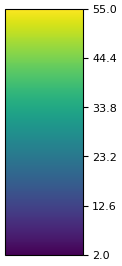
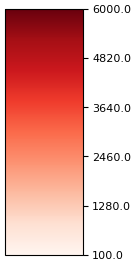
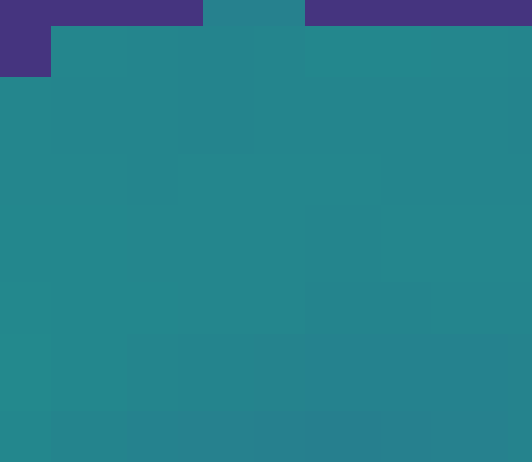
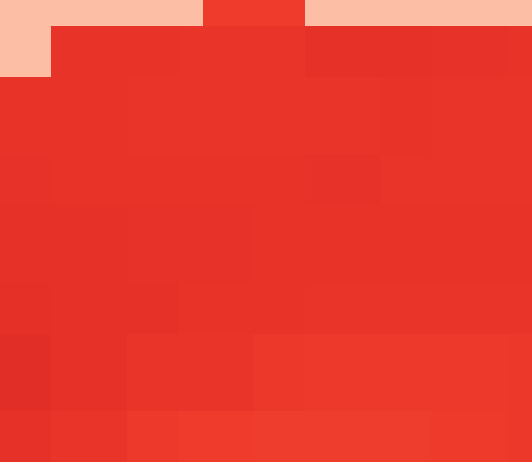
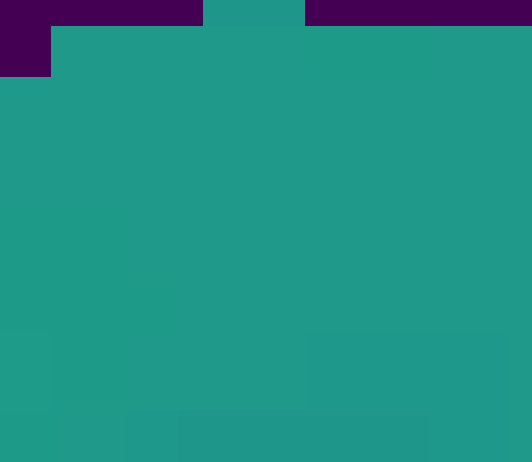
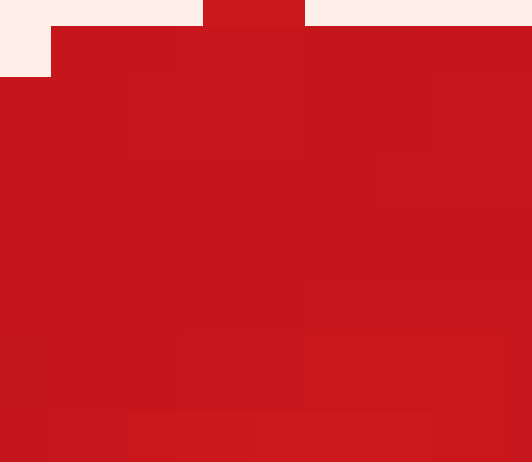
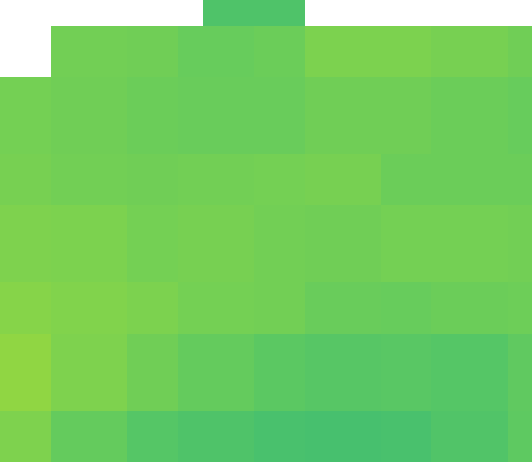
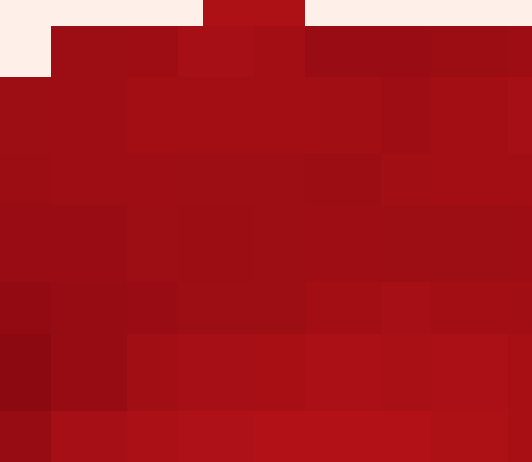

In [15]:
# Create the Folium map with custom settings
# ----------------------------------------------------

def create_folium_map_and_layers(results_dict, germany_gdf, 
                                 map_title="",
                                 overlay_opacity=0.7):
    """
    Creates a folium map, adds all relevant layers for:
      - Section 2 (50-year horizon)
      - Section 3 (100-year horizon)
    using the same naming style as the older code.

    Parameters
    ----------
    results_dict    : dict with keys:
                      - ql_NoUrban_map
                      - ql_Urban_map
                      - EnerUrb_map
                      - ql_UrbanRenew_map
                      - ql_UrbanRenew_max_map
                      - EnerUrbRenew_map
                      - extent
    germany_gdf     : GeoDataFrame for Germany boundary
    map_title       : Title to display at top of the map
    overlay_opacity : Float in [0..1], controlling overlay transparency
    """

    # 1) Basic map creation
    extent = results_dict["extent"]
    
    # Compute center lat/lon from extent
    center_lat = 0.5*(extent[2] + extent[3])
    center_lon = 0.5*(extent[0] + extent[1])
    
    m = folium.Map(location=[center_lat, center_lon], zoom_start=5, 
                   tiles="cartodbpositron")  # or any tile you prefer

    # 2) Add Germany boundary
    add_germany_boundary(m, germany_gdf, name="Germany Boundary")

    # 3) Extract arrays from results
    #ql_NoUrban_map        = results_dict["ql_NoUrban_map"]
    ql_Urban_map          = results_dict["ql_Urban_map"]
    EnerUrb_map           = results_dict["EnerUrb_map"]
    ql_UrbanRenew_map     = results_dict["ql_UrbanRenew_map"]
    ql_UrbanRenew_max_map = results_dict["ql_UrbanRenew_max_map"]
    EnerUrbRenew_map      = results_dict["EnerUrbRenew_map"]
    
    # 4) Define color scales for extraction rate and power
    #    (Adjust as needed for your data)
    ql_vmin,  ql_vmax  = 2, 55      # W/m
    pwr_vmin, pwr_vmax = 100, 6000   # W
    


    # -----------------------------
    # Section 2 (50-year horizon)
    # -----------------------------
    # 4a) No-Urban Delay
    # add_overlay_to_map(
    #     m, ql_NoUrban_map, 
    #     "ql_NoUrban (W/m)",          
    #     cmap_name="viridis", 
    #     extent=extent, 
    #     opacity=overlay_opacity, 
    #     vmin=None, 
    #     vmax=None
    # )

    # 4b) For each "urban delay" scenario: ql_Urban, EnerUrb
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))  # =0→50yrs
    arr_ql_Urban = ql_Urban_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_Urban), np.nanmax(arr_ql_Urban)
    print(f"[50-yr] ql_Urban delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    #for idx, turban in enumerate(turban_sec):
        #years = int(turban / (365*86400))
    add_overlay_to_map(
            m, arr_ql_Urban,
            f"Max Heat Extraction Rate [W/m] (no sustainable, turban = {yrs})",  
            cmap_name="viridis",
            extent=extent,
            opacity=overlay_opacity,
            vmin=ql_vmin,
            vmax=ql_vmax
        )
    # EnerUrb
    arr_EnerUrb = EnerUrb_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrb), np.nanmax(arr_EnerUrb)
    print(f"[50-yr] EnerUrb delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_EnerUrb,
            f"Usable Power [W] (turban = {yrs})",  
            cmap_name="Reds",
            extent=extent,
            opacity=overlay_opacity,
            vmin=pwr_vmin,
            vmax=pwr_vmax
        )

    # --------------------------------
    # Section 3 (100-year horizon)
    # --------------------------------
    # 4c) For each "urban delay" scenario: ql_UrbanRenew, ql_UrbanRenew_max, EnerUrbRenew
    # ----- 100-yr, idx=0 -----
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))
    #for idx, turban in enumerate(turban_sec):
        #years = int(turban / (365*86400))
     # ql_UrbanRenew
    arr_ql_UrbanRenew = ql_UrbanRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_UrbanRenew), np.nanmax(arr_ql_UrbanRenew)
    print(f"[100-yr] ql_UrbanRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_ql_UrbanRenew,
            f"Sustainable Heat Extraction Rate [W/m] (turban = {yrs})",  
            cmap_name="viridis",
            extent=extent,
            opacity=overlay_opacity,
            vmin=ql_vmin,
            vmax=ql_vmax
        )
    # EnerUrbRenew
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))
    arr_EnerUrbRenew = EnerUrbRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrbRenew), np.nanmax(arr_EnerUrbRenew)
    print(f"[100-yr] EnerUrbRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_EnerUrbRenew,
            f"Usable Power [W] under non-renewable rates (turban = {yrs})",  
            cmap_name="Reds",
            extent=extent,
            opacity=overlay_opacity,
            vmin=pwr_vmin,
            vmax=pwr_vmax
        )
        # add_overlay_to_map(
        #     m, EnerUrbRenew_map[:, :, idx],
        #     f"Usable Power under renewable rates [W] (sustainable, 100 years)turban = {years}",  
        #     cmap_name="Reds",
        #     extent=extent,
        #     opacity=overlay_opacity,
        #     vmin=None,
        #     vmax=None
        # )
    # ----- 100-yr max, idx=1 -----
    idx = 1
    yrs = int(turban_sec[idx] / (365*86400))
    # ql_UrbanRenew_max
    arr_ql_UrbanRenew_max = ql_UrbanRenew_max_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_UrbanRenew_max), np.nanmax(arr_ql_UrbanRenew_max)
    print(f"[100-yr] ql_UrbanRenew_max delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
        m, arr_ql_UrbanRenew_max,
        f"Max Sustainable Heat Extraction Rate [W/m] (turban = {yrs})",
        cmap_name="viridis", extent=extent,
        opacity=overlay_opacity, 
        vmin=ql_vmin,
        vmax=ql_vmax
    )
    # EnerUrbRenew again
    idx = 1
    yrs = int(turban_sec[idx] / (365*86400))
    arr_EnerUrbRenew_S = EnerUrbRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrbRenew_S), np.nanmax(arr_EnerUrbRenew_S)
    print(f"[100-yr] EnerUrbRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
        m, arr_EnerUrbRenew_S,
        f"Usable Power under renewable rates [W] (sustainable, turban = {yrs})",
        cmap_name="Reds", extent=extent,
        opacity=overlay_opacity, 
        vmin=pwr_vmin,
        vmax=pwr_vmax
    )

    # 5) Add a layer control so user can toggle layers
    folium.LayerControl().add_to(m)

    # 6) Add colorbar legends for ql (viridis) and power (plasma)
    add_fixed_legend(
        m, "fixed_legend_viridis",
        cmap_name="viridis",
        vmin=ql_vmin, vmax=ql_vmax,
        position='left', top_px=300,
        width=100, height=320,
        legend_title="Heat Extraction Rate (W/m)"
    )
    add_fixed_legend(
        m, "fixed_legend_Reds",
        cmap_name="Reds",
        vmin=pwr_vmin, vmax=pwr_vmax,
        position='right', top_px=300,
        width=100, height=320,
        legend_title="Usable Power (W)"
    )

    # 7) Add a title at the top
    map_title_html = f"""
    <div style="
        position: fixed;
        top: 5px;
        left: 50%;
        transform: translateX(-50%);
        z-index: 9999;
        font-size: 12px;
        font-weight: bold;
        background-color: rgba(255,255,255,0.8);
        padding: 4px;
        border: 1px solid grey;
    ">
      {map_title}
    </div>
    """
    m.get_root().html.add_child(folium.Element(map_title_html))

    return m
# Now we actually create and show the map with a custom title
custom_map_title = "Single BHE Analysis with GEE CMIP6 BBC Model (ssp245)"
overlay_opacity  = 0.7   # Adjust as you wish

m = create_folium_map_and_layers(
    results_dict=BBC_ssp245,
    germany_gdf=germany_shape,
    map_title=custom_map_title,
    overlay_opacity=overlay_opacity
)
m.save("folium_map.html")
m



In [16]:
# Load your GeoTIFF file and run the model (Sections 2 & 3)
# -------------------------------------------------------------------

# Provide your local file path here, including directories if needed.
geotiff_path = "BBC_ssp585_2000_2100_Germany_mean.tif"

# Choose a downsampling factor. Larger factors speed up the computation but lose spatial detail.
ds_factor = 10

# Run the model to get the results dictionary, which includes:
#  - ql_NoUrban_map, ql_Urban_map, EnerUrb_map  (Section 2)
#  - ql_UrbanRenew_map, ql_UrbanRenew_max_map, EnerUrbRenew_map (Section 3)
BBC_ssp585 = run_model_for_geotiff(
    geotiff_path=geotiff_path, 
    ds_factor=ds_factor
)

print("Model run completed for:", geotiff_path)
print("Results stored in 'BBC_ssp585'")

Loaded 'BBC_ssp585_2000_2100_Germany_mean.tif' with shape (176, 203).
Downsampled to shape: (18, 21)
Extent: (5.8839651109828655, 15.001865244796008, 47.2962997088928, 55.20147420914459)


/tmp/ipykernel_109826/3595534842.py:57: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sol_urb = fsolve(lambda ql: fzero_urban(ql, Tm_local), 10.0, xtol=1e-5)[0]


Model run completed for: BBC_ssp585_2000_2100_Germany_mean.tif
Results stored in 'BBC_ssp585'


[50-yr] ql_Urban delay=0yr → vmin=10.00, vmax=27.34
[50-yr] EnerUrb delay=0yr → vmin=1500.00, vmax=4101.61
[100-yr] ql_UrbanRenew delay=0yr → vmin=2.00, vmax=31.24
[100-yr] EnerUrbRenew delay=0yr → vmin=300.00, vmax=4686.56
[100-yr] ql_UrbanRenew_max delay=100yr → vmin=40.92, vmax=47.25
[100-yr] EnerUrbRenew delay=100yr → vmin=300.00, vmax=5594.02



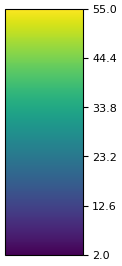
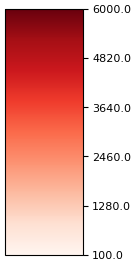
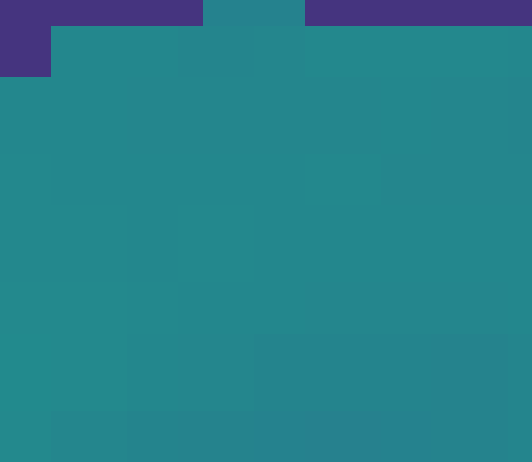
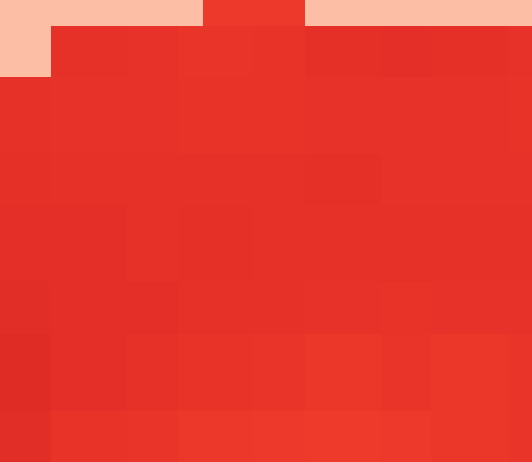
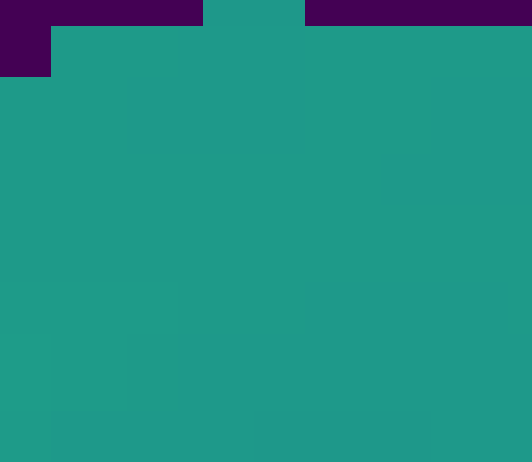
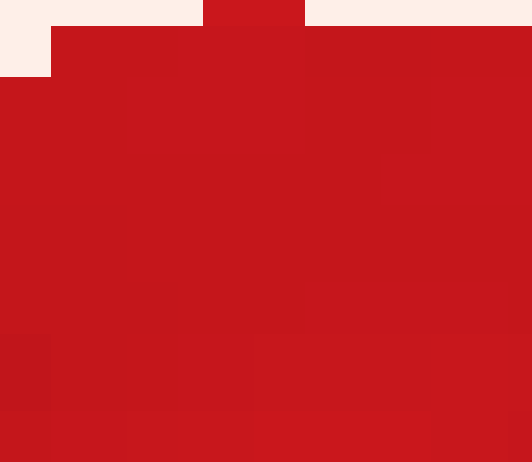
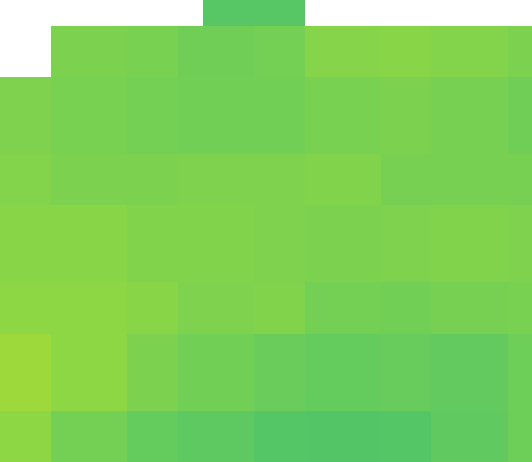
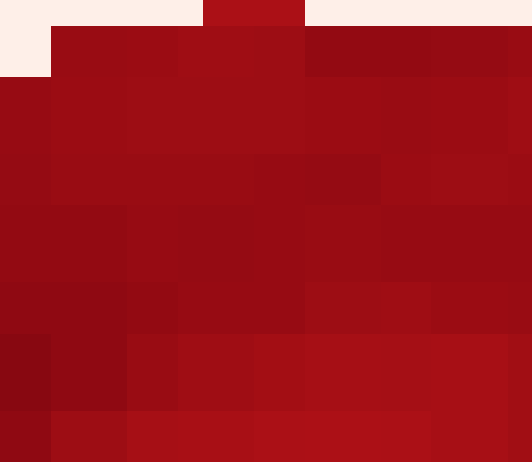

In [17]:
# Create the Folium map with custom settings
# ----------------------------------------------------

def create_folium_map_and_layers(results_dict, germany_gdf, 
                                 map_title="",
                                 overlay_opacity=0.7):
    """
    Creates a folium map, adds all relevant layers for:
      - Section 2 (50-year horizon)
      - Section 3 (100-year horizon)
    using the same naming style as the older code.

    Parameters
    ----------
    results_dict    : dict with keys:
                      - ql_NoUrban_map
                      - ql_Urban_map
                      - EnerUrb_map
                      - ql_UrbanRenew_map
                      - ql_UrbanRenew_max_map
                      - EnerUrbRenew_map
                      - extent
    germany_gdf     : GeoDataFrame for Germany boundary
    map_title       : Title to display at top of the map
    overlay_opacity : Float in [0..1], controlling overlay transparency
    """

    # 1) Basic map creation
    extent = results_dict["extent"]
    
    # Compute center lat/lon from extent
    center_lat = 0.5*(extent[2] + extent[3])
    center_lon = 0.5*(extent[0] + extent[1])
    
    m = folium.Map(location=[center_lat, center_lon], zoom_start=5, 
                   tiles="cartodbpositron")  # or any tile you prefer

    # 2) Add Germany boundary
    add_germany_boundary(m, germany_gdf, name="Germany Boundary")

    # 3) Extract arrays from results
    #ql_NoUrban_map        = results_dict["ql_NoUrban_map"]
    ql_Urban_map          = results_dict["ql_Urban_map"]
    EnerUrb_map           = results_dict["EnerUrb_map"]
    ql_UrbanRenew_map     = results_dict["ql_UrbanRenew_map"]
    ql_UrbanRenew_max_map = results_dict["ql_UrbanRenew_max_map"]
    EnerUrbRenew_map      = results_dict["EnerUrbRenew_map"]
    
    # 4) Define color scales for extraction rate and power
    #    (Adjust as needed for your data)
    ql_vmin,  ql_vmax  = 2, 55      # W/m
    pwr_vmin, pwr_vmax = 100, 6000   # W
    


    # -----------------------------
    # Section 2 (50-year horizon)
    # -----------------------------
    # 4a) No-Urban Delay
    # add_overlay_to_map(
    #     m, ql_NoUrban_map, 
    #     "ql_NoUrban (W/m)",          
    #     cmap_name="viridis", 
    #     extent=extent, 
    #     opacity=overlay_opacity, 
    #     vmin=None, 
    #     vmax=None
    # )

    # 4b) For each "urban delay" scenario: ql_Urban, EnerUrb
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))  # =0→50yrs
    arr_ql_Urban = ql_Urban_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_Urban), np.nanmax(arr_ql_Urban)
    print(f"[50-yr] ql_Urban delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    #for idx, turban in enumerate(turban_sec):
        #years = int(turban / (365*86400))
    add_overlay_to_map(
            m, arr_ql_Urban,
            f"Max Heat Extraction Rate [W/m] (no sustainable, turban = {yrs})",  
            cmap_name="viridis",
            extent=extent,
            opacity=overlay_opacity,
            vmin=ql_vmin,
            vmax=ql_vmax
        )
    # EnerUrb
    arr_EnerUrb = EnerUrb_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrb), np.nanmax(arr_EnerUrb)
    print(f"[50-yr] EnerUrb delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_EnerUrb,
            f"Usable Power [W] (turban = {yrs})",  
            cmap_name="Reds",
            extent=extent,
            opacity=overlay_opacity,
            vmin=pwr_vmin,
            vmax=pwr_vmax
        )

    # --------------------------------
    # Section 3 (100-year horizon)
    # --------------------------------
    # 4c) For each "urban delay" scenario: ql_UrbanRenew, ql_UrbanRenew_max, EnerUrbRenew
    # ----- 100-yr, idx=0 -----
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))
    #for idx, turban in enumerate(turban_sec):
        #years = int(turban / (365*86400))
     # ql_UrbanRenew
    arr_ql_UrbanRenew = ql_UrbanRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_UrbanRenew), np.nanmax(arr_ql_UrbanRenew)
    print(f"[100-yr] ql_UrbanRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_ql_UrbanRenew,
            f"Sustainable Heat Extraction Rate [W/m] (turban = {yrs})",  
            cmap_name="viridis",
            extent=extent,
            opacity=overlay_opacity,
            vmin=ql_vmin,
            vmax=ql_vmax
        )
    # EnerUrbRenew
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))
    arr_EnerUrbRenew = EnerUrbRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrbRenew), np.nanmax(arr_EnerUrbRenew)
    print(f"[100-yr] EnerUrbRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_EnerUrbRenew,
            f"Usable Power [W] under non-renewable rates (turban = {yrs})",  
            cmap_name="Reds",
            extent=extent,
            opacity=overlay_opacity,
            vmin=pwr_vmin,
            vmax=pwr_vmax
        )
        # add_overlay_to_map(
        #     m, EnerUrbRenew_map[:, :, idx],
        #     f"Usable Power under renewable rates [W] (sustainable, 100 years)turban = {years}",  
        #     cmap_name="Reds",
        #     extent=extent,
        #     opacity=overlay_opacity,
        #     vmin=None,
        #     vmax=None
        # )
    # ----- 100-yr max, idx=1 -----
    idx = 1
    yrs = int(turban_sec[idx] / (365*86400))
    # ql_UrbanRenew_max
    arr_ql_UrbanRenew_max = ql_UrbanRenew_max_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_UrbanRenew_max), np.nanmax(arr_ql_UrbanRenew_max)
    print(f"[100-yr] ql_UrbanRenew_max delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
        m, arr_ql_UrbanRenew_max,
        f"Max Sustainable Heat Extraction Rate [W/m] (turban = {yrs})",
        cmap_name="viridis", extent=extent,
        opacity=overlay_opacity, 
        vmin=ql_vmin,
        vmax=ql_vmax
    )
    # EnerUrbRenew again
    idx = 1
    yrs = int(turban_sec[idx] / (365*86400))
    arr_EnerUrbRenew_S = EnerUrbRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrbRenew_S), np.nanmax(arr_EnerUrbRenew_S)
    print(f"[100-yr] EnerUrbRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
        m, arr_EnerUrbRenew_S,
        f"Usable Power under renewable rates [W] (sustainable, turban = {yrs})",
        cmap_name="Reds", extent=extent,
        opacity=overlay_opacity, 
        vmin=pwr_vmin,
        vmax=pwr_vmax
    )

    # 5) Add a layer control so user can toggle layers
    folium.LayerControl().add_to(m)

    # 6) Add colorbar legends for ql (viridis) and power (plasma)
    add_fixed_legend(
        m, "fixed_legend_viridis",
        cmap_name="viridis",
        vmin=ql_vmin, vmax=ql_vmax,
        position='left', top_px=300,
        width=100, height=320,
        legend_title="Heat Extraction Rate (W/m)"
    )
    add_fixed_legend(
        m, "fixed_legend_Reds",
        cmap_name="Reds",
        vmin=pwr_vmin, vmax=pwr_vmax,
        position='right', top_px=300,
        width=100, height=320,
        legend_title="Usable Power (W)"
    )

    # 7) Add a title at the top
    map_title_html = f"""
    <div style="
        position: fixed;
        top: 5px;
        left: 50%;
        transform: translateX(-50%);
        z-index: 9999;
        font-size: 12px;
        font-weight: bold;
        background-color: rgba(255,255,255,0.8);
        padding: 4px;
        border: 1px solid grey;
    ">
      {map_title}
    </div>
    """
    m.get_root().html.add_child(folium.Element(map_title_html))

    return m
# Now we actually create and show the map with a custom title
custom_map_title = "Single BHE Analysis with GEE CMIP6 BBC Model (ssp585)"
overlay_opacity  = 0.7   # Adjust as you wish

m = create_folium_map_and_layers(
    results_dict=BBC_ssp585,
    germany_gdf=germany_shape,
    map_title=custom_map_title,
    overlay_opacity=overlay_opacity
)

m


In [18]:
# Load your GeoTIFF file and run the model (Sections 2 & 3)
# -------------------------------------------------------------------

# Provide your local file path here, including directories if needed.
geotiff_path = "CanESM_ssp245_2000_2100_Germany_mean.tif"

# Choose a downsampling factor. Larger factors speed up the computation but lose spatial detail.
ds_factor = 10

# Run the model to get the results dictionary, which includes:
#  - ql_NoUrban_map, ql_Urban_map, EnerUrb_map  (Section 2)
#  - ql_UrbanRenew_map, ql_UrbanRenew_max_map, EnerUrbRenew_map (Section 3)
CanESM_ssp245 = run_model_for_geotiff(
    geotiff_path=geotiff_path, 
    ds_factor=ds_factor
)

print("Model run completed for:", geotiff_path)
print("Results stored in 'CanESM_ssp245'")

Loaded 'CanESM_ssp245_2000_2100_Germany_mean.tif' with shape (176, 203).
Downsampled to shape: (18, 21)
Extent: (5.8839651109828655, 15.001865244796008, 47.2962997088928, 55.20147420914459)


/tmp/ipykernel_109826/3595534842.py:57: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sol_urb = fsolve(lambda ql: fzero_urban(ql, Tm_local), 10.0, xtol=1e-5)[0]


Model run completed for: CanESM_ssp245_2000_2100_Germany_mean.tif
Results stored in 'CanESM_ssp245'


[50-yr] ql_Urban delay=0yr → vmin=10.00, vmax=27.94
[50-yr] EnerUrb delay=0yr → vmin=1500.00, vmax=4190.47
[100-yr] ql_UrbanRenew delay=0yr → vmin=2.00, vmax=31.51
[100-yr] EnerUrbRenew delay=0yr → vmin=300.00, vmax=4727.12
[100-yr] ql_UrbanRenew_max delay=100yr → vmin=42.11, vmax=49.16
[100-yr] EnerUrbRenew delay=100yr → vmin=300.00, vmax=5736.38



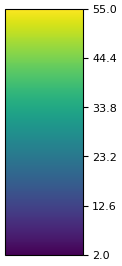
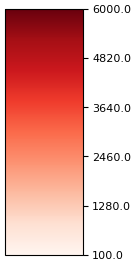
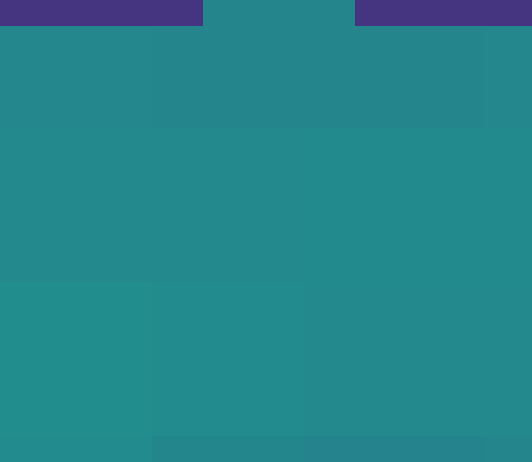
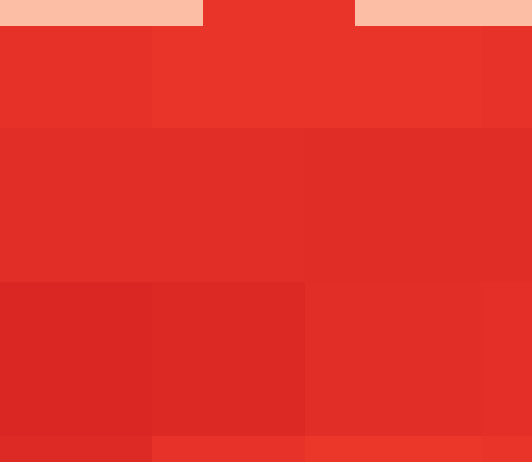
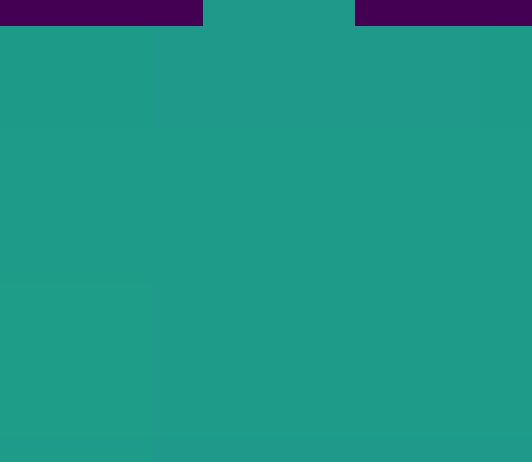
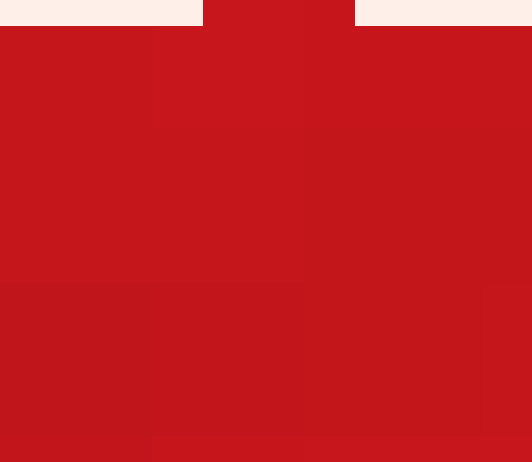
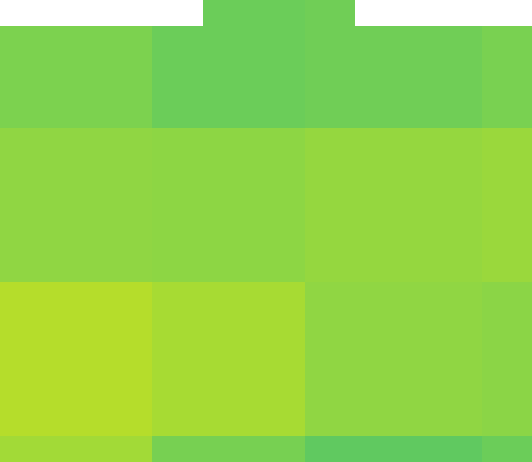
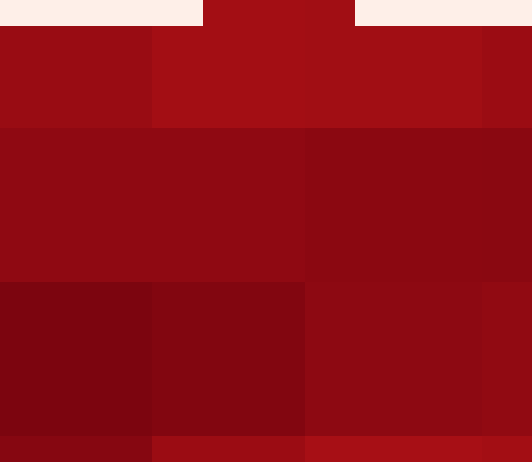

In [19]:
# Create the Folium map with custom settings
# ----------------------------------------------------

def create_folium_map_and_layers(results_dict, germany_gdf, 
                                 map_title="",
                                 overlay_opacity=0.7):
    """
    Creates a folium map, adds all relevant layers for:
      - Section 2 (50-year horizon)
      - Section 3 (100-year horizon)
    using the same naming style as the older code.

    Parameters
    ----------
    results_dict    : dict with keys:
                      - ql_NoUrban_map
                      - ql_Urban_map
                      - EnerUrb_map
                      - ql_UrbanRenew_map
                      - ql_UrbanRenew_max_map
                      - EnerUrbRenew_map
                      - extent
    germany_gdf     : GeoDataFrame for Germany boundary
    map_title       : Title to display at top of the map
    overlay_opacity : Float in [0..1], controlling overlay transparency
    """

    # 1) Basic map creation
    extent = results_dict["extent"]
    
    # Compute center lat/lon from extent
    center_lat = 0.5*(extent[2] + extent[3])
    center_lon = 0.5*(extent[0] + extent[1])
    
    m = folium.Map(location=[center_lat, center_lon], zoom_start=5, 
                   tiles="cartodbpositron")  # or any tile you prefer

    # 2) Add Germany boundary
    add_germany_boundary(m, germany_gdf, name="Germany Boundary")

    # 3) Extract arrays from results
    #ql_NoUrban_map        = results_dict["ql_NoUrban_map"]
    ql_Urban_map          = results_dict["ql_Urban_map"]
    EnerUrb_map           = results_dict["EnerUrb_map"]
    ql_UrbanRenew_map     = results_dict["ql_UrbanRenew_map"]
    ql_UrbanRenew_max_map = results_dict["ql_UrbanRenew_max_map"]
    EnerUrbRenew_map      = results_dict["EnerUrbRenew_map"]
    
    # 4) Define color scales for extraction rate and power
    #    (Adjust as needed for your data)
    ql_vmin,  ql_vmax  = 2, 55      # W/m
    pwr_vmin, pwr_vmax = 100, 6000   # W
    


    # -----------------------------
    # Section 2 (50-year horizon)
    # -----------------------------
    # 4a) No-Urban Delay
    # add_overlay_to_map(
    #     m, ql_NoUrban_map, 
    #     "ql_NoUrban (W/m)",          
    #     cmap_name="viridis", 
    #     extent=extent, 
    #     opacity=overlay_opacity, 
    #     vmin=None, 
    #     vmax=None
    # )

    # 4b) For each "urban delay" scenario: ql_Urban, EnerUrb
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))  # =0→50yrs
    arr_ql_Urban = ql_Urban_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_Urban), np.nanmax(arr_ql_Urban)
    print(f"[50-yr] ql_Urban delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    #for idx, turban in enumerate(turban_sec):
        #years = int(turban / (365*86400))
    add_overlay_to_map(
            m, arr_ql_Urban,
            f"Max Heat Extraction Rate [W/m] (no sustainable, turban = {yrs})",  
            cmap_name="viridis",
            extent=extent,
            opacity=overlay_opacity,
            vmin=ql_vmin,
            vmax=ql_vmax
        )
    # EnerUrb
    arr_EnerUrb = EnerUrb_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrb), np.nanmax(arr_EnerUrb)
    print(f"[50-yr] EnerUrb delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_EnerUrb,
            f"Usable Power [W] (turban = {yrs})",  
            cmap_name="Reds",
            extent=extent,
            opacity=overlay_opacity,
            vmin=pwr_vmin,
            vmax=pwr_vmax
        )

    # --------------------------------
    # Section 3 (100-year horizon)
    # --------------------------------
    # 4c) For each "urban delay" scenario: ql_UrbanRenew, ql_UrbanRenew_max, EnerUrbRenew
    # ----- 100-yr, idx=0 -----
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))
    #for idx, turban in enumerate(turban_sec):
        #years = int(turban / (365*86400))
     # ql_UrbanRenew
    arr_ql_UrbanRenew = ql_UrbanRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_UrbanRenew), np.nanmax(arr_ql_UrbanRenew)
    print(f"[100-yr] ql_UrbanRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_ql_UrbanRenew,
            f"Sustainable Heat Extraction Rate [W/m] (turban = {yrs})",  
            cmap_name="viridis",
            extent=extent,
            opacity=overlay_opacity,
            vmin=ql_vmin,
            vmax=ql_vmax
        )
    # EnerUrbRenew
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))
    arr_EnerUrbRenew = EnerUrbRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrbRenew), np.nanmax(arr_EnerUrbRenew)
    print(f"[100-yr] EnerUrbRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_EnerUrbRenew,
            f"Usable Power [W] under non-renewable rates (turban = {yrs})",  
            cmap_name="Reds",
            extent=extent,
            opacity=overlay_opacity,
            vmin=pwr_vmin,
            vmax=pwr_vmax
        )
        # add_overlay_to_map(
        #     m, EnerUrbRenew_map[:, :, idx],
        #     f"Usable Power under renewable rates [W] (sustainable, 100 years)turban = {years}",  
        #     cmap_name="Reds",
        #     extent=extent,
        #     opacity=overlay_opacity,
        #     vmin=None,
        #     vmax=None
        # )
    # ----- 100-yr max, idx=1 -----
    idx = 1
    yrs = int(turban_sec[idx] / (365*86400))
    # ql_UrbanRenew_max
    arr_ql_UrbanRenew_max = ql_UrbanRenew_max_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_UrbanRenew_max), np.nanmax(arr_ql_UrbanRenew_max)
    print(f"[100-yr] ql_UrbanRenew_max delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
        m, arr_ql_UrbanRenew_max,
        f"Max Sustainable Heat Extraction Rate [W/m] (turban = {yrs})",
        cmap_name="viridis", extent=extent,
        opacity=overlay_opacity, 
        vmin=ql_vmin,
        vmax=ql_vmax
    )
    # EnerUrbRenew again
    idx = 1
    yrs = int(turban_sec[idx] / (365*86400))
    arr_EnerUrbRenew_S = EnerUrbRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrbRenew_S), np.nanmax(arr_EnerUrbRenew_S)
    print(f"[100-yr] EnerUrbRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
        m, arr_EnerUrbRenew_S,
        f"Usable Power under renewable rates [W] (sustainable, turban = {yrs})",
        cmap_name="Reds", extent=extent,
        opacity=overlay_opacity, 
        vmin=pwr_vmin,
        vmax=pwr_vmax
    )

    # 5) Add a layer control so user can toggle layers
    folium.LayerControl().add_to(m)

    # 6) Add colorbar legends for ql (viridis) and power (plasma)
    add_fixed_legend(
        m, "fixed_legend_viridis",
        cmap_name="viridis",
        vmin=ql_vmin, vmax=ql_vmax,
        position='left', top_px=300,
        width=100, height=320,
        legend_title="Heat Extraction Rate (W/m)"
    )
    add_fixed_legend(
        m, "fixed_legend_Reds",
        cmap_name="Reds",
        vmin=pwr_vmin, vmax=pwr_vmax,
        position='right', top_px=300,
        width=100, height=320,
        legend_title="Usable Power (W)"
    )

    # 7) Add a title at the top
    map_title_html = f"""
    <div style="
        position: fixed;
        top: 5px;
        left: 50%;
        transform: translateX(-50%);
        z-index: 9999;
        font-size: 12px;
        font-weight: bold;
        background-color: rgba(255,255,255,0.8);
        padding: 4px;
        border: 1px solid grey;
    ">
      {map_title}
    </div>
    """
    m.get_root().html.add_child(folium.Element(map_title_html))

    return m
# Now we actually create and show the map with a custom title
custom_map_title = "Single BHE Analysis with GEE CMIP6 CanESM Model (ssp245)"
overlay_opacity  = 0.7   # Adjust as you wish

m = create_folium_map_and_layers(
    results_dict=CanESM_ssp245,
    germany_gdf=germany_shape,
    map_title=custom_map_title,
    overlay_opacity=overlay_opacity
)

m


In [20]:
# Load your GeoTIFF file and run the model (Sections 2 & 3)
# -------------------------------------------------------------------

# Provide your local file path here, including directories if needed.
geotiff_path = "CanESM_ssp585_2000_2100_Germany_mean.tif"

# Choose a downsampling factor. Larger factors speed up the computation but lose spatial detail.
ds_factor = 10

# Run the model to get the results dictionary, which includes:
#  - ql_NoUrban_map, ql_Urban_map, EnerUrb_map  (Section 2)
#  - ql_UrbanRenew_map, ql_UrbanRenew_max_map, EnerUrbRenew_map (Section 3)
CanESM_ssp585 = run_model_for_geotiff(
    geotiff_path=geotiff_path, 
    ds_factor=ds_factor
)

print("Model run completed for:", geotiff_path)
print("Results stored in 'CanESM_ssp585'")

Loaded 'CanESM_ssp585_2000_2100_Germany_mean.tif' with shape (176, 203).
Downsampled to shape: (18, 21)
Extent: (5.8839651109828655, 15.001865244796008, 47.2962997088928, 55.20147420914459)


/tmp/ipykernel_109826/3595534842.py:57: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sol_urb = fsolve(lambda ql: fzero_urban(ql, Tm_local), 10.0, xtol=1e-5)[0]


Model run completed for: CanESM_ssp585_2000_2100_Germany_mean.tif
Results stored in 'CanESM_ssp585'


[50-yr] ql_Urban delay=0yr → vmin=10.00, vmax=28.54
[50-yr] EnerUrb delay=0yr → vmin=1500.00, vmax=4280.85
[100-yr] ql_UrbanRenew delay=0yr → vmin=2.00, vmax=31.78
[100-yr] EnerUrbRenew delay=0yr → vmin=300.00, vmax=4766.29
[100-yr] ql_UrbanRenew_max delay=100yr → vmin=44.02, vmax=51.09
[100-yr] EnerUrbRenew delay=100yr → vmin=300.00, vmax=5880.60



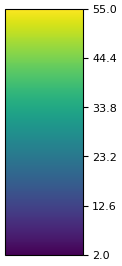
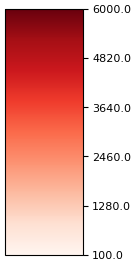
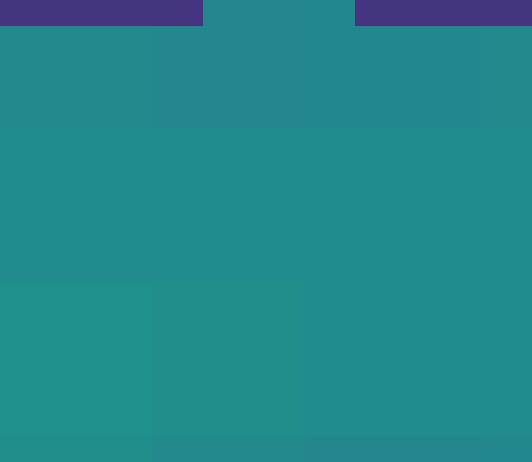
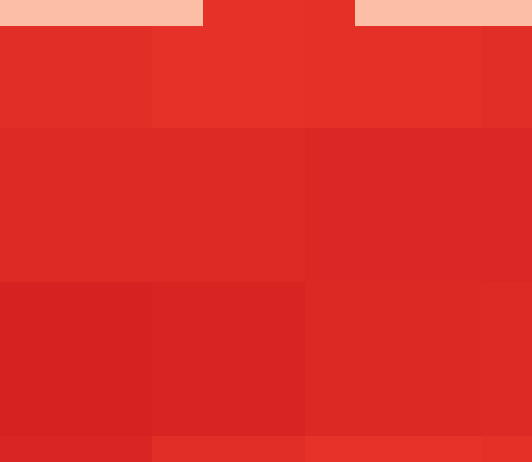
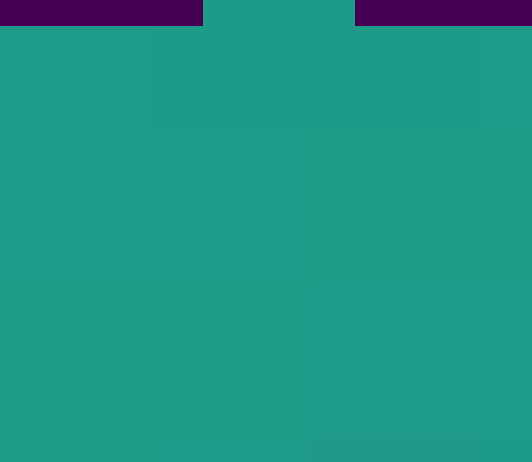
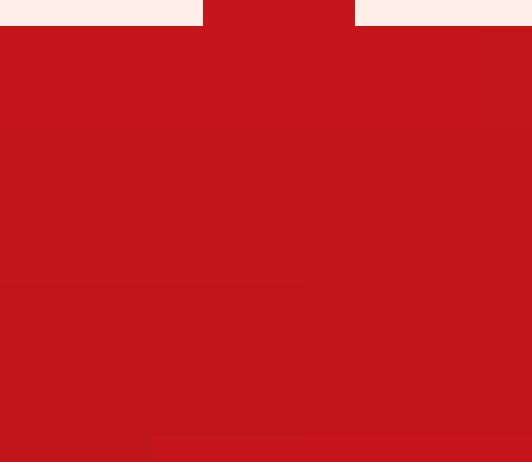
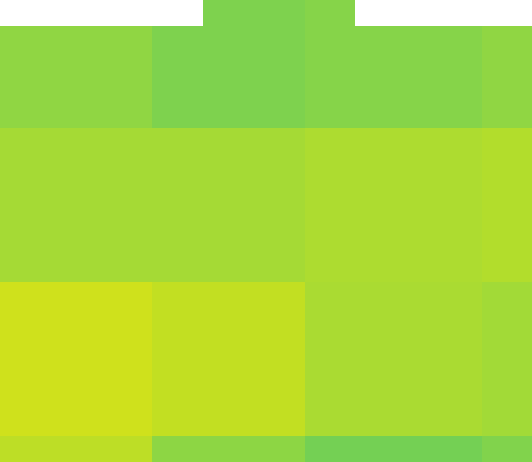
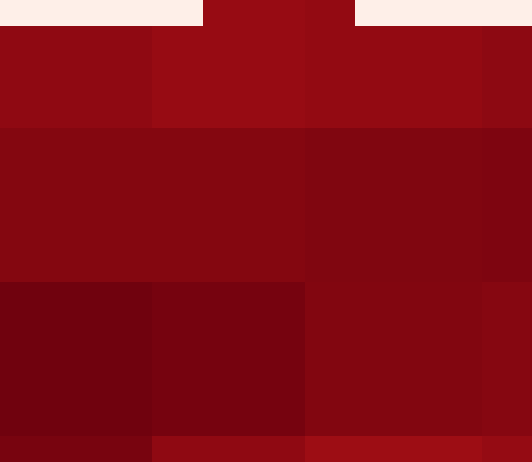

In [21]:
# Create the Folium map with custom settings
# ----------------------------------------------------

def create_folium_map_and_layers(results_dict, germany_gdf, 
                                 map_title="",
                                 overlay_opacity=0.7):
    """
    Creates a folium map, adds all relevant layers for:
      - Section 2 (50-year horizon)
      - Section 3 (100-year horizon)
    using the same naming style as the older code.

    Parameters
    ----------
    results_dict    : dict with keys:
                      - ql_NoUrban_map
                      - ql_Urban_map
                      - EnerUrb_map
                      - ql_UrbanRenew_map
                      - ql_UrbanRenew_max_map
                      - EnerUrbRenew_map
                      - extent
    germany_gdf     : GeoDataFrame for Germany boundary
    map_title       : Title to display at top of the map
    overlay_opacity : Float in [0..1], controlling overlay transparency
    """

    # 1) Basic map creation
    extent = results_dict["extent"]
    
    # Compute center lat/lon from extent
    center_lat = 0.5*(extent[2] + extent[3])
    center_lon = 0.5*(extent[0] + extent[1])
    
    m = folium.Map(location=[center_lat, center_lon], zoom_start=5, 
                   tiles="cartodbpositron")  # or any tile you prefer

    # 2) Add Germany boundary
    add_germany_boundary(m, germany_gdf, name="Germany Boundary")

    # 3) Extract arrays from results
    #ql_NoUrban_map        = results_dict["ql_NoUrban_map"]
    ql_Urban_map          = results_dict["ql_Urban_map"]
    EnerUrb_map           = results_dict["EnerUrb_map"]
    ql_UrbanRenew_map     = results_dict["ql_UrbanRenew_map"]
    ql_UrbanRenew_max_map = results_dict["ql_UrbanRenew_max_map"]
    EnerUrbRenew_map      = results_dict["EnerUrbRenew_map"]
    
    # 4) Define color scales for extraction rate and power
    #    (Adjust as needed for your data)
    ql_vmin,  ql_vmax  = 2, 55      # W/m
    pwr_vmin, pwr_vmax = 100, 6000   # W
    


    # -----------------------------
    # Section 2 (50-year horizon)
    # -----------------------------
    # 4a) No-Urban Delay
    # add_overlay_to_map(
    #     m, ql_NoUrban_map, 
    #     "ql_NoUrban (W/m)",          
    #     cmap_name="viridis", 
    #     extent=extent, 
    #     opacity=overlay_opacity, 
    #     vmin=None, 
    #     vmax=None
    # )

    # 4b) For each "urban delay" scenario: ql_Urban, EnerUrb
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))  # =0→50yrs
    arr_ql_Urban = ql_Urban_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_Urban), np.nanmax(arr_ql_Urban)
    print(f"[50-yr] ql_Urban delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    #for idx, turban in enumerate(turban_sec):
        #years = int(turban / (365*86400))
    add_overlay_to_map(
            m, arr_ql_Urban,
            f"Max Heat Extraction Rate [W/m] (no sustainable, turban = {yrs})",  
            cmap_name="viridis",
            extent=extent,
            opacity=overlay_opacity,
            vmin=ql_vmin,
            vmax=ql_vmax
        )
    # EnerUrb
    arr_EnerUrb = EnerUrb_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrb), np.nanmax(arr_EnerUrb)
    print(f"[50-yr] EnerUrb delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_EnerUrb,
            f"Usable Power [W] (turban = {yrs})",  
            cmap_name="Reds",
            extent=extent,
            opacity=overlay_opacity,
            vmin=pwr_vmin,
            vmax=pwr_vmax
        )

    # --------------------------------
    # Section 3 (100-year horizon)
    # --------------------------------
    # 4c) For each "urban delay" scenario: ql_UrbanRenew, ql_UrbanRenew_max, EnerUrbRenew
    # ----- 100-yr, idx=0 -----
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))
    #for idx, turban in enumerate(turban_sec):
        #years = int(turban / (365*86400))
     # ql_UrbanRenew
    arr_ql_UrbanRenew = ql_UrbanRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_UrbanRenew), np.nanmax(arr_ql_UrbanRenew)
    print(f"[100-yr] ql_UrbanRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_ql_UrbanRenew,
            f"Sustainable Heat Extraction Rate [W/m] (turban = {yrs})",  
            cmap_name="viridis",
            extent=extent,
            opacity=overlay_opacity,
            vmin=ql_vmin,
            vmax=ql_vmax
        )
    # EnerUrbRenew
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))
    arr_EnerUrbRenew = EnerUrbRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrbRenew), np.nanmax(arr_EnerUrbRenew)
    print(f"[100-yr] EnerUrbRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_EnerUrbRenew,
            f"Usable Power [W] under non-renewable rates (turban = {yrs})",  
            cmap_name="Reds",
            extent=extent,
            opacity=overlay_opacity,
            vmin=pwr_vmin,
            vmax=pwr_vmax
        )
        # add_overlay_to_map(
        #     m, EnerUrbRenew_map[:, :, idx],
        #     f"Usable Power under renewable rates [W] (sustainable, 100 years)turban = {years}",  
        #     cmap_name="Reds",
        #     extent=extent,
        #     opacity=overlay_opacity,
        #     vmin=None,
        #     vmax=None
        # )
    # ----- 100-yr max, idx=1 -----
    idx = 1
    yrs = int(turban_sec[idx] / (365*86400))
    # ql_UrbanRenew_max
    arr_ql_UrbanRenew_max = ql_UrbanRenew_max_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_UrbanRenew_max), np.nanmax(arr_ql_UrbanRenew_max)
    print(f"[100-yr] ql_UrbanRenew_max delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
        m, arr_ql_UrbanRenew_max,
        f"Max Sustainable Heat Extraction Rate [W/m] (turban = {yrs})",
        cmap_name="viridis", extent=extent,
        opacity=overlay_opacity, 
        vmin=ql_vmin,
        vmax=ql_vmax
    )
    # EnerUrbRenew again
    idx = 1
    yrs = int(turban_sec[idx] / (365*86400))
    arr_EnerUrbRenew_S = EnerUrbRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrbRenew_S), np.nanmax(arr_EnerUrbRenew_S)
    print(f"[100-yr] EnerUrbRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
        m, arr_EnerUrbRenew_S,
        f"Usable Power under renewable rates [W] (sustainable, turban = {yrs})",
        cmap_name="Reds", extent=extent,
        opacity=overlay_opacity, 
        vmin=pwr_vmin,
        vmax=pwr_vmax
    )

    # 5) Add a layer control so user can toggle layers
    folium.LayerControl().add_to(m)

    # 6) Add colorbar legends for ql (viridis) and power (plasma)
    add_fixed_legend(
        m, "fixed_legend_viridis",
        cmap_name="viridis",
        vmin=ql_vmin, vmax=ql_vmax,
        position='left', top_px=300,
        width=100, height=320,
        legend_title="Heat Extraction Rate (W/m)"
    )
    add_fixed_legend(
        m, "fixed_legend_Reds",
        cmap_name="Reds",
        vmin=pwr_vmin, vmax=pwr_vmax,
        position='right', top_px=300,
        width=100, height=320,
        legend_title="Usable Power (W)"
    )

    # 7) Add a title at the top
    map_title_html = f"""
    <div style="
        position: fixed;
        top: 5px;
        left: 50%;
        transform: translateX(-50%);
        z-index: 9999;
        font-size: 12px;
        font-weight: bold;
        background-color: rgba(255,255,255,0.8);
        padding: 4px;
        border: 1px solid grey;
    ">
      {map_title}
    </div>
    """
    m.get_root().html.add_child(folium.Element(map_title_html))

    return m
# Now we actually create and show the map with a custom title
custom_map_title = "Single BHE Analysis with GEE CMIP6 CanESM Model (ssp585)"
overlay_opacity  = 0.7   # Adjust as you wish

m = create_folium_map_and_layers(
    results_dict=CanESM_ssp585,
    germany_gdf=germany_shape,
    map_title=custom_map_title,
    overlay_opacity=overlay_opacity
)

m


In [22]:
# Load your GeoTIFF file and run the model (Sections 2 & 3)
# -------------------------------------------------------------------

# Provide your local file path here, including directories if needed.
geotiff_path = "GFDL_ssp245_2000_2100_Germany_mean.tif"

# Choose a downsampling factor. Larger factors speed up the computation but lose spatial detail.
ds_factor = 10

# Run the model to get the results dictionary, which includes:
#  - ql_NoUrban_map, ql_Urban_map, EnerUrb_map  (Section 2)
#  - ql_UrbanRenew_map, ql_UrbanRenew_max_map, EnerUrbRenew_map (Section 3)
GFDL_ssp245 = run_model_for_geotiff(
    geotiff_path=geotiff_path, 
    ds_factor=ds_factor
)

print("Model run completed for:", geotiff_path)
print("Results stored in 'GFDL_ssp245'")

Loaded 'GFDL_ssp245_2000_2100_Germany_mean.tif' with shape (176, 203).
Downsampled to shape: (18, 21)
Extent: (5.8839651109828655, 15.001865244796008, 47.2962997088928, 55.20147420914459)


/tmp/ipykernel_109826/3595534842.py:57: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sol_urb = fsolve(lambda ql: fzero_urban(ql, Tm_local), 10.0, xtol=1e-5)[0]


Model run completed for: GFDL_ssp245_2000_2100_Germany_mean.tif
Results stored in 'GFDL_ssp245'


[50-yr] ql_Urban delay=0yr → vmin=10.00, vmax=26.53
[50-yr] EnerUrb delay=0yr → vmin=1500.00, vmax=3980.21
[100-yr] ql_UrbanRenew delay=0yr → vmin=2.00, vmax=30.85
[100-yr] EnerUrbRenew delay=0yr → vmin=300.00, vmax=4627.38
[100-yr] ql_UrbanRenew_max delay=100yr → vmin=39.67, vmax=44.65
[100-yr] EnerUrbRenew delay=100yr → vmin=300.00, vmax=5398.41



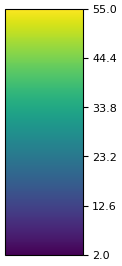
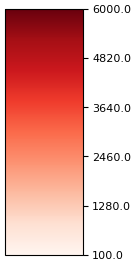
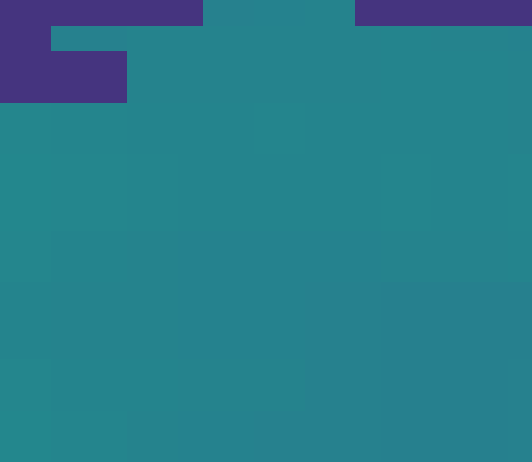
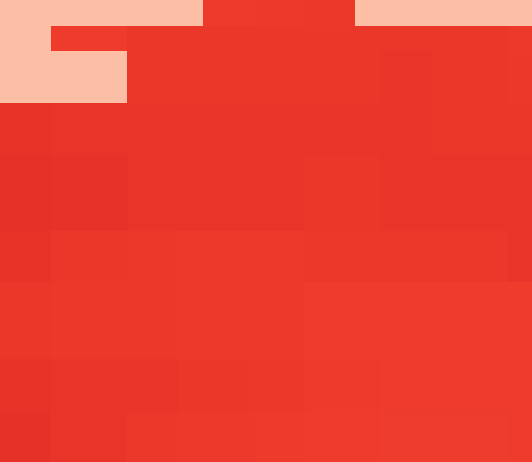
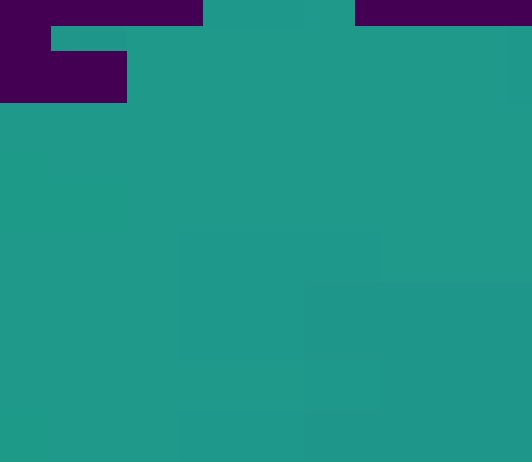
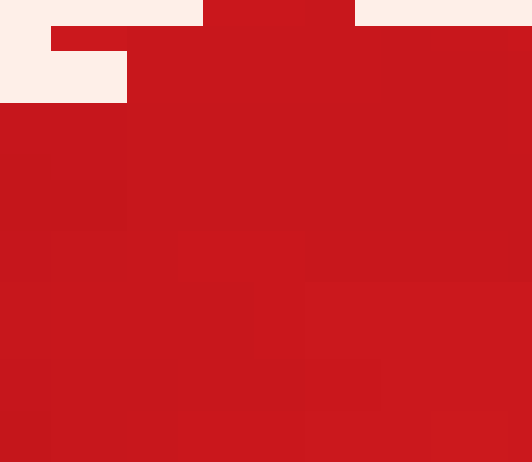
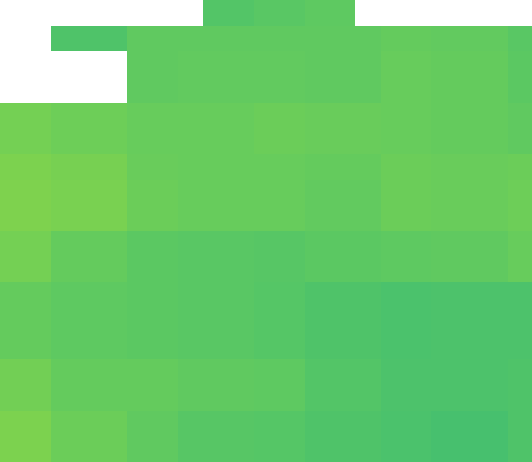
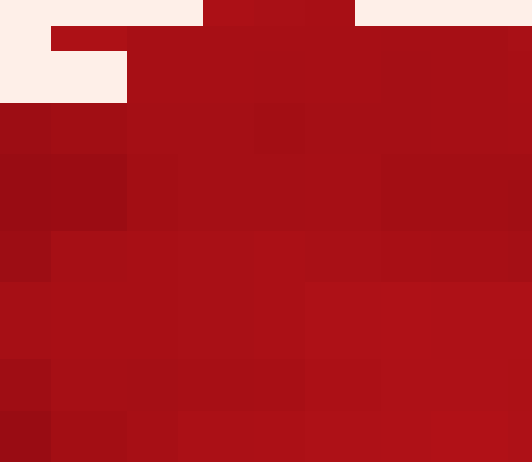

In [23]:
# Create the Folium map with custom settings
# ----------------------------------------------------

def create_folium_map_and_layers(results_dict, germany_gdf, 
                                 map_title="",
                                 overlay_opacity=0.7):
    """
    Creates a folium map, adds all relevant layers for:
      - Section 2 (50-year horizon)
      - Section 3 (100-year horizon)
    using the same naming style as the older code.

    Parameters
    ----------
    results_dict    : dict with keys:
                      - ql_NoUrban_map
                      - ql_Urban_map
                      - EnerUrb_map
                      - ql_UrbanRenew_map
                      - ql_UrbanRenew_max_map
                      - EnerUrbRenew_map
                      - extent
    germany_gdf     : GeoDataFrame for Germany boundary
    map_title       : Title to display at top of the map
    overlay_opacity : Float in [0..1], controlling overlay transparency
    """

    # 1) Basic map creation
    extent = results_dict["extent"]
    
    # Compute center lat/lon from extent
    center_lat = 0.5*(extent[2] + extent[3])
    center_lon = 0.5*(extent[0] + extent[1])
    
    m = folium.Map(location=[center_lat, center_lon], zoom_start=5, 
                   tiles="cartodbpositron")  # or any tile you prefer

    # 2) Add Germany boundary
    add_germany_boundary(m, germany_gdf, name="Germany Boundary")

    # 3) Extract arrays from results
    #ql_NoUrban_map        = results_dict["ql_NoUrban_map"]
    ql_Urban_map          = results_dict["ql_Urban_map"]
    EnerUrb_map           = results_dict["EnerUrb_map"]
    ql_UrbanRenew_map     = results_dict["ql_UrbanRenew_map"]
    ql_UrbanRenew_max_map = results_dict["ql_UrbanRenew_max_map"]
    EnerUrbRenew_map      = results_dict["EnerUrbRenew_map"]
    
    # 4) Define color scales for extraction rate and power
    #    (Adjust as needed for your data)
    ql_vmin,  ql_vmax  = 2, 55      # W/m
    pwr_vmin, pwr_vmax = 100, 6000   # W
    


    # -----------------------------
    # Section 2 (50-year horizon)
    # -----------------------------
    # 4a) No-Urban Delay
    # add_overlay_to_map(
    #     m, ql_NoUrban_map, 
    #     "ql_NoUrban (W/m)",          
    #     cmap_name="viridis", 
    #     extent=extent, 
    #     opacity=overlay_opacity, 
    #     vmin=None, 
    #     vmax=None
    # )

    # 4b) For each "urban delay" scenario: ql_Urban, EnerUrb
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))  # =0→50yrs
    arr_ql_Urban = ql_Urban_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_Urban), np.nanmax(arr_ql_Urban)
    print(f"[50-yr] ql_Urban delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    #for idx, turban in enumerate(turban_sec):
        #years = int(turban / (365*86400))
    add_overlay_to_map(
            m, arr_ql_Urban,
            f"Max Heat Extraction Rate [W/m] (no sustainable, turban = {yrs})",  
            cmap_name="viridis",
            extent=extent,
            opacity=overlay_opacity,
            vmin=ql_vmin,
            vmax=ql_vmax
        )
    # EnerUrb
    arr_EnerUrb = EnerUrb_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrb), np.nanmax(arr_EnerUrb)
    print(f"[50-yr] EnerUrb delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_EnerUrb,
            f"Usable Power [W] (turban = {yrs})",  
            cmap_name="Reds",
            extent=extent,
            opacity=overlay_opacity,
            vmin=pwr_vmin,
            vmax=pwr_vmax
        )

    # --------------------------------
    # Section 3 (100-year horizon)
    # --------------------------------
    # 4c) For each "urban delay" scenario: ql_UrbanRenew, ql_UrbanRenew_max, EnerUrbRenew
    # ----- 100-yr, idx=0 -----
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))
    #for idx, turban in enumerate(turban_sec):
        #years = int(turban / (365*86400))
     # ql_UrbanRenew
    arr_ql_UrbanRenew = ql_UrbanRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_UrbanRenew), np.nanmax(arr_ql_UrbanRenew)
    print(f"[100-yr] ql_UrbanRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_ql_UrbanRenew,
            f"Sustainable Heat Extraction Rate [W/m] (turban = {yrs})",  
            cmap_name="viridis",
            extent=extent,
            opacity=overlay_opacity,
            vmin=ql_vmin,
            vmax=ql_vmax
        )
    # EnerUrbRenew
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))
    arr_EnerUrbRenew = EnerUrbRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrbRenew), np.nanmax(arr_EnerUrbRenew)
    print(f"[100-yr] EnerUrbRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_EnerUrbRenew,
            f"Usable Power [W] under non-renewable rates (turban = {yrs})",  
            cmap_name="Reds",
            extent=extent,
            opacity=overlay_opacity,
            vmin=pwr_vmin,
            vmax=pwr_vmax
        )
        # add_overlay_to_map(
        #     m, EnerUrbRenew_map[:, :, idx],
        #     f"Usable Power under renewable rates [W] (sustainable, 100 years)turban = {years}",  
        #     cmap_name="Reds",
        #     extent=extent,
        #     opacity=overlay_opacity,
        #     vmin=None,
        #     vmax=None
        # )
    # ----- 100-yr max, idx=1 -----
    idx = 1
    yrs = int(turban_sec[idx] / (365*86400))
    # ql_UrbanRenew_max
    arr_ql_UrbanRenew_max = ql_UrbanRenew_max_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_UrbanRenew_max), np.nanmax(arr_ql_UrbanRenew_max)
    print(f"[100-yr] ql_UrbanRenew_max delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
        m, arr_ql_UrbanRenew_max,
        f"Max Sustainable Heat Extraction Rate [W/m] (turban = {yrs})",
        cmap_name="viridis", extent=extent,
        opacity=overlay_opacity, 
        vmin=ql_vmin,
        vmax=ql_vmax
    )
    # EnerUrbRenew again
    idx = 1
    yrs = int(turban_sec[idx] / (365*86400))
    arr_EnerUrbRenew_S = EnerUrbRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrbRenew_S), np.nanmax(arr_EnerUrbRenew_S)
    print(f"[100-yr] EnerUrbRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
        m, arr_EnerUrbRenew_S,
        f"Usable Power under renewable rates [W] (sustainable, turban = {yrs})",
        cmap_name="Reds", extent=extent,
        opacity=overlay_opacity, 
        vmin=pwr_vmin,
        vmax=pwr_vmax
    )

    # 5) Add a layer control so user can toggle layers
    folium.LayerControl().add_to(m)

    # 6) Add colorbar legends for ql (viridis) and power (plasma)
    add_fixed_legend(
        m, "fixed_legend_viridis",
        cmap_name="viridis",
        vmin=ql_vmin, vmax=ql_vmax,
        position='left', top_px=300,
        width=100, height=320,
        legend_title="Heat Extraction Rate (W/m)"
    )
    add_fixed_legend(
        m, "fixed_legend_Reds",
        cmap_name="Reds",
        vmin=pwr_vmin, vmax=pwr_vmax,
        position='right', top_px=300,
        width=100, height=320,
        legend_title="Usable Power (W)"
    )

    # 7) Add a title at the top
    map_title_html = f"""
    <div style="
        position: fixed;
        top: 5px;
        left: 50%;
        transform: translateX(-50%);
        z-index: 9999;
        font-size: 12px;
        font-weight: bold;
        background-color: rgba(255,255,255,0.8);
        padding: 4px;
        border: 1px solid grey;
    ">
      {map_title}
    </div>
    """
    m.get_root().html.add_child(folium.Element(map_title_html))

    return m
# Now we actually create and show the map with a custom title
custom_map_title = "Single BHE Analysis with GEE CMIP6 GFDL Model (ssp245)"
overlay_opacity  = 0.7   # Adjust as you wish

m = create_folium_map_and_layers(
    results_dict=GFDL_ssp245,
    germany_gdf=germany_shape,
    map_title=custom_map_title,
    overlay_opacity=overlay_opacity
)

m


In [24]:
# Load your GeoTIFF file and run the model (Sections 2 & 3)
# -------------------------------------------------------------------

# Provide your local file path here, including directories if needed.
geotiff_path = "GFDL_ssp585_2000_2100_Germany_mean.tif"

# Choose a downsampling factor. Larger factors speed up the computation but lose spatial detail.
ds_factor = 10

# Run the model to get the results dictionary, which includes:
#  - ql_NoUrban_map, ql_Urban_map, EnerUrb_map  (Section 2)
#  - ql_UrbanRenew_map, ql_UrbanRenew_max_map, EnerUrbRenew_map (Section 3)
GFDL_ssp585 = run_model_for_geotiff(
    geotiff_path=geotiff_path, 
    ds_factor=ds_factor
)

print("Model run completed for:", geotiff_path)
print("Results stored in 'GFDL_ssp585'")

Loaded 'GFDL_ssp585_2000_2100_Germany_mean.tif' with shape (176, 203).
Downsampled to shape: (18, 21)
Extent: (5.8839651109828655, 15.001865244796008, 47.2962997088928, 55.20147420914459)


/tmp/ipykernel_109826/3595534842.py:57: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sol_urb = fsolve(lambda ql: fzero_urban(ql, Tm_local), 10.0, xtol=1e-5)[0]


Model run completed for: GFDL_ssp585_2000_2100_Germany_mean.tif
Results stored in 'GFDL_ssp585'


[50-yr] ql_Urban delay=0yr → vmin=10.00, vmax=26.73
[50-yr] EnerUrb delay=0yr → vmin=1500.00, vmax=4008.85
[100-yr] ql_UrbanRenew delay=0yr → vmin=2.00, vmax=30.95
[100-yr] EnerUrbRenew delay=0yr → vmin=300.00, vmax=4641.77
[100-yr] ql_UrbanRenew_max delay=100yr → vmin=40.45, vmax=45.27
[100-yr] EnerUrbRenew delay=100yr → vmin=300.00, vmax=5444.68



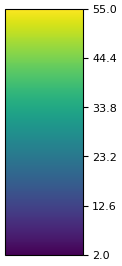
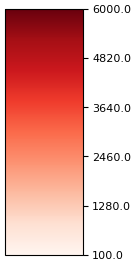
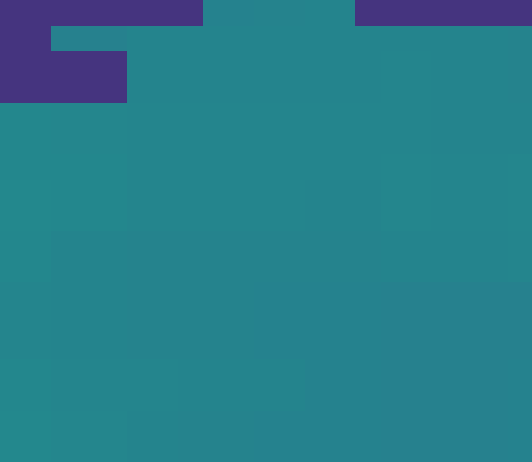
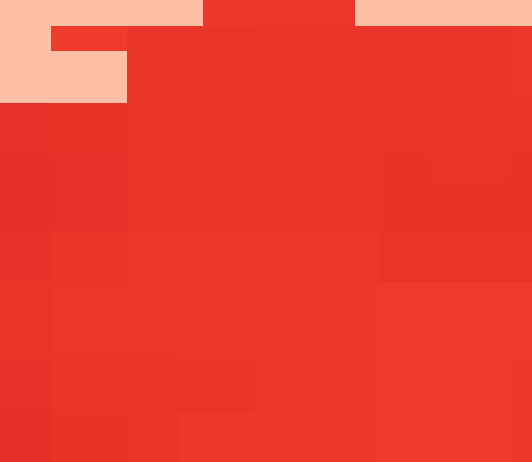
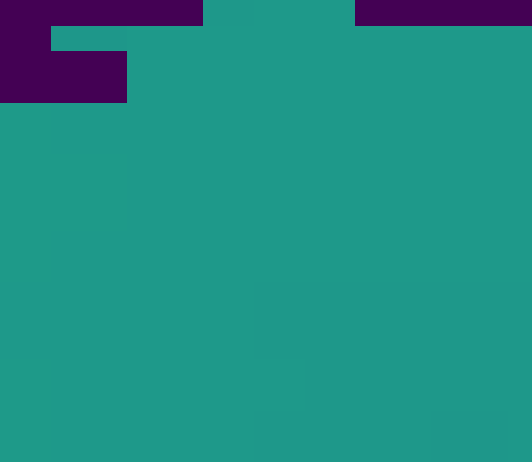
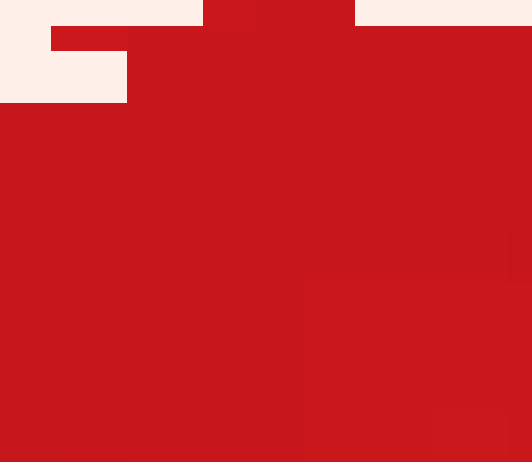
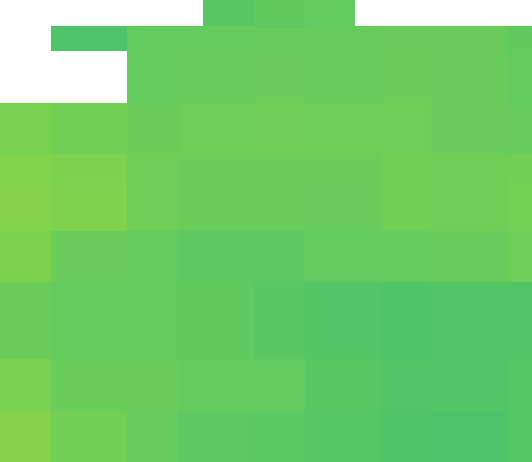
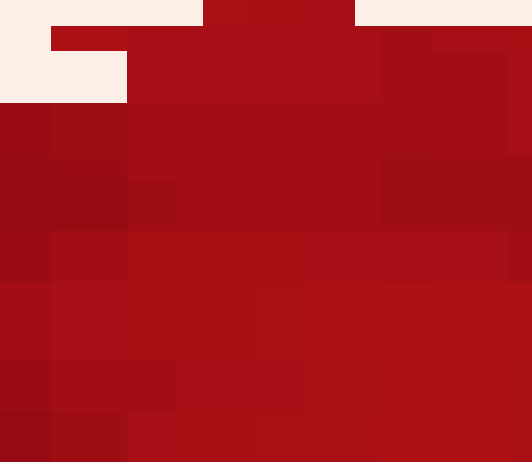

In [25]:
# Create the Folium map with custom settings
# ----------------------------------------------------

def create_folium_map_and_layers(results_dict, germany_gdf, 
                                 map_title="",
                                 overlay_opacity=0.7):
    """
    Creates a folium map, adds all relevant layers for:
      - Section 2 (50-year horizon)
      - Section 3 (100-year horizon)
    using the same naming style as the older code.

    Parameters
    ----------
    results_dict    : dict with keys:
                      - ql_NoUrban_map
                      - ql_Urban_map
                      - EnerUrb_map
                      - ql_UrbanRenew_map
                      - ql_UrbanRenew_max_map
                      - EnerUrbRenew_map
                      - extent
    germany_gdf     : GeoDataFrame for Germany boundary
    map_title       : Title to display at top of the map
    overlay_opacity : Float in [0..1], controlling overlay transparency
    """

    # 1) Basic map creation
    extent = results_dict["extent"]
    
    # Compute center lat/lon from extent
    center_lat = 0.5*(extent[2] + extent[3])
    center_lon = 0.5*(extent[0] + extent[1])
    
    m = folium.Map(location=[center_lat, center_lon], zoom_start=5, 
                   tiles="cartodbpositron")  # or any tile you prefer

    # 2) Add Germany boundary
    add_germany_boundary(m, germany_gdf, name="Germany Boundary")

    # 3) Extract arrays from results
    #ql_NoUrban_map        = results_dict["ql_NoUrban_map"]
    ql_Urban_map          = results_dict["ql_Urban_map"]
    EnerUrb_map           = results_dict["EnerUrb_map"]
    ql_UrbanRenew_map     = results_dict["ql_UrbanRenew_map"]
    ql_UrbanRenew_max_map = results_dict["ql_UrbanRenew_max_map"]
    EnerUrbRenew_map      = results_dict["EnerUrbRenew_map"]
    
    # 4) Define color scales for extraction rate and power
    #    (Adjust as needed for your data)
    ql_vmin,  ql_vmax  = 2, 55      # W/m
    pwr_vmin, pwr_vmax = 100, 6000   # W
    


    # -----------------------------
    # Section 2 (50-year horizon)
    # -----------------------------
    # 4a) No-Urban Delay
    # add_overlay_to_map(
    #     m, ql_NoUrban_map, 
    #     "ql_NoUrban (W/m)",          
    #     cmap_name="viridis", 
    #     extent=extent, 
    #     opacity=overlay_opacity, 
    #     vmin=None, 
    #     vmax=None
    # )

    # 4b) For each "urban delay" scenario: ql_Urban, EnerUrb
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))  # =0→50yrs
    arr_ql_Urban = ql_Urban_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_Urban), np.nanmax(arr_ql_Urban)
    print(f"[50-yr] ql_Urban delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    #for idx, turban in enumerate(turban_sec):
        #years = int(turban / (365*86400))
    add_overlay_to_map(
            m, arr_ql_Urban,
            f"Max Heat Extraction Rate [W/m] (no sustainable, turban = {yrs})",  
            cmap_name="viridis",
            extent=extent,
            opacity=overlay_opacity,
            vmin=ql_vmin,
            vmax=ql_vmax
        )
    # EnerUrb
    arr_EnerUrb = EnerUrb_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrb), np.nanmax(arr_EnerUrb)
    print(f"[50-yr] EnerUrb delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_EnerUrb,
            f"Usable Power [W] (turban = {yrs})",  
            cmap_name="Reds",
            extent=extent,
            opacity=overlay_opacity,
            vmin=pwr_vmin,
            vmax=pwr_vmax
        )

    # --------------------------------
    # Section 3 (100-year horizon)
    # --------------------------------
    # 4c) For each "urban delay" scenario: ql_UrbanRenew, ql_UrbanRenew_max, EnerUrbRenew
    # ----- 100-yr, idx=0 -----
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))
    #for idx, turban in enumerate(turban_sec):
        #years = int(turban / (365*86400))
     # ql_UrbanRenew
    arr_ql_UrbanRenew = ql_UrbanRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_UrbanRenew), np.nanmax(arr_ql_UrbanRenew)
    print(f"[100-yr] ql_UrbanRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_ql_UrbanRenew,
            f"Sustainable Heat Extraction Rate [W/m] (turban = {yrs})",  
            cmap_name="viridis",
            extent=extent,
            opacity=overlay_opacity,
            vmin=ql_vmin,
            vmax=ql_vmax
        )
    # EnerUrbRenew
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))
    arr_EnerUrbRenew = EnerUrbRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrbRenew), np.nanmax(arr_EnerUrbRenew)
    print(f"[100-yr] EnerUrbRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_EnerUrbRenew,
            f"Usable Power [W] under non-renewable rates (turban = {yrs})",  
            cmap_name="Reds",
            extent=extent,
            opacity=overlay_opacity,
            vmin=pwr_vmin,
            vmax=pwr_vmax
        )
        # add_overlay_to_map(
        #     m, EnerUrbRenew_map[:, :, idx],
        #     f"Usable Power under renewable rates [W] (sustainable, 100 years)turban = {years}",  
        #     cmap_name="Reds",
        #     extent=extent,
        #     opacity=overlay_opacity,
        #     vmin=None,
        #     vmax=None
        # )
    # ----- 100-yr max, idx=1 -----
    idx = 1
    yrs = int(turban_sec[idx] / (365*86400))
    # ql_UrbanRenew_max
    arr_ql_UrbanRenew_max = ql_UrbanRenew_max_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_UrbanRenew_max), np.nanmax(arr_ql_UrbanRenew_max)
    print(f"[100-yr] ql_UrbanRenew_max delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
        m, arr_ql_UrbanRenew_max,
        f"Max Sustainable Heat Extraction Rate [W/m] (turban = {yrs})",
        cmap_name="viridis", extent=extent,
        opacity=overlay_opacity, 
        vmin=ql_vmin,
        vmax=ql_vmax
    )
    # EnerUrbRenew again
    idx = 1
    yrs = int(turban_sec[idx] / (365*86400))
    arr_EnerUrbRenew_S = EnerUrbRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrbRenew_S), np.nanmax(arr_EnerUrbRenew_S)
    print(f"[100-yr] EnerUrbRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
        m, arr_EnerUrbRenew_S,
        f"Usable Power under renewable rates [W] (sustainable, turban = {yrs})",
        cmap_name="Reds", extent=extent,
        opacity=overlay_opacity, 
        vmin=pwr_vmin,
        vmax=pwr_vmax
    )

    # 5) Add a layer control so user can toggle layers
    folium.LayerControl().add_to(m)

    # 6) Add colorbar legends for ql (viridis) and power (plasma)
    add_fixed_legend(
        m, "fixed_legend_viridis",
        cmap_name="viridis",
        vmin=ql_vmin, vmax=ql_vmax,
        position='left', top_px=300,
        width=100, height=320,
        legend_title="Heat Extraction Rate (W/m)"
    )
    add_fixed_legend(
        m, "fixed_legend_Reds",
        cmap_name="Reds",
        vmin=pwr_vmin, vmax=pwr_vmax,
        position='right', top_px=300,
        width=100, height=320,
        legend_title="Usable Power (W)"
    )

    # 7) Add a title at the top
    map_title_html = f"""
    <div style="
        position: fixed;
        top: 5px;
        left: 50%;
        transform: translateX(-50%);
        z-index: 9999;
        font-size: 12px;
        font-weight: bold;
        background-color: rgba(255,255,255,0.8);
        padding: 4px;
        border: 1px solid grey;
    ">
      {map_title}
    </div>
    """
    m.get_root().html.add_child(folium.Element(map_title_html))

    return m
# Now we actually create and show the map with a custom title
custom_map_title = "Single BHE Analysis with GEE CMIP6 GFDL Model (ssp585)"
overlay_opacity  = 0.7   # Adjust as you wish

m = create_folium_map_and_layers(
    results_dict=GFDL_ssp585,
    germany_gdf=germany_shape,
    map_title=custom_map_title,
    overlay_opacity=overlay_opacity
)

m


In [26]:
# Load your GeoTIFF file and run the model (Sections 2 & 3)
# -------------------------------------------------------------------

# Provide your local file path here, including directories if needed.
geotiff_path = "GISS_ssp245_2000_2100_Germany_mean.tif"

# Choose a downsampling factor. Larger factors speed up the computation but lose spatial detail.
ds_factor = 10

# Run the model to get the results dictionary, which includes:
#  - ql_NoUrban_map, ql_Urban_map, EnerUrb_map  (Section 2)
#  - ql_UrbanRenew_map, ql_UrbanRenew_max_map, EnerUrbRenew_map (Section 3)
GISS_ssp245 = run_model_for_geotiff(
    geotiff_path=geotiff_path, 
    ds_factor=ds_factor
)

print("Model run completed for:", geotiff_path)
print("Results stored in 'GISS_ssp245'")

Loaded 'GISS_ssp245_2000_2100_Germany_mean.tif' with shape (176, 203).
Downsampled to shape: (18, 21)
Extent: (5.8839651109828655, 15.001865244796008, 47.2962997088928, 55.20147420914459)


/tmp/ipykernel_109826/3595534842.py:57: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sol_urb = fsolve(lambda ql: fzero_urban(ql, Tm_local), 10.0, xtol=1e-5)[0]


Model run completed for: GISS_ssp245_2000_2100_Germany_mean.tif
Results stored in 'GISS_ssp245'


[50-yr] ql_Urban delay=0yr → vmin=10.00, vmax=25.14
[50-yr] EnerUrb delay=0yr → vmin=1500.00, vmax=3771.17
[100-yr] ql_UrbanRenew delay=0yr → vmin=2.00, vmax=30.08
[100-yr] EnerUrbRenew delay=0yr → vmin=300.00, vmax=4512.64
[100-yr] ql_UrbanRenew_max delay=100yr → vmin=35.60, vmax=40.18
[100-yr] EnerUrbRenew delay=100yr → vmin=300.00, vmax=5057.57



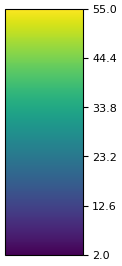
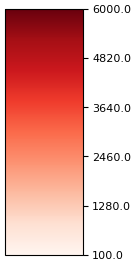
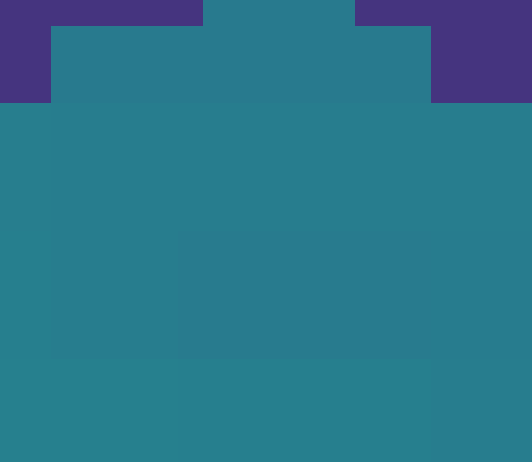
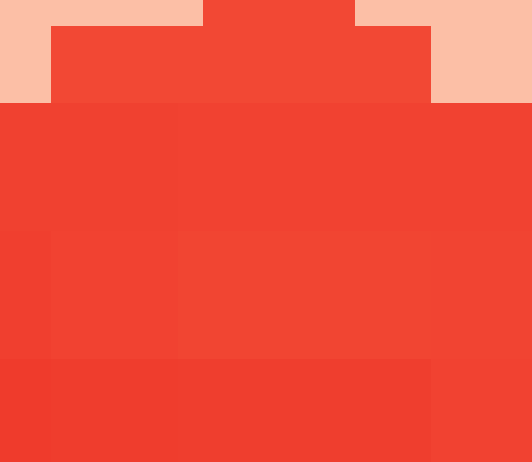
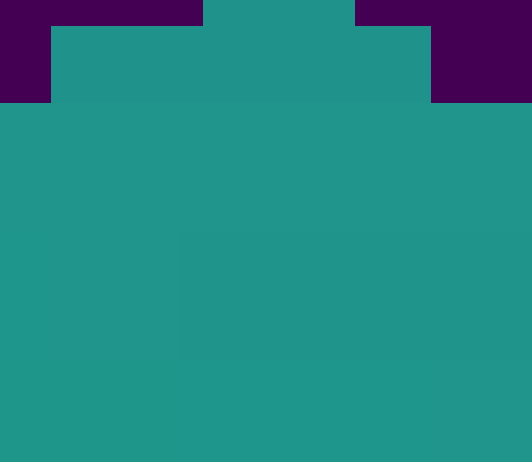
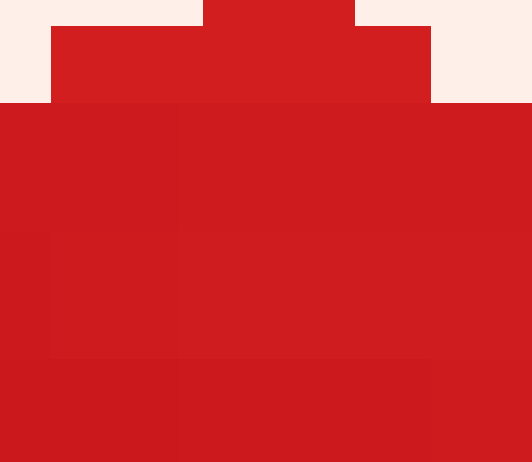
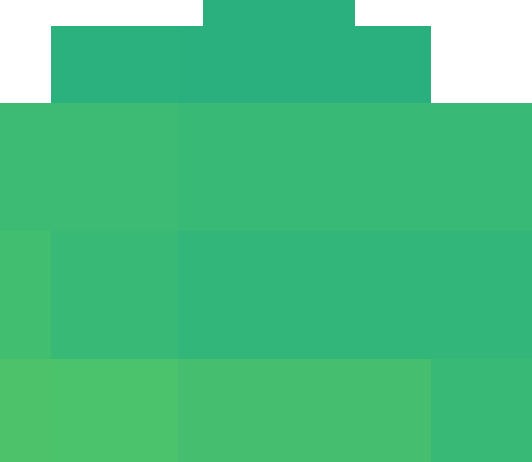
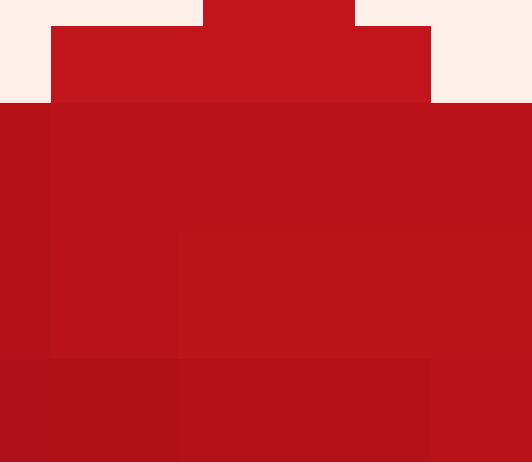

In [27]:
# Create the Folium map with custom settings
# ----------------------------------------------------

def create_folium_map_and_layers(results_dict, germany_gdf, 
                                 map_title="",
                                 overlay_opacity=0.7):
    """
    Creates a folium map, adds all relevant layers for:
      - Section 2 (50-year horizon)
      - Section 3 (100-year horizon)
    using the same naming style as the older code.

    Parameters
    ----------
    results_dict    : dict with keys:
                      - ql_NoUrban_map
                      - ql_Urban_map
                      - EnerUrb_map
                      - ql_UrbanRenew_map
                      - ql_UrbanRenew_max_map
                      - EnerUrbRenew_map
                      - extent
    germany_gdf     : GeoDataFrame for Germany boundary
    map_title       : Title to display at top of the map
    overlay_opacity : Float in [0..1], controlling overlay transparency
    """

    # 1) Basic map creation
    extent = results_dict["extent"]
    
    # Compute center lat/lon from extent
    center_lat = 0.5*(extent[2] + extent[3])
    center_lon = 0.5*(extent[0] + extent[1])
    
    m = folium.Map(location=[center_lat, center_lon], zoom_start=5, 
                   tiles="cartodbpositron")  # or any tile you prefer

    # 2) Add Germany boundary
    add_germany_boundary(m, germany_gdf, name="Germany Boundary")

    # 3) Extract arrays from results
    #ql_NoUrban_map        = results_dict["ql_NoUrban_map"]
    ql_Urban_map          = results_dict["ql_Urban_map"]
    EnerUrb_map           = results_dict["EnerUrb_map"]
    ql_UrbanRenew_map     = results_dict["ql_UrbanRenew_map"]
    ql_UrbanRenew_max_map = results_dict["ql_UrbanRenew_max_map"]
    EnerUrbRenew_map      = results_dict["EnerUrbRenew_map"]
    
    # 4) Define color scales for extraction rate and power
    #    (Adjust as needed for your data)
    ql_vmin,  ql_vmax  = 2, 55      # W/m
    pwr_vmin, pwr_vmax = 100, 6000   # W
    


    # -----------------------------
    # Section 2 (50-year horizon)
    # -----------------------------
    # 4a) No-Urban Delay
    # add_overlay_to_map(
    #     m, ql_NoUrban_map, 
    #     "ql_NoUrban (W/m)",          
    #     cmap_name="viridis", 
    #     extent=extent, 
    #     opacity=overlay_opacity, 
    #     vmin=None, 
    #     vmax=None
    # )

    # 4b) For each "urban delay" scenario: ql_Urban, EnerUrb
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))  # =0→50yrs
    arr_ql_Urban = ql_Urban_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_Urban), np.nanmax(arr_ql_Urban)
    print(f"[50-yr] ql_Urban delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    #for idx, turban in enumerate(turban_sec):
        #years = int(turban / (365*86400))
    add_overlay_to_map(
            m, arr_ql_Urban,
            f"Max Heat Extraction Rate [W/m] (no sustainable, turban = {yrs})",  
            cmap_name="viridis",
            extent=extent,
            opacity=overlay_opacity,
            vmin=ql_vmin,
            vmax=ql_vmax
        )
    # EnerUrb
    arr_EnerUrb = EnerUrb_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrb), np.nanmax(arr_EnerUrb)
    print(f"[50-yr] EnerUrb delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_EnerUrb,
            f"Usable Power [W] (turban = {yrs})",  
            cmap_name="Reds",
            extent=extent,
            opacity=overlay_opacity,
            vmin=pwr_vmin,
            vmax=pwr_vmax
        )

    # --------------------------------
    # Section 3 (100-year horizon)
    # --------------------------------
    # 4c) For each "urban delay" scenario: ql_UrbanRenew, ql_UrbanRenew_max, EnerUrbRenew
    # ----- 100-yr, idx=0 -----
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))
    #for idx, turban in enumerate(turban_sec):
        #years = int(turban / (365*86400))
     # ql_UrbanRenew
    arr_ql_UrbanRenew = ql_UrbanRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_UrbanRenew), np.nanmax(arr_ql_UrbanRenew)
    print(f"[100-yr] ql_UrbanRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_ql_UrbanRenew,
            f"Sustainable Heat Extraction Rate [W/m] (turban = {yrs})",  
            cmap_name="viridis",
            extent=extent,
            opacity=overlay_opacity,
            vmin=ql_vmin,
            vmax=ql_vmax
        )
    # EnerUrbRenew
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))
    arr_EnerUrbRenew = EnerUrbRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrbRenew), np.nanmax(arr_EnerUrbRenew)
    print(f"[100-yr] EnerUrbRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_EnerUrbRenew,
            f"Usable Power [W] under non-renewable rates (turban = {yrs})",  
            cmap_name="Reds",
            extent=extent,
            opacity=overlay_opacity,
            vmin=pwr_vmin,
            vmax=pwr_vmax
        )
        # add_overlay_to_map(
        #     m, EnerUrbRenew_map[:, :, idx],
        #     f"Usable Power under renewable rates [W] (sustainable, 100 years)turban = {years}",  
        #     cmap_name="Reds",
        #     extent=extent,
        #     opacity=overlay_opacity,
        #     vmin=None,
        #     vmax=None
        # )
    # ----- 100-yr max, idx=1 -----
    idx = 1
    yrs = int(turban_sec[idx] / (365*86400))
    # ql_UrbanRenew_max
    arr_ql_UrbanRenew_max = ql_UrbanRenew_max_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_UrbanRenew_max), np.nanmax(arr_ql_UrbanRenew_max)
    print(f"[100-yr] ql_UrbanRenew_max delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
        m, arr_ql_UrbanRenew_max,
        f"Max Sustainable Heat Extraction Rate [W/m] (turban = {yrs})",
        cmap_name="viridis", extent=extent,
        opacity=overlay_opacity, 
        vmin=ql_vmin,
        vmax=ql_vmax
    )
    # EnerUrbRenew again
    idx = 1
    yrs = int(turban_sec[idx] / (365*86400))
    arr_EnerUrbRenew_S = EnerUrbRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrbRenew_S), np.nanmax(arr_EnerUrbRenew_S)
    print(f"[100-yr] EnerUrbRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
        m, arr_EnerUrbRenew_S,
        f"Usable Power under renewable rates [W] (sustainable, turban = {yrs})",
        cmap_name="Reds", extent=extent,
        opacity=overlay_opacity, 
        vmin=pwr_vmin,
        vmax=pwr_vmax
    )

    # 5) Add a layer control so user can toggle layers
    folium.LayerControl().add_to(m)

    # 6) Add colorbar legends for ql (viridis) and power (plasma)
    add_fixed_legend(
        m, "fixed_legend_viridis",
        cmap_name="viridis",
        vmin=ql_vmin, vmax=ql_vmax,
        position='left', top_px=300,
        width=100, height=320,
        legend_title="Heat Extraction Rate (W/m)"
    )
    add_fixed_legend(
        m, "fixed_legend_Reds",
        cmap_name="Reds",
        vmin=pwr_vmin, vmax=pwr_vmax,
        position='right', top_px=300,
        width=100, height=320,
        legend_title="Usable Power (W)"
    )

    # 7) Add a title at the top
    map_title_html = f"""
    <div style="
        position: fixed;
        top: 5px;
        left: 50%;
        transform: translateX(-50%);
        z-index: 9999;
        font-size: 12px;
        font-weight: bold;
        background-color: rgba(255,255,255,0.8);
        padding: 4px;
        border: 1px solid grey;
    ">
      {map_title}
    </div>
    """
    m.get_root().html.add_child(folium.Element(map_title_html))

    return m
# Now we actually create and show the map with a custom title
custom_map_title = "Single BHE Analysis with GEE CMIP6 GISS Model (ssp245)"
overlay_opacity  = 0.7   # Adjust as you wish

m = create_folium_map_and_layers(
    results_dict=GISS_ssp245,
    germany_gdf=germany_shape,
    map_title=custom_map_title,
    overlay_opacity=overlay_opacity
)

m


In [28]:
# Load your GeoTIFF file and run the model (Sections 2 & 3)
# -------------------------------------------------------------------

# Provide your local file path here, including directories if needed.
geotiff_path = "GISS_ssp585_2000_2100_Germany_mean.tif"

# Choose a downsampling factor. Larger factors speed up the computation but lose spatial detail.
ds_factor = 10

# Run the model to get the results dictionary, which includes:
#  - ql_NoUrban_map, ql_Urban_map, EnerUrb_map  (Section 2)
#  - ql_UrbanRenew_map, ql_UrbanRenew_max_map, EnerUrbRenew_map (Section 3)
GISS_ssp585 = run_model_for_geotiff(
    geotiff_path=geotiff_path, 
    ds_factor=ds_factor
)

print("Model run completed for:", geotiff_path)
print("Results stored in 'GISS_ssp585'")

Loaded 'GISS_ssp585_2000_2100_Germany_mean.tif' with shape (176, 203).
Downsampled to shape: (18, 21)
Extent: (5.8839651109828655, 15.001865244796008, 47.2962997088928, 55.20147420914459)


/tmp/ipykernel_109826/3595534842.py:57: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sol_urb = fsolve(lambda ql: fzero_urban(ql, Tm_local), 10.0, xtol=1e-5)[0]


Model run completed for: GISS_ssp585_2000_2100_Germany_mean.tif
Results stored in 'GISS_ssp585'


[50-yr] ql_Urban delay=0yr → vmin=10.00, vmax=25.45
[50-yr] EnerUrb delay=0yr → vmin=1500.00, vmax=3817.92
[100-yr] ql_UrbanRenew delay=0yr → vmin=2.00, vmax=30.27
[100-yr] EnerUrbRenew delay=0yr → vmin=300.00, vmax=4539.95
[100-yr] ql_UrbanRenew_max delay=100yr → vmin=36.54, vmax=41.18
[100-yr] EnerUrbRenew delay=100yr → vmin=300.00, vmax=5134.34



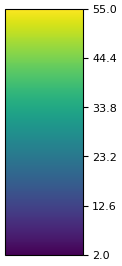
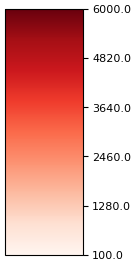
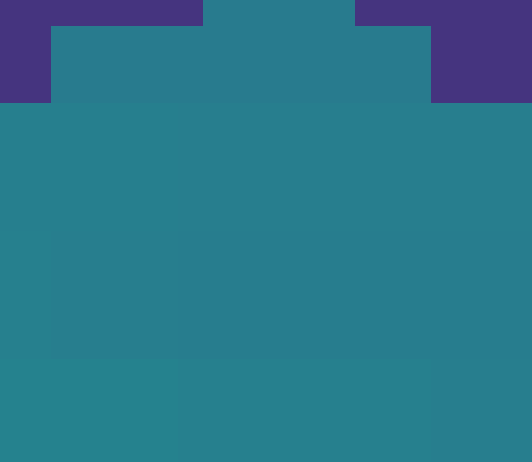
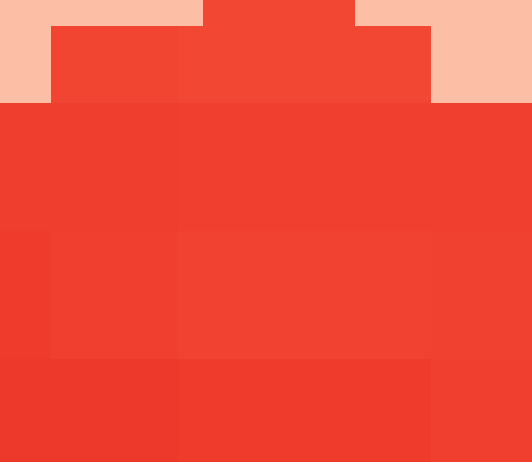
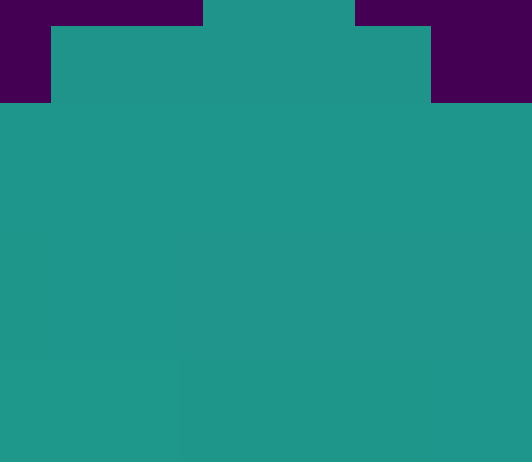
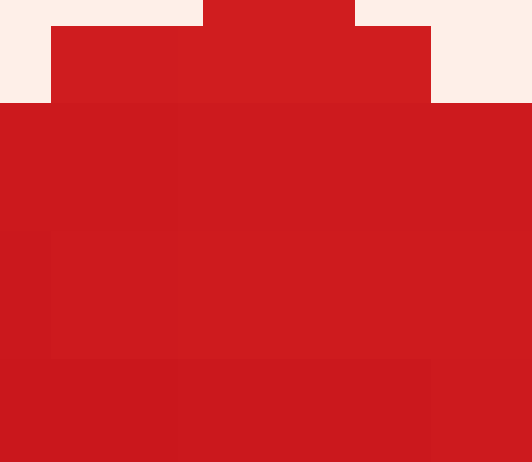
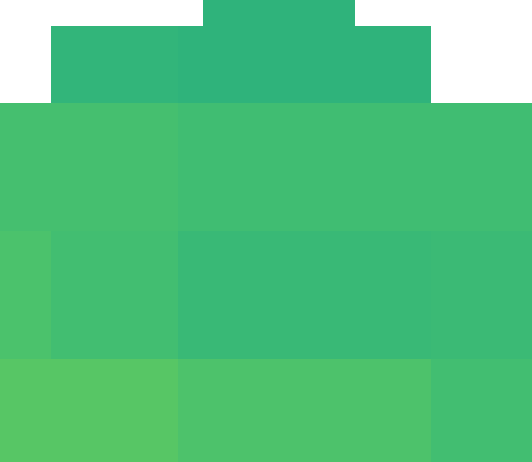
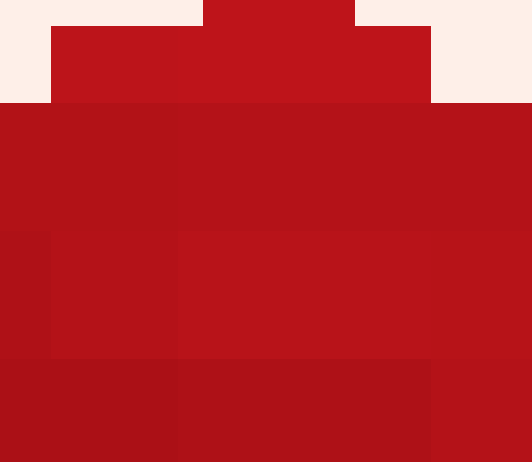

In [29]:
# Create the Folium map with custom settings
# ----------------------------------------------------

def create_folium_map_and_layers(results_dict, germany_gdf, 
                                 map_title="",
                                 overlay_opacity=0.7):
    """
    Creates a folium map, adds all relevant layers for:
      - Section 2 (50-year horizon)
      - Section 3 (100-year horizon)
    using the same naming style as the older code.

    Parameters
    ----------
    results_dict    : dict with keys:
                      - ql_NoUrban_map
                      - ql_Urban_map
                      - EnerUrb_map
                      - ql_UrbanRenew_map
                      - ql_UrbanRenew_max_map
                      - EnerUrbRenew_map
                      - extent
    germany_gdf     : GeoDataFrame for Germany boundary
    map_title       : Title to display at top of the map
    overlay_opacity : Float in [0..1], controlling overlay transparency
    """

    # 1) Basic map creation
    extent = results_dict["extent"]
    
    # Compute center lat/lon from extent
    center_lat = 0.5*(extent[2] + extent[3])
    center_lon = 0.5*(extent[0] + extent[1])
    
    m = folium.Map(location=[center_lat, center_lon], zoom_start=5, 
                   tiles="cartodbpositron")  # or any tile you prefer

    # 2) Add Germany boundary
    add_germany_boundary(m, germany_gdf, name="Germany Boundary")

    # 3) Extract arrays from results
    #ql_NoUrban_map        = results_dict["ql_NoUrban_map"]
    ql_Urban_map          = results_dict["ql_Urban_map"]
    EnerUrb_map           = results_dict["EnerUrb_map"]
    ql_UrbanRenew_map     = results_dict["ql_UrbanRenew_map"]
    ql_UrbanRenew_max_map = results_dict["ql_UrbanRenew_max_map"]
    EnerUrbRenew_map      = results_dict["EnerUrbRenew_map"]
    
    # 4) Define color scales for extraction rate and power
    #    (Adjust as needed for your data)
    ql_vmin,  ql_vmax  = 2, 55      # W/m
    pwr_vmin, pwr_vmax = 100, 6000   # W
    


    # -----------------------------
    # Section 2 (50-year horizon)
    # -----------------------------
    # 4a) No-Urban Delay
    # add_overlay_to_map(
    #     m, ql_NoUrban_map, 
    #     "ql_NoUrban (W/m)",          
    #     cmap_name="viridis", 
    #     extent=extent, 
    #     opacity=overlay_opacity, 
    #     vmin=None, 
    #     vmax=None
    # )

    # 4b) For each "urban delay" scenario: ql_Urban, EnerUrb
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))  # =0→50yrs
    arr_ql_Urban = ql_Urban_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_Urban), np.nanmax(arr_ql_Urban)
    print(f"[50-yr] ql_Urban delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    #for idx, turban in enumerate(turban_sec):
        #years = int(turban / (365*86400))
    add_overlay_to_map(
            m, arr_ql_Urban,
            f"Max Heat Extraction Rate [W/m] (no sustainable, turban = {yrs})",  
            cmap_name="viridis",
            extent=extent,
            opacity=overlay_opacity,
            vmin=ql_vmin,
            vmax=ql_vmax
        )
    # EnerUrb
    arr_EnerUrb = EnerUrb_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrb), np.nanmax(arr_EnerUrb)
    print(f"[50-yr] EnerUrb delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_EnerUrb,
            f"Usable Power [W] (turban = {yrs})",  
            cmap_name="Reds",
            extent=extent,
            opacity=overlay_opacity,
            vmin=pwr_vmin,
            vmax=pwr_vmax
        )

    # --------------------------------
    # Section 3 (100-year horizon)
    # --------------------------------
    # 4c) For each "urban delay" scenario: ql_UrbanRenew, ql_UrbanRenew_max, EnerUrbRenew
    # ----- 100-yr, idx=0 -----
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))
    #for idx, turban in enumerate(turban_sec):
        #years = int(turban / (365*86400))
     # ql_UrbanRenew
    arr_ql_UrbanRenew = ql_UrbanRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_UrbanRenew), np.nanmax(arr_ql_UrbanRenew)
    print(f"[100-yr] ql_UrbanRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_ql_UrbanRenew,
            f"Sustainable Heat Extraction Rate [W/m] (turban = {yrs})",  
            cmap_name="viridis",
            extent=extent,
            opacity=overlay_opacity,
            vmin=ql_vmin,
            vmax=ql_vmax
        )
    # EnerUrbRenew
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))
    arr_EnerUrbRenew = EnerUrbRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrbRenew), np.nanmax(arr_EnerUrbRenew)
    print(f"[100-yr] EnerUrbRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_EnerUrbRenew,
            f"Usable Power [W] under non-renewable rates (turban = {yrs})",  
            cmap_name="Reds",
            extent=extent,
            opacity=overlay_opacity,
            vmin=pwr_vmin,
            vmax=pwr_vmax
        )
        # add_overlay_to_map(
        #     m, EnerUrbRenew_map[:, :, idx],
        #     f"Usable Power under renewable rates [W] (sustainable, 100 years)turban = {years}",  
        #     cmap_name="Reds",
        #     extent=extent,
        #     opacity=overlay_opacity,
        #     vmin=None,
        #     vmax=None
        # )
    # ----- 100-yr max, idx=1 -----
    idx = 1
    yrs = int(turban_sec[idx] / (365*86400))
    # ql_UrbanRenew_max
    arr_ql_UrbanRenew_max = ql_UrbanRenew_max_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_UrbanRenew_max), np.nanmax(arr_ql_UrbanRenew_max)
    print(f"[100-yr] ql_UrbanRenew_max delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
        m, arr_ql_UrbanRenew_max,
        f"Max Sustainable Heat Extraction Rate [W/m] (turban = {yrs})",
        cmap_name="viridis", extent=extent,
        opacity=overlay_opacity, 
        vmin=ql_vmin,
        vmax=ql_vmax
    )
    # EnerUrbRenew again
    idx = 1
    yrs = int(turban_sec[idx] / (365*86400))
    arr_EnerUrbRenew_S = EnerUrbRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrbRenew_S), np.nanmax(arr_EnerUrbRenew_S)
    print(f"[100-yr] EnerUrbRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
        m, arr_EnerUrbRenew_S,
        f"Usable Power under renewable rates [W] (sustainable, turban = {yrs})",
        cmap_name="Reds", extent=extent,
        opacity=overlay_opacity, 
        vmin=pwr_vmin,
        vmax=pwr_vmax
    )

    # 5) Add a layer control so user can toggle layers
    folium.LayerControl().add_to(m)

    # 6) Add colorbar legends for ql (viridis) and power (plasma)
    add_fixed_legend(
        m, "fixed_legend_viridis",
        cmap_name="viridis",
        vmin=ql_vmin, vmax=ql_vmax,
        position='left', top_px=300,
        width=100, height=320,
        legend_title="Heat Extraction Rate (W/m)"
    )
    add_fixed_legend(
        m, "fixed_legend_Reds",
        cmap_name="Reds",
        vmin=pwr_vmin, vmax=pwr_vmax,
        position='right', top_px=300,
        width=100, height=320,
        legend_title="Usable Power (W)"
    )
    
    # 7) Add a title at the top
    map_title_html = f"""
    <div style="
        position: fixed;
        top: 5px;
        left: 50%;
        transform: translateX(-50%);
        z-index: 9999;
        font-size: 12px;
        font-weight: bold;
        background-color: rgba(255,255,255,0.8);
        padding: 4px;
        border: 1px solid grey;
    ">
      {map_title}
    </div>
    """
    m.get_root().html.add_child(folium.Element(map_title_html))

    return m
# Now we actually create and show the map with a custom title
custom_map_title = "Single BHE Analysis with GEE CMIP6 GISS Model (ssp585)"
overlay_opacity  = 0.7   # Adjust as you wish

m = create_folium_map_and_layers(
    results_dict=GISS_ssp585,
    germany_gdf=germany_shape,
    map_title=custom_map_title,
    overlay_opacity=overlay_opacity
)

m


In [30]:
# Load your GeoTIFF file and run the model (Sections 2 & 3)
# -------------------------------------------------------------------

# Provide your local file path here, including directories if needed.
geotiff_path = "HadGEM_ssp245_2000_2100_Germany_mean.tif"

# Choose a downsampling factor. Larger factors speed up the computation but lose spatial detail.
ds_factor = 10

# Run the model to get the results dictionary, which includes:
#  - ql_NoUrban_map, ql_Urban_map, EnerUrb_map  (Section 2)
#  - ql_UrbanRenew_map, ql_UrbanRenew_max_map, EnerUrbRenew_map (Section 3)
HadGEM_ssp245 = run_model_for_geotiff(
    geotiff_path=geotiff_path, 
    ds_factor=ds_factor
)

print("Model run completed for:", geotiff_path)
print("Results stored in 'HadGEM_ssp245'")

Loaded 'HadGEM_ssp245_2000_2100_Germany_mean.tif' with shape (176, 203).
Downsampled to shape: (18, 21)
Extent: (5.8839651109828655, 15.001865244796008, 47.2962997088928, 55.20147420914459)


/tmp/ipykernel_109826/3595534842.py:57: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sol_urb = fsolve(lambda ql: fzero_urban(ql, Tm_local), 10.0, xtol=1e-5)[0]


Model run completed for: HadGEM_ssp245_2000_2100_Germany_mean.tif
Results stored in 'HadGEM_ssp245'


[50-yr] ql_Urban delay=0yr → vmin=10.00, vmax=27.49
[50-yr] EnerUrb delay=0yr → vmin=1500.00, vmax=4122.98
[100-yr] ql_UrbanRenew delay=0yr → vmin=2.00, vmax=31.31
[100-yr] EnerUrbRenew delay=0yr → vmin=300.00, vmax=4696.51
[100-yr] ql_UrbanRenew_max delay=100yr → vmin=42.84, vmax=47.71
[100-yr] EnerUrbRenew delay=100yr → vmin=300.00, vmax=5628.31



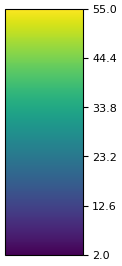
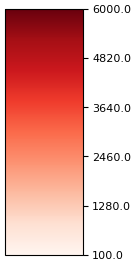
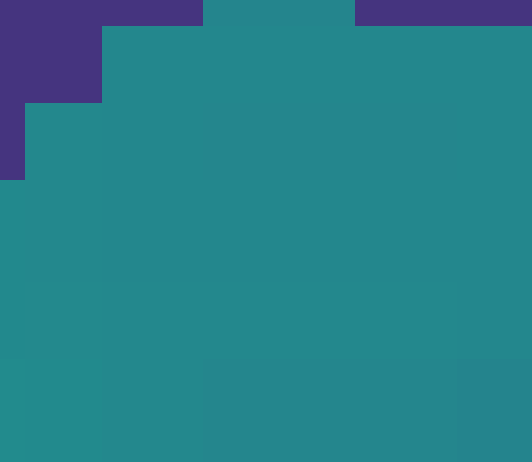
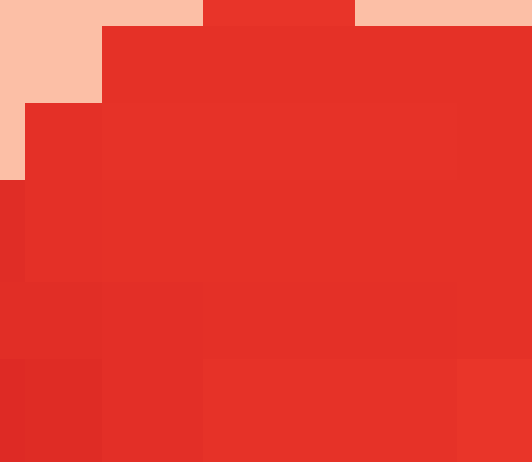
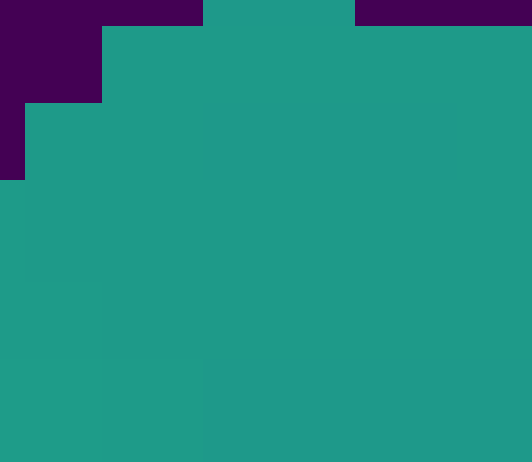
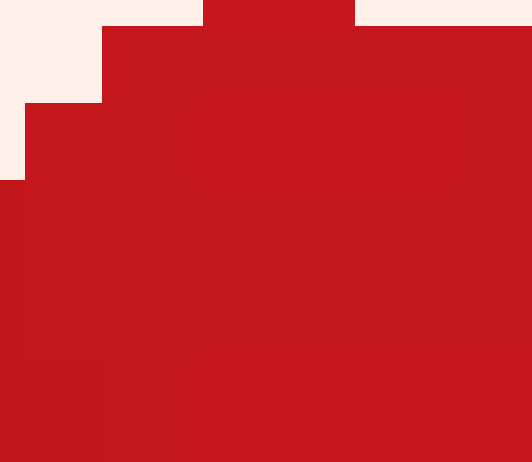
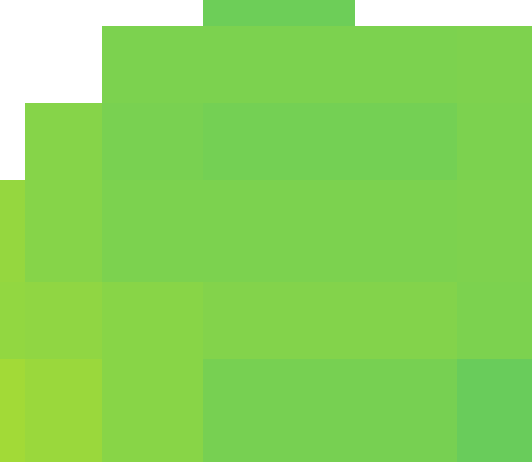
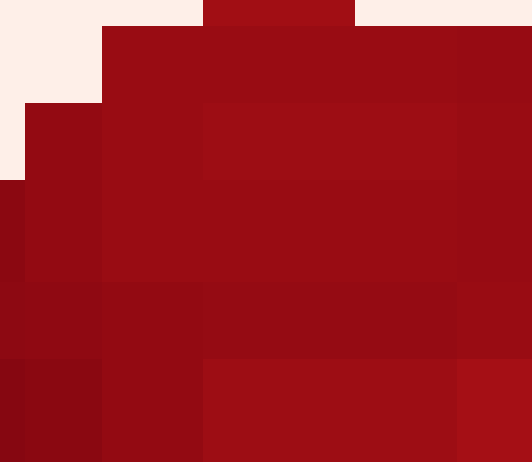

In [31]:
# Create the Folium map with custom settings
# ----------------------------------------------------

def create_folium_map_and_layers(results_dict, germany_gdf, 
                                 map_title="",
                                 overlay_opacity=0.7):
    """
    Creates a folium map, adds all relevant layers for:
      - Section 2 (50-year horizon)
      - Section 3 (100-year horizon)
    using the same naming style as the older code.

    Parameters
    ----------
    results_dict    : dict with keys:
                      - ql_NoUrban_map
                      - ql_Urban_map
                      - EnerUrb_map
                      - ql_UrbanRenew_map
                      - ql_UrbanRenew_max_map
                      - EnerUrbRenew_map
                      - extent
    germany_gdf     : GeoDataFrame for Germany boundary
    map_title       : Title to display at top of the map
    overlay_opacity : Float in [0..1], controlling overlay transparency
    """

    # 1) Basic map creation
    extent = results_dict["extent"]
    
    # Compute center lat/lon from extent
    center_lat = 0.5*(extent[2] + extent[3])
    center_lon = 0.5*(extent[0] + extent[1])
    
    m = folium.Map(location=[center_lat, center_lon], zoom_start=5, 
                   tiles="cartodbpositron")  # or any tile you prefer

    # 2) Add Germany boundary
    add_germany_boundary(m, germany_gdf, name="Germany Boundary")

    # 3) Extract arrays from results
    #ql_NoUrban_map        = results_dict["ql_NoUrban_map"]
    ql_Urban_map          = results_dict["ql_Urban_map"]
    EnerUrb_map           = results_dict["EnerUrb_map"]
    ql_UrbanRenew_map     = results_dict["ql_UrbanRenew_map"]
    ql_UrbanRenew_max_map = results_dict["ql_UrbanRenew_max_map"]
    EnerUrbRenew_map      = results_dict["EnerUrbRenew_map"]
    
    # 4) Define color scales for extraction rate and power
    #    (Adjust as needed for your data)
    ql_vmin,  ql_vmax  = 2, 55      # W/m
    pwr_vmin, pwr_vmax = 100, 6000   # W
    


    # -----------------------------
    # Section 2 (50-year horizon)
    # -----------------------------
    # 4a) No-Urban Delay
    # add_overlay_to_map(
    #     m, ql_NoUrban_map, 
    #     "ql_NoUrban (W/m)",          
    #     cmap_name="viridis", 
    #     extent=extent, 
    #     opacity=overlay_opacity, 
    #     vmin=None, 
    #     vmax=None
    # )

    # 4b) For each "urban delay" scenario: ql_Urban, EnerUrb
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))  # =0→50yrs
    arr_ql_Urban = ql_Urban_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_Urban), np.nanmax(arr_ql_Urban)
    print(f"[50-yr] ql_Urban delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    #for idx, turban in enumerate(turban_sec):
        #years = int(turban / (365*86400))
    add_overlay_to_map(
            m, arr_ql_Urban,
            f"Max Heat Extraction Rate [W/m] (no sustainable, turban = {yrs})",  
            cmap_name="viridis",
            extent=extent,
            opacity=overlay_opacity,
            vmin=ql_vmin,
            vmax=ql_vmax
        )
    # EnerUrb
    arr_EnerUrb = EnerUrb_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrb), np.nanmax(arr_EnerUrb)
    print(f"[50-yr] EnerUrb delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_EnerUrb,
            f"Usable Power [W] (turban = {yrs})",  
            cmap_name="Reds",
            extent=extent,
            opacity=overlay_opacity,
            vmin=pwr_vmin,
            vmax=pwr_vmax
        )

    # --------------------------------
    # Section 3 (100-year horizon)
    # --------------------------------
    # 4c) For each "urban delay" scenario: ql_UrbanRenew, ql_UrbanRenew_max, EnerUrbRenew
    # ----- 100-yr, idx=0 -----
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))
    #for idx, turban in enumerate(turban_sec):
        #years = int(turban / (365*86400))
     # ql_UrbanRenew
    arr_ql_UrbanRenew = ql_UrbanRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_UrbanRenew), np.nanmax(arr_ql_UrbanRenew)
    print(f"[100-yr] ql_UrbanRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_ql_UrbanRenew,
            f"Sustainable Heat Extraction Rate [W/m] (turban = {yrs})",  
            cmap_name="viridis",
            extent=extent,
            opacity=overlay_opacity,
            vmin=ql_vmin,
            vmax=ql_vmax
        )
    # EnerUrbRenew
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))
    arr_EnerUrbRenew = EnerUrbRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrbRenew), np.nanmax(arr_EnerUrbRenew)
    print(f"[100-yr] EnerUrbRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_EnerUrbRenew,
            f"Usable Power [W] under non-renewable rates (turban = {yrs})",  
            cmap_name="Reds",
            extent=extent,
            opacity=overlay_opacity,
            vmin=pwr_vmin,
            vmax=pwr_vmax
        )
        # add_overlay_to_map(
        #     m, EnerUrbRenew_map[:, :, idx],
        #     f"Usable Power under renewable rates [W] (sustainable, 100 years)turban = {years}",  
        #     cmap_name="Reds",
        #     extent=extent,
        #     opacity=overlay_opacity,
        #     vmin=None,
        #     vmax=None
        # )
    # ----- 100-yr max, idx=1 -----
    idx = 1
    yrs = int(turban_sec[idx] / (365*86400))
    # ql_UrbanRenew_max
    arr_ql_UrbanRenew_max = ql_UrbanRenew_max_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_UrbanRenew_max), np.nanmax(arr_ql_UrbanRenew_max)
    print(f"[100-yr] ql_UrbanRenew_max delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
        m, arr_ql_UrbanRenew_max,
        f"Max Sustainable Heat Extraction Rate [W/m] (turban = {yrs})",
        cmap_name="viridis", extent=extent,
        opacity=overlay_opacity, 
        vmin=ql_vmin,
        vmax=ql_vmax
    )
    # EnerUrbRenew again
    idx = 1
    yrs = int(turban_sec[idx] / (365*86400))
    arr_EnerUrbRenew_S = EnerUrbRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrbRenew_S), np.nanmax(arr_EnerUrbRenew_S)
    print(f"[100-yr] EnerUrbRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
        m, arr_EnerUrbRenew_S,
        f"Usable Power under renewable rates [W] (sustainable, turban = {yrs})",
        cmap_name="Reds", extent=extent,
        opacity=overlay_opacity, 
        vmin=pwr_vmin,
        vmax=pwr_vmax
    )

    # 5) Add a layer control so user can toggle layers
    folium.LayerControl().add_to(m)

    # 6) Add colorbar legends for ql (viridis) and power (plasma)
    add_fixed_legend(
        m, "fixed_legend_viridis",
        cmap_name="viridis",
        vmin=ql_vmin, vmax=ql_vmax,
        position='left', top_px=300,
        width=100, height=320,
        legend_title="Heat Extraction Rate (W/m)"
    )
    add_fixed_legend(
        m, "fixed_legend_Reds",
        cmap_name="Reds",
        vmin=pwr_vmin, vmax=pwr_vmax,
        position='right', top_px=300,
        width=100, height=320,
        legend_title="Usable Power (W)"
    )

    # 8) Add a title at the top
    map_title_html = f"""
    <div style="
        position: fixed;
        top: 5px;
        left: 50%;
        transform: translateX(-50%);
        z-index: 9999;
        font-size: 12px;
        font-weight: bold;
        background-color: rgba(255,255,255,0.8);
        padding: 4px;
        border: 1px solid grey;
    ">
      {map_title}
    </div>
    """
    m.get_root().html.add_child(folium.Element(map_title_html))

    return m
# Now we actually create and show the map with a custom title
custom_map_title = "Single BHE Analysis with GEE CMIP6 HadGEM Model (ssp245)"
overlay_opacity  = 0.7   # Adjust as you wish

m = create_folium_map_and_layers(
    results_dict=HadGEM_ssp245,
    germany_gdf=germany_shape,
    map_title=custom_map_title,
    overlay_opacity=overlay_opacity
)

m


In [32]:
# Load your GeoTIFF file and run the model (Sections 2 & 3)
# -------------------------------------------------------------------

# Provide your local file path here, including directories if needed.
geotiff_path = "HadGEM_ssp585_2000_2100_Germany_mean.tif"

# Choose a downsampling factor. Larger factors speed up the computation but lose spatial detail.
ds_factor = 10

# Run the model to get the results dictionary, which includes:
#  - ql_NoUrban_map, ql_Urban_map, EnerUrb_map  (Section 2)
#  - ql_UrbanRenew_map, ql_UrbanRenew_max_map, EnerUrbRenew_map (Section 3)
HadGEM_ssp585 = run_model_for_geotiff(
    geotiff_path=geotiff_path, 
    ds_factor=ds_factor
)

print("Model run completed for:", geotiff_path)
print("Results stored in 'HadGEM_ssp585'")

Loaded 'HadGEM_ssp585_2000_2100_Germany_mean.tif' with shape (176, 203).
Downsampled to shape: (18, 21)
Extent: (5.8839651109828655, 15.001865244796008, 47.2962997088928, 55.20147420914459)


/tmp/ipykernel_109826/3595534842.py:57: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sol_urb = fsolve(lambda ql: fzero_urban(ql, Tm_local), 10.0, xtol=1e-5)[0]


Model run completed for: HadGEM_ssp585_2000_2100_Germany_mean.tif
Results stored in 'HadGEM_ssp585'


[50-yr] ql_Urban delay=0yr → vmin=10.00, vmax=28.02
[50-yr] EnerUrb delay=0yr → vmin=1500.00, vmax=4202.27
[100-yr] ql_UrbanRenew delay=0yr → vmin=2.00, vmax=31.55
[100-yr] EnerUrbRenew delay=0yr → vmin=300.00, vmax=4732.34
[100-yr] ql_UrbanRenew_max delay=100yr → vmin=44.64, vmax=49.41
[100-yr] EnerUrbRenew delay=100yr → vmin=300.00, vmax=5755.24



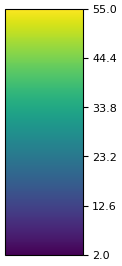
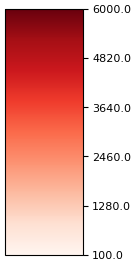
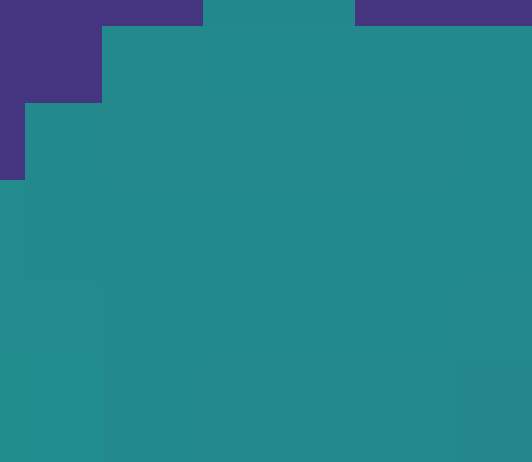
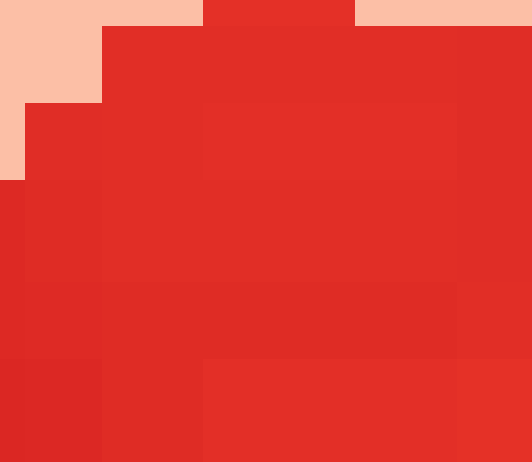
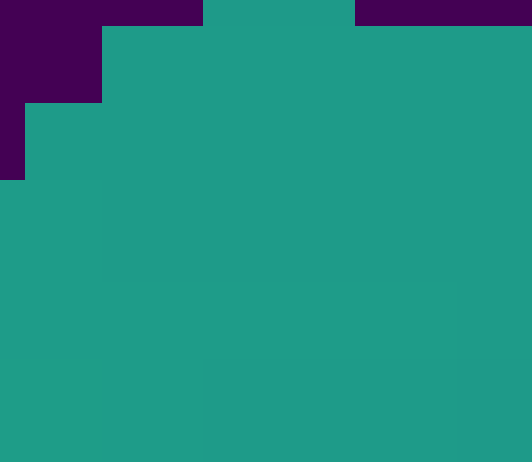
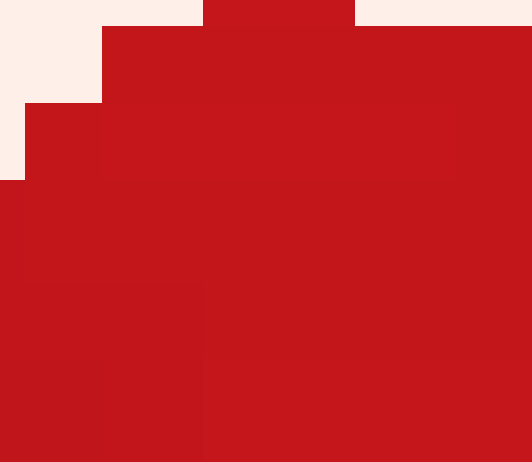
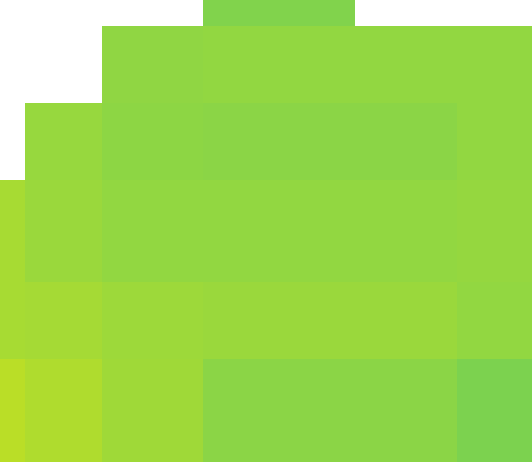
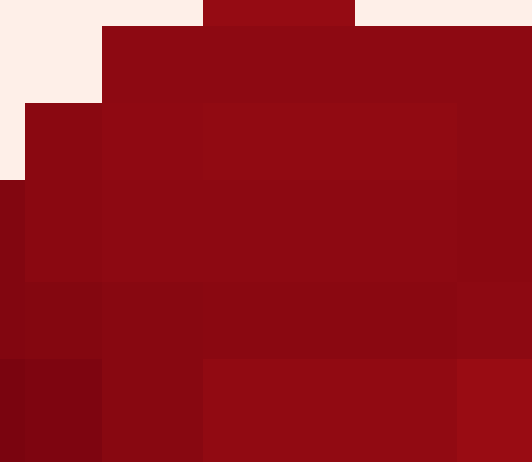

In [33]:
# Create the Folium map with custom settings
# ----------------------------------------------------

def create_folium_map_and_layers(results_dict, germany_gdf, 
                                 map_title="",
                                 overlay_opacity=0.7):
    """
    Creates a folium map, adds all relevant layers for:
      - Section 2 (50-year horizon)
      - Section 3 (100-year horizon)
    using the same naming style as the older code.

    Parameters
    ----------
    results_dict    : dict with keys:
                      - ql_NoUrban_map
                      - ql_Urban_map
                      - EnerUrb_map
                      - ql_UrbanRenew_map
                      - ql_UrbanRenew_max_map
                      - EnerUrbRenew_map
                      - extent
    germany_gdf     : GeoDataFrame for Germany boundary
    map_title       : Title to display at top of the map
    overlay_opacity : Float in [0..1], controlling overlay transparency
    """

    # 1) Basic map creation
    extent = results_dict["extent"]
    
    # Compute center lat/lon from extent
    center_lat = 0.5*(extent[2] + extent[3])
    center_lon = 0.5*(extent[0] + extent[1])
    
    m = folium.Map(location=[center_lat, center_lon], zoom_start=5, 
                   tiles="cartodbpositron")  # or any tile you prefer

    # 2) Add Germany boundary
    add_germany_boundary(m, germany_gdf, name="Germany Boundary")

    # 3) Extract arrays from results
    #ql_NoUrban_map        = results_dict["ql_NoUrban_map"]
    ql_Urban_map          = results_dict["ql_Urban_map"]
    EnerUrb_map           = results_dict["EnerUrb_map"]
    ql_UrbanRenew_map     = results_dict["ql_UrbanRenew_map"]
    ql_UrbanRenew_max_map = results_dict["ql_UrbanRenew_max_map"]
    EnerUrbRenew_map      = results_dict["EnerUrbRenew_map"]
    
    # 4) Define color scales for extraction rate and power
    #    (Adjust as needed for your data)
    ql_vmin,  ql_vmax  = 2, 55      # W/m
    pwr_vmin, pwr_vmax = 100, 6000   # W
    


    # -----------------------------
    # Section 2 (50-year horizon)
    # -----------------------------
    # 4a) No-Urban Delay
    # add_overlay_to_map(
    #     m, ql_NoUrban_map, 
    #     "ql_NoUrban (W/m)",          
    #     cmap_name="viridis", 
    #     extent=extent, 
    #     opacity=overlay_opacity, 
    #     vmin=None, 
    #     vmax=None
    # )

    # 4b) For each "urban delay" scenario: ql_Urban, EnerUrb
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))  # =0→50yrs
    arr_ql_Urban = ql_Urban_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_Urban), np.nanmax(arr_ql_Urban)
    print(f"[50-yr] ql_Urban delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    #for idx, turban in enumerate(turban_sec):
        #years = int(turban / (365*86400))
    add_overlay_to_map(
            m, arr_ql_Urban,
            f"Max Heat Extraction Rate [W/m] (no sustainable, turban = {yrs})",  
            cmap_name="viridis",
            extent=extent,
            opacity=overlay_opacity,
            vmin=ql_vmin,
            vmax=ql_vmax
        )
    # EnerUrb
    arr_EnerUrb = EnerUrb_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrb), np.nanmax(arr_EnerUrb)
    print(f"[50-yr] EnerUrb delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_EnerUrb,
            f"Usable Power [W] (turban = {yrs})",  
            cmap_name="Reds",
            extent=extent,
            opacity=overlay_opacity,
            vmin=pwr_vmin,
            vmax=pwr_vmax
        )

    # --------------------------------
    # Section 3 (100-year horizon)
    # --------------------------------
    # 4c) For each "urban delay" scenario: ql_UrbanRenew, ql_UrbanRenew_max, EnerUrbRenew
    # ----- 100-yr, idx=0 -----
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))
    #for idx, turban in enumerate(turban_sec):
        #years = int(turban / (365*86400))
     # ql_UrbanRenew
    arr_ql_UrbanRenew = ql_UrbanRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_UrbanRenew), np.nanmax(arr_ql_UrbanRenew)
    print(f"[100-yr] ql_UrbanRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_ql_UrbanRenew,
            f"Sustainable Heat Extraction Rate [W/m] (turban = {yrs})",  
            cmap_name="viridis",
            extent=extent,
            opacity=overlay_opacity,
            vmin=ql_vmin,
            vmax=ql_vmax
        )
    # EnerUrbRenew
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))
    arr_EnerUrbRenew = EnerUrbRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrbRenew), np.nanmax(arr_EnerUrbRenew)
    print(f"[100-yr] EnerUrbRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_EnerUrbRenew,
            f"Usable Power [W] under non-renewable rates (turban = {yrs})",  
            cmap_name="Reds",
            extent=extent,
            opacity=overlay_opacity,
            vmin=pwr_vmin,
            vmax=pwr_vmax
        )
        # add_overlay_to_map(
        #     m, EnerUrbRenew_map[:, :, idx],
        #     f"Usable Power under renewable rates [W] (sustainable, 100 years)turban = {years}",  
        #     cmap_name="Reds",
        #     extent=extent,
        #     opacity=overlay_opacity,
        #     vmin=None,
        #     vmax=None
        # )
    # ----- 100-yr max, idx=1 -----
    idx = 1
    yrs = int(turban_sec[idx] / (365*86400))
    # ql_UrbanRenew_max
    arr_ql_UrbanRenew_max = ql_UrbanRenew_max_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_UrbanRenew_max), np.nanmax(arr_ql_UrbanRenew_max)
    print(f"[100-yr] ql_UrbanRenew_max delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
        m, arr_ql_UrbanRenew_max,
        f"Max Sustainable Heat Extraction Rate [W/m] (turban = {yrs})",
        cmap_name="viridis", extent=extent,
        opacity=overlay_opacity, 
        vmin=ql_vmin,
        vmax=ql_vmax
    )
    # EnerUrbRenew again
    idx = 1
    yrs = int(turban_sec[idx] / (365*86400))
    arr_EnerUrbRenew_S = EnerUrbRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrbRenew_S), np.nanmax(arr_EnerUrbRenew_S)
    print(f"[100-yr] EnerUrbRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
        m, arr_EnerUrbRenew_S,
        f"Usable Power under renewable rates [W] (sustainable, turban = {yrs})",
        cmap_name="Reds", extent=extent,
        opacity=overlay_opacity, 
        vmin=pwr_vmin,
        vmax=pwr_vmax
    )

    # 5) Add a layer control so user can toggle layers
    folium.LayerControl().add_to(m)

    # 6) Add colorbar legends for ql (viridis) and power (plasma)
    add_fixed_legend(
        m, "fixed_legend_viridis",
        cmap_name="viridis",
        vmin=ql_vmin, vmax=ql_vmax,
        position='left', top_px=300,
        width=100, height=320,
        legend_title="Heat Extraction Rate (W/m)"
    )
    add_fixed_legend(
        m, "fixed_legend_Reds",
        cmap_name="Reds",
        vmin=pwr_vmin, vmax=pwr_vmax,
        position='right', top_px=300,
        width=100, height=320,
        legend_title="Usable Power (W)"
    )

    # 7) Add a title at the top
    map_title_html = f"""
    <div style="
        position: fixed;
        top: 5px;
        left: 50%;
        transform: translateX(-50%);
        z-index: 9999;
        font-size: 12px;
        font-weight: bold;
        background-color: rgba(255,255,255,0.8);
        padding: 4px;
        border: 1px solid grey;
    ">
      {map_title}
    </div>
    """
    m.get_root().html.add_child(folium.Element(map_title_html))

    return m
# Now we actually create and show the map with a custom title
custom_map_title = "Single BHE Analysis with GEE CMIP6 HadGEM Model (ssp585)"
overlay_opacity  = 0.7   # Adjust as you wish

m = create_folium_map_and_layers(
    results_dict=HadGEM_ssp585,
    germany_gdf=germany_shape,
    map_title=custom_map_title,
    overlay_opacity=overlay_opacity
)

m


In [34]:
# Load your GeoTIFF file and run the model (Sections 2 & 3)
# -------------------------------------------------------------------

# Provide your local file path here, including directories if needed.
geotiff_path = "IPSL_ssp245_2000_2100_Germany_mean.tif"

# Choose a downsampling factor. Larger factors speed up the computation but lose spatial detail.
ds_factor = 10

# Run the model to get the results dictionary, which includes:
#  - ql_NoUrban_map, ql_Urban_map, EnerUrb_map  (Section 2)
#  - ql_UrbanRenew_map, ql_UrbanRenew_max_map, EnerUrbRenew_map (Section 3)
IPSL_ssp245 = run_model_for_geotiff(
    geotiff_path=geotiff_path, 
    ds_factor=ds_factor
)

print("Model run completed for:", geotiff_path)
print("Results stored in 'IPSL_ssp245'")

Loaded 'IPSL_ssp245_2000_2100_Germany_mean.tif' with shape (176, 203).
Downsampled to shape: (18, 21)
Extent: (5.8839651109828655, 15.001865244796008, 47.2962997088928, 55.20147420914459)


/tmp/ipykernel_109826/3595534842.py:57: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sol_urb = fsolve(lambda ql: fzero_urban(ql, Tm_local), 10.0, xtol=1e-5)[0]


Model run completed for: IPSL_ssp245_2000_2100_Germany_mean.tif
Results stored in 'IPSL_ssp245'


[50-yr] ql_Urban delay=0yr → vmin=10.00, vmax=28.10
[50-yr] EnerUrb delay=0yr → vmin=1500.00, vmax=4215.51
[100-yr] ql_UrbanRenew delay=0yr → vmin=2.00, vmax=31.59
[100-yr] EnerUrbRenew delay=0yr → vmin=300.00, vmax=4738.14
[100-yr] ql_UrbanRenew_max delay=100yr → vmin=43.39, vmax=49.69
[100-yr] EnerUrbRenew delay=100yr → vmin=300.00, vmax=5776.38



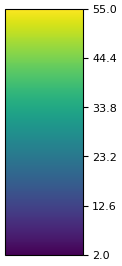
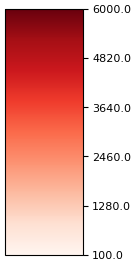
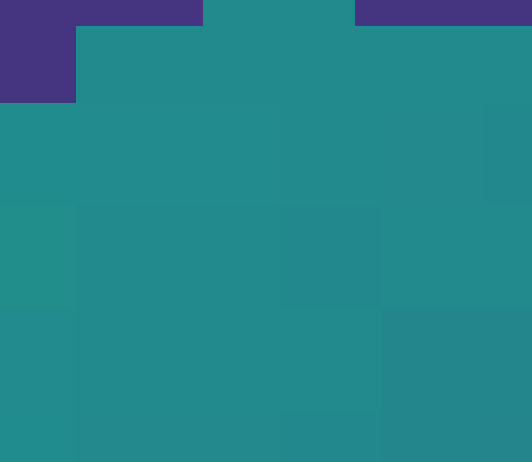
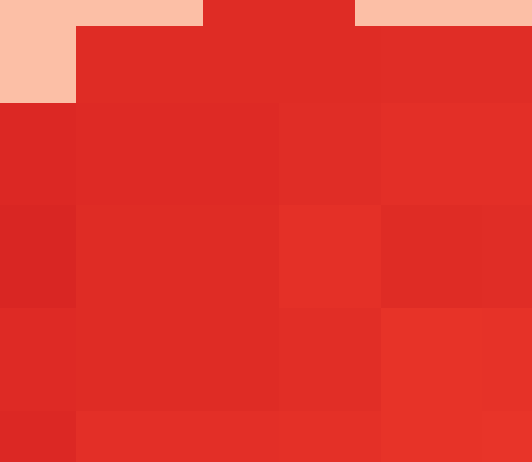
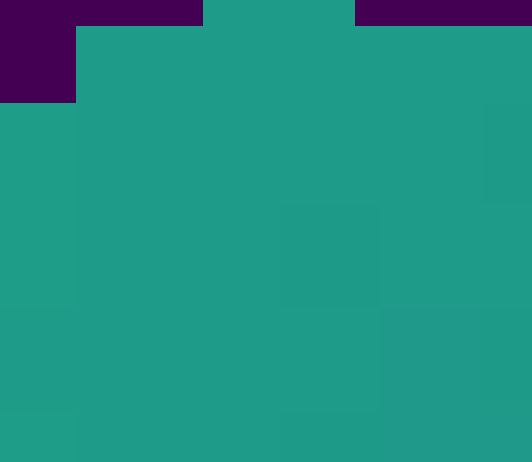
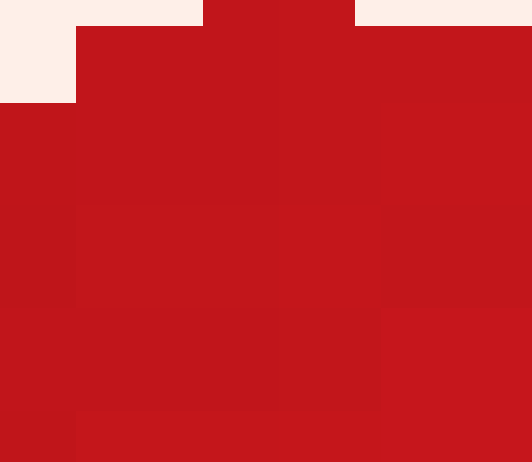
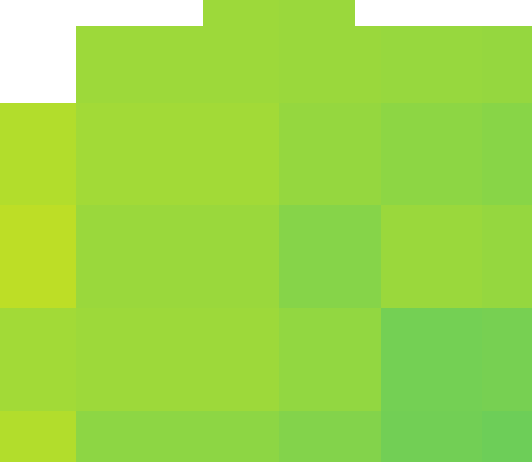
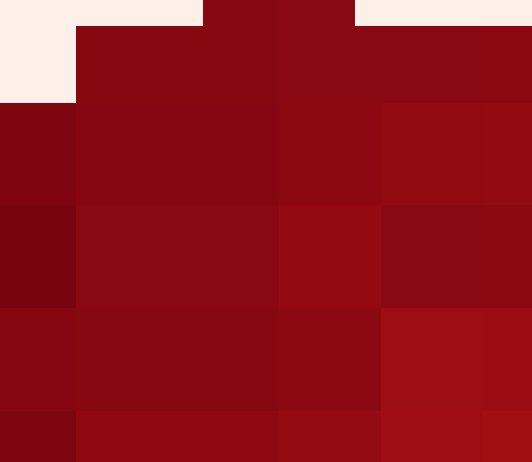

In [35]:
# Create the Folium map with custom settings
# ----------------------------------------------------

def create_folium_map_and_layers(results_dict, germany_gdf, 
                                 map_title="",
                                 overlay_opacity=0.7):
    """
    Creates a folium map, adds all relevant layers for:
      - Section 2 (50-year horizon)
      - Section 3 (100-year horizon)
    using the same naming style as the older code.

    Parameters
    ----------
    results_dict    : dict with keys:
                      - ql_NoUrban_map
                      - ql_Urban_map
                      - EnerUrb_map
                      - ql_UrbanRenew_map
                      - ql_UrbanRenew_max_map
                      - EnerUrbRenew_map
                      - extent
    germany_gdf     : GeoDataFrame for Germany boundary
    map_title       : Title to display at top of the map
    overlay_opacity : Float in [0..1], controlling overlay transparency
    """

    # 1) Basic map creation
    extent = results_dict["extent"]
    
    # Compute center lat/lon from extent
    center_lat = 0.5*(extent[2] + extent[3])
    center_lon = 0.5*(extent[0] + extent[1])
    
    m = folium.Map(location=[center_lat, center_lon], zoom_start=5, 
                   tiles="cartodbpositron")  # or any tile you prefer

    # 2) Add Germany boundary
    add_germany_boundary(m, germany_gdf, name="Germany Boundary")

    # 3) Extract arrays from results
    #ql_NoUrban_map        = results_dict["ql_NoUrban_map"]
    ql_Urban_map          = results_dict["ql_Urban_map"]
    EnerUrb_map           = results_dict["EnerUrb_map"]
    ql_UrbanRenew_map     = results_dict["ql_UrbanRenew_map"]
    ql_UrbanRenew_max_map = results_dict["ql_UrbanRenew_max_map"]
    EnerUrbRenew_map      = results_dict["EnerUrbRenew_map"]
    
    # 4) Define color scales for extraction rate and power
    #    (Adjust as needed for your data)
    ql_vmin,  ql_vmax  = 2, 55      # W/m
    pwr_vmin, pwr_vmax = 100, 6000   # W
    


    # -----------------------------
    # Section 2 (50-year horizon)
    # -----------------------------
    # 4a) No-Urban Delay
    # add_overlay_to_map(
    #     m, ql_NoUrban_map, 
    #     "ql_NoUrban (W/m)",          
    #     cmap_name="viridis", 
    #     extent=extent, 
    #     opacity=overlay_opacity, 
    #     vmin=None, 
    #     vmax=None
    # )

    # 4b) For each "urban delay" scenario: ql_Urban, EnerUrb
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))  # =0→50yrs
    arr_ql_Urban = ql_Urban_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_Urban), np.nanmax(arr_ql_Urban)
    print(f"[50-yr] ql_Urban delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    #for idx, turban in enumerate(turban_sec):
        #years = int(turban / (365*86400))
    add_overlay_to_map(
            m, arr_ql_Urban,
            f"Max Heat Extraction Rate [W/m] (no sustainable, turban = {yrs})",  
            cmap_name="viridis",
            extent=extent,
            opacity=overlay_opacity,
            vmin=ql_vmin,
            vmax=ql_vmax
        )
    # EnerUrb
    arr_EnerUrb = EnerUrb_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrb), np.nanmax(arr_EnerUrb)
    print(f"[50-yr] EnerUrb delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_EnerUrb,
            f"Usable Power [W] (turban = {yrs})",  
            cmap_name="Reds",
            extent=extent,
            opacity=overlay_opacity,
            vmin=pwr_vmin,
            vmax=pwr_vmax
        )

    # --------------------------------
    # Section 3 (100-year horizon)
    # --------------------------------
    # 4c) For each "urban delay" scenario: ql_UrbanRenew, ql_UrbanRenew_max, EnerUrbRenew
    # ----- 100-yr, idx=0 -----
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))
    #for idx, turban in enumerate(turban_sec):
        #years = int(turban / (365*86400))
     # ql_UrbanRenew
    arr_ql_UrbanRenew = ql_UrbanRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_UrbanRenew), np.nanmax(arr_ql_UrbanRenew)
    print(f"[100-yr] ql_UrbanRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_ql_UrbanRenew,
            f"Sustainable Heat Extraction Rate [W/m] (turban = {yrs})",  
            cmap_name="viridis",
            extent=extent,
            opacity=overlay_opacity,
            vmin=ql_vmin,
            vmax=ql_vmax
        )
    # EnerUrbRenew
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))
    arr_EnerUrbRenew = EnerUrbRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrbRenew), np.nanmax(arr_EnerUrbRenew)
    print(f"[100-yr] EnerUrbRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_EnerUrbRenew,
            f"Usable Power [W] under non-renewable rates (turban = {yrs})",  
            cmap_name="Reds",
            extent=extent,
            opacity=overlay_opacity,
            vmin=pwr_vmin,
            vmax=pwr_vmax
        )
        # add_overlay_to_map(
        #     m, EnerUrbRenew_map[:, :, idx],
        #     f"Usable Power under renewable rates [W] (sustainable, 100 years)turban = {years}",  
        #     cmap_name="Reds",
        #     extent=extent,
        #     opacity=overlay_opacity,
        #     vmin=None,
        #     vmax=None
        # )
    # ----- 100-yr max, idx=1 -----
    idx = 1
    yrs = int(turban_sec[idx] / (365*86400))
    # ql_UrbanRenew_max
    arr_ql_UrbanRenew_max = ql_UrbanRenew_max_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_UrbanRenew_max), np.nanmax(arr_ql_UrbanRenew_max)
    print(f"[100-yr] ql_UrbanRenew_max delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
        m, arr_ql_UrbanRenew_max,
        f"Max Sustainable Heat Extraction Rate [W/m] (turban = {yrs})",
        cmap_name="viridis", extent=extent,
        opacity=overlay_opacity, 
        vmin=ql_vmin,
        vmax=ql_vmax
    )
    # EnerUrbRenew again
    idx = 1
    yrs = int(turban_sec[idx] / (365*86400))
    arr_EnerUrbRenew_S = EnerUrbRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrbRenew_S), np.nanmax(arr_EnerUrbRenew_S)
    print(f"[100-yr] EnerUrbRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
        m, arr_EnerUrbRenew_S,
        f"Usable Power under renewable rates [W] (sustainable, turban = {yrs})",
        cmap_name="Reds", extent=extent,
        opacity=overlay_opacity, 
        vmin=pwr_vmin,
        vmax=pwr_vmax
    )

    # 5) Add a layer control so user can toggle layers
    folium.LayerControl().add_to(m)

    # 6) Add colorbar legends for ql (viridis) and power (plasma)
    add_fixed_legend(
        m, "fixed_legend_viridis",
        cmap_name="viridis",
        vmin=ql_vmin, vmax=ql_vmax,
        position='left', top_px=300,
        width=100, height=320,
        legend_title="Heat Extraction Rate (W/m)"
    )
    add_fixed_legend(
        m, "fixed_legend_Reds",
        cmap_name="Reds",
        vmin=pwr_vmin, vmax=pwr_vmax,
        position='right', top_px=300,
        width=100, height=320,
        legend_title="Usable Power (W)"
    )

    # 7) Add a title at the top
    map_title_html = f"""
    <div style="
        position: fixed;
        top: 5px;
        left: 50%;
        transform: translateX(-50%);
        z-index: 9999;
        font-size: 12px;
        font-weight: bold;
        background-color: rgba(255,255,255,0.8);
        padding: 4px;
        border: 1px solid grey;
    ">
      {map_title}
    </div>
    """
    m.get_root().html.add_child(folium.Element(map_title_html))

    return m
# Now we actually create and show the map with a custom title
custom_map_title = "Single BHE Analysis with GEE CMIP6 IPSL Model (ssp245)"
overlay_opacity  = 0.7   # Adjust as you wish

m = create_folium_map_and_layers(
    results_dict=IPSL_ssp245,
    germany_gdf=germany_shape,
    map_title=custom_map_title,
    overlay_opacity=overlay_opacity
)

m


In [36]:
# Load your GeoTIFF file and run the model (Sections 2 & 3)
# -------------------------------------------------------------------

# Provide your local file path here, including directories if needed.
geotiff_path = "IPSL_ssp585_2000_2100_Germany_mean.tif"

# Choose a downsampling factor. Larger factors speed up the computation but lose spatial detail.
ds_factor = 10

# Run the model to get the results dictionary, which includes:
#  - ql_NoUrban_map, ql_Urban_map, EnerUrb_map  (Section 2)
#  - ql_UrbanRenew_map, ql_UrbanRenew_max_map, EnerUrbRenew_map (Section 3)
IPSL_ssp585 = run_model_for_geotiff(
    geotiff_path=geotiff_path, 
    ds_factor=ds_factor
)

print("Model run completed for:", geotiff_path)
print("Results stored in 'IPSL_ssp585'")

Loaded 'IPSL_ssp585_2000_2100_Germany_mean.tif' with shape (176, 203).
Downsampled to shape: (18, 21)
Extent: (5.8839651109828655, 15.001865244796008, 47.2962997088928, 55.20147420914459)


/tmp/ipykernel_109826/3595534842.py:57: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sol_urb = fsolve(lambda ql: fzero_urban(ql, Tm_local), 10.0, xtol=1e-5)[0]


Model run completed for: IPSL_ssp585_2000_2100_Germany_mean.tif
Results stored in 'IPSL_ssp585'


[50-yr] ql_Urban delay=0yr → vmin=10.00, vmax=28.65
[50-yr] EnerUrb delay=0yr → vmin=1500.00, vmax=4298.08
[100-yr] ql_UrbanRenew delay=0yr → vmin=2.00, vmax=31.82
[100-yr] EnerUrbRenew delay=0yr → vmin=300.00, vmax=4773.54
[100-yr] ql_UrbanRenew_max delay=100yr → vmin=45.57, vmax=51.46
[100-yr] EnerUrbRenew delay=100yr → vmin=300.00, vmax=5908.03



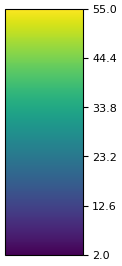
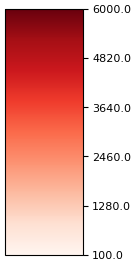
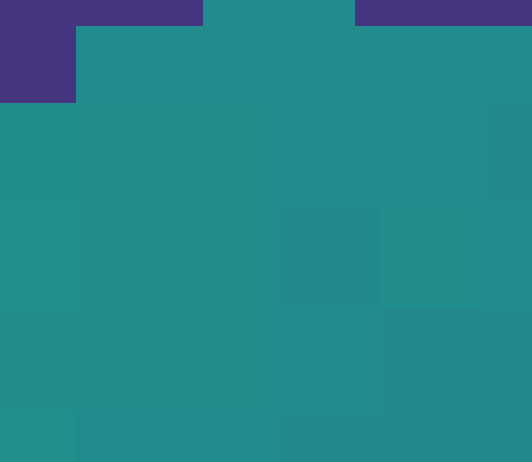
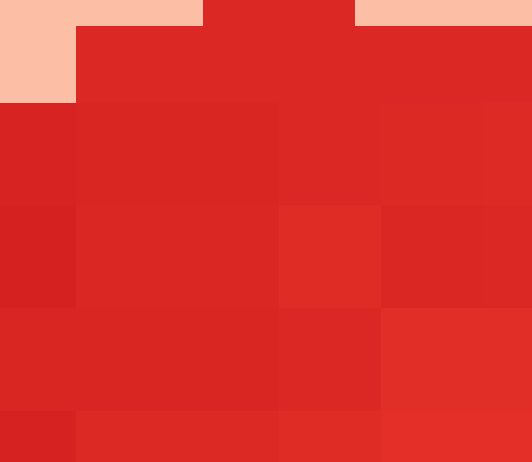
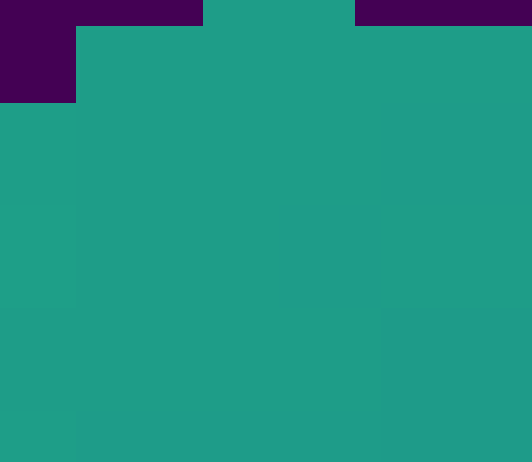
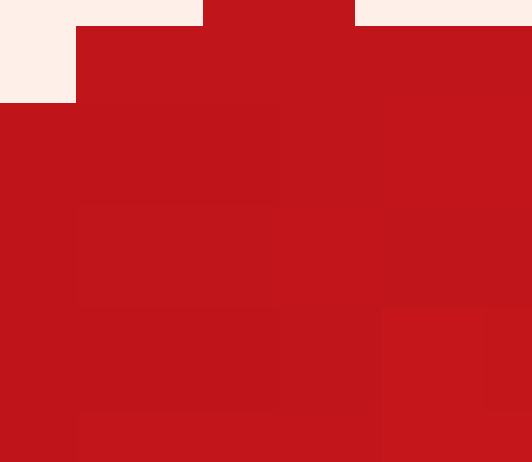
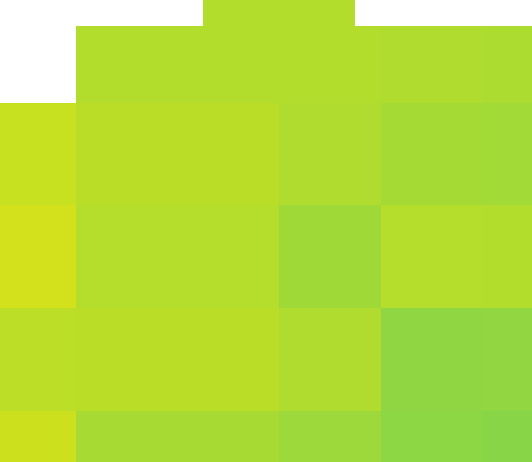
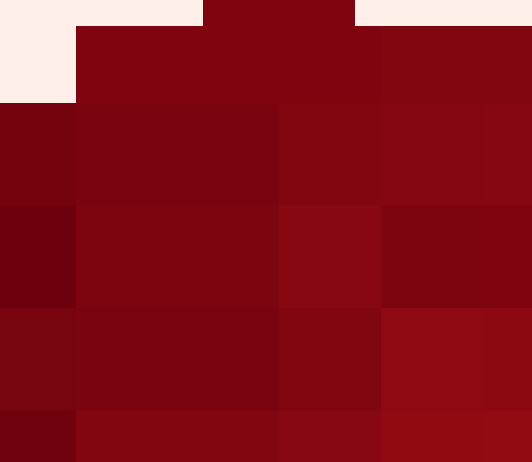

In [37]:
# Create the Folium map with custom settings
# ----------------------------------------------------

def create_folium_map_and_layers(results_dict, germany_gdf, 
                                 map_title="",
                                 overlay_opacity=0.7):
    """
    Creates a folium map, adds all relevant layers for:
      - Section 2 (50-year horizon)
      - Section 3 (100-year horizon)
    using the same naming style as the older code.

    Parameters
    ----------
    results_dict    : dict with keys:
                      - ql_NoUrban_map
                      - ql_Urban_map
                      - EnerUrb_map
                      - ql_UrbanRenew_map
                      - ql_UrbanRenew_max_map
                      - EnerUrbRenew_map
                      - extent
    germany_gdf     : GeoDataFrame for Germany boundary
    map_title       : Title to display at top of the map
    overlay_opacity : Float in [0..1], controlling overlay transparency
    """

    # 1) Basic map creation
    extent = results_dict["extent"]
    
    # Compute center lat/lon from extent
    center_lat = 0.5*(extent[2] + extent[3])
    center_lon = 0.5*(extent[0] + extent[1])
    
    m = folium.Map(location=[center_lat, center_lon], zoom_start=5, 
                   tiles="cartodbpositron")  # or any tile you prefer

    # 2) Add Germany boundary
    add_germany_boundary(m, germany_gdf, name="Germany Boundary")

    # 3) Extract arrays from results
    #ql_NoUrban_map        = results_dict["ql_NoUrban_map"]
    ql_Urban_map          = results_dict["ql_Urban_map"]
    EnerUrb_map           = results_dict["EnerUrb_map"]
    ql_UrbanRenew_map     = results_dict["ql_UrbanRenew_map"]
    ql_UrbanRenew_max_map = results_dict["ql_UrbanRenew_max_map"]
    EnerUrbRenew_map      = results_dict["EnerUrbRenew_map"]
    
    # 4) Define color scales for extraction rate and power
    #    (Adjust as needed for your data)
    ql_vmin,  ql_vmax  = 2, 55      # W/m
    pwr_vmin, pwr_vmax = 100, 6000   # W
    


    # -----------------------------
    # Section 2 (50-year horizon)
    # -----------------------------
    # 4a) No-Urban Delay
    # add_overlay_to_map(
    #     m, ql_NoUrban_map, 
    #     "ql_NoUrban (W/m)",          
    #     cmap_name="viridis", 
    #     extent=extent, 
    #     opacity=overlay_opacity, 
    #     vmin=None, 
    #     vmax=None
    # )

    # 4b) For each "urban delay" scenario: ql_Urban, EnerUrb
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))  # =0→50yrs
    arr_ql_Urban = ql_Urban_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_Urban), np.nanmax(arr_ql_Urban)
    print(f"[50-yr] ql_Urban delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    #for idx, turban in enumerate(turban_sec):
        #years = int(turban / (365*86400))
    add_overlay_to_map(
            m, arr_ql_Urban,
            f"Max Heat Extraction Rate [W/m] (no sustainable, turban = {yrs})",  
            cmap_name="viridis",
            extent=extent,
            opacity=overlay_opacity,
            vmin=ql_vmin,
            vmax=ql_vmax
        )
    # EnerUrb
    arr_EnerUrb = EnerUrb_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrb), np.nanmax(arr_EnerUrb)
    print(f"[50-yr] EnerUrb delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_EnerUrb,
            f"Usable Power [W] (turban = {yrs})",  
            cmap_name="Reds",
            extent=extent,
            opacity=overlay_opacity,
            vmin=pwr_vmin,
            vmax=pwr_vmax
        )

    # --------------------------------
    # Section 3 (100-year horizon)
    # --------------------------------
    # 4c) For each "urban delay" scenario: ql_UrbanRenew, ql_UrbanRenew_max, EnerUrbRenew
    # ----- 100-yr, idx=0 -----
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))
    #for idx, turban in enumerate(turban_sec):
        #years = int(turban / (365*86400))
     # ql_UrbanRenew
    arr_ql_UrbanRenew = ql_UrbanRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_UrbanRenew), np.nanmax(arr_ql_UrbanRenew)
    print(f"[100-yr] ql_UrbanRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_ql_UrbanRenew,
            f"Sustainable Heat Extraction Rate [W/m] (turban = {yrs})",  
            cmap_name="viridis",
            extent=extent,
            opacity=overlay_opacity,
            vmin=ql_vmin,
            vmax=ql_vmax
        )
    # EnerUrbRenew
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))
    arr_EnerUrbRenew = EnerUrbRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrbRenew), np.nanmax(arr_EnerUrbRenew)
    print(f"[100-yr] EnerUrbRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_EnerUrbRenew,
            f"Usable Power [W] under non-renewable rates (turban = {yrs})",  
            cmap_name="Reds",
            extent=extent,
            opacity=overlay_opacity,
            vmin=pwr_vmin,
            vmax=pwr_vmax
        )
        # add_overlay_to_map(
        #     m, EnerUrbRenew_map[:, :, idx],
        #     f"Usable Power under renewable rates [W] (sustainable, 100 years)turban = {years}",  
        #     cmap_name="Reds",
        #     extent=extent,
        #     opacity=overlay_opacity,
        #     vmin=None,
        #     vmax=None
        # )
    # ----- 100-yr max, idx=1 -----
    idx = 1
    yrs = int(turban_sec[idx] / (365*86400))
    # ql_UrbanRenew_max
    arr_ql_UrbanRenew_max = ql_UrbanRenew_max_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_UrbanRenew_max), np.nanmax(arr_ql_UrbanRenew_max)
    print(f"[100-yr] ql_UrbanRenew_max delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
        m, arr_ql_UrbanRenew_max,
        f"Max Sustainable Heat Extraction Rate [W/m] (turban = {yrs})",
        cmap_name="viridis", extent=extent,
        opacity=overlay_opacity, 
        vmin=ql_vmin,
        vmax=ql_vmax
    )
    # EnerUrbRenew again
    idx = 1
    yrs = int(turban_sec[idx] / (365*86400))
    arr_EnerUrbRenew_S = EnerUrbRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrbRenew_S), np.nanmax(arr_EnerUrbRenew_S)
    print(f"[100-yr] EnerUrbRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
        m, arr_EnerUrbRenew_S,
        f"Usable Power under renewable rates [W] (sustainable, turban = {yrs})",
        cmap_name="Reds", extent=extent,
        opacity=overlay_opacity, 
        vmin=pwr_vmin,
        vmax=pwr_vmax
    )

    # 5) Add a layer control so user can toggle layers
    folium.LayerControl().add_to(m)

    # 6) Add colorbar legends for ql (viridis) and power (plasma)
    add_fixed_legend(
        m, "fixed_legend_viridis",
        cmap_name="viridis",
        vmin=ql_vmin, vmax=ql_vmax,
        position='left', top_px=300,
        width=100, height=320,
        legend_title="Heat Extraction Rate (W/m)"
    )
    add_fixed_legend(
        m, "fixed_legend_Reds",
        cmap_name="Reds",
        vmin=pwr_vmin, vmax=pwr_vmax,
        position='right', top_px=300,
        width=100, height=320,
        legend_title="Usable Power (W)"
    )

    # 7) Add a title at the top
    map_title_html = f"""
    <div style="
        position: fixed;
        top: 5px;
        left: 50%;
        transform: translateX(-50%);
        z-index: 9999;
        font-size: 12px;
        font-weight: bold;
        background-color: rgba(255,255,255,0.8);
        padding: 4px;
        border: 1px solid grey;
    ">
      {map_title}
    </div>
    """
    m.get_root().html.add_child(folium.Element(map_title_html))

    return m
# Now we actually create and show the map with a custom title
custom_map_title = "Single BHE Analysis with GEE CMIP6 IPSL Model (ssp585)"
overlay_opacity  = 0.7   # Adjust as you wish

m = create_folium_map_and_layers(
    results_dict=IPSL_ssp585,
    germany_gdf=germany_shape,
    map_title=custom_map_title,
    overlay_opacity=overlay_opacity
)

m


In [38]:
# Load your GeoTIFF file and run the model (Sections 2 & 3)
# -------------------------------------------------------------------

# Provide your local file path here, including directories if needed.
geotiff_path = "MIROC_ssp245_2000_2100_Germany_mean.tif"

# Choose a downsampling factor. Larger factors speed up the computation but lose spatial detail.
ds_factor = 10

# Run the model to get the results dictionary, which includes:
#  - ql_NoUrban_map, ql_Urban_map, EnerUrb_map  (Section 2)
#  - ql_UrbanRenew_map, ql_UrbanRenew_max_map, EnerUrbRenew_map (Section 3)
MIROC_ssp245 = run_model_for_geotiff(
    geotiff_path=geotiff_path, 
    ds_factor=ds_factor
)

print("Model run completed for:", geotiff_path)
print("Results stored in 'MIROC_ssp245'")

Loaded 'MIROC_ssp245_2000_2100_Germany_mean.tif' with shape (176, 203).
Downsampled to shape: (18, 21)
Extent: (5.8839651109828655, 15.001865244796008, 47.2962997088928, 55.20147420914459)


/tmp/ipykernel_109826/3595534842.py:57: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sol_urb = fsolve(lambda ql: fzero_urban(ql, Tm_local), 10.0, xtol=1e-5)[0]


Model run completed for: MIROC_ssp245_2000_2100_Germany_mean.tif
Results stored in 'MIROC_ssp245'


[50-yr] ql_Urban delay=0yr → vmin=10.00, vmax=27.97
[50-yr] EnerUrb delay=0yr → vmin=1500.00, vmax=4195.27
[100-yr] ql_UrbanRenew delay=0yr → vmin=2.00, vmax=31.53
[100-yr] EnerUrbRenew delay=0yr → vmin=300.00, vmax=4729.25
[100-yr] ql_UrbanRenew_max delay=100yr → vmin=42.86, vmax=49.26
[100-yr] EnerUrbRenew delay=100yr → vmin=300.00, vmax=5744.05



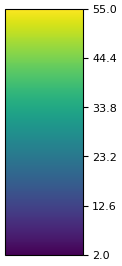
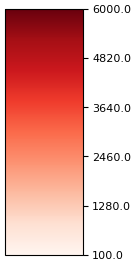
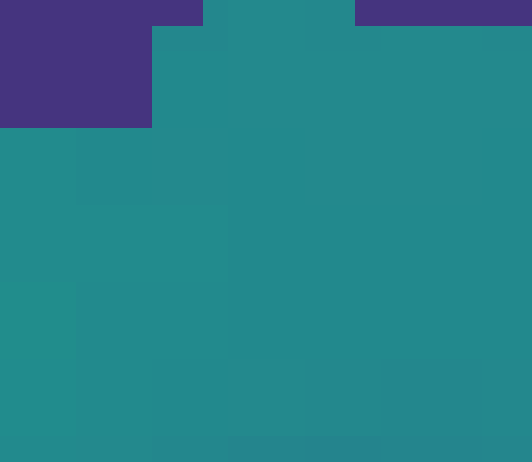
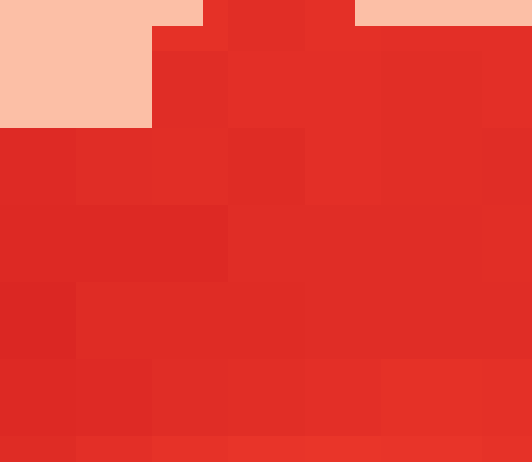
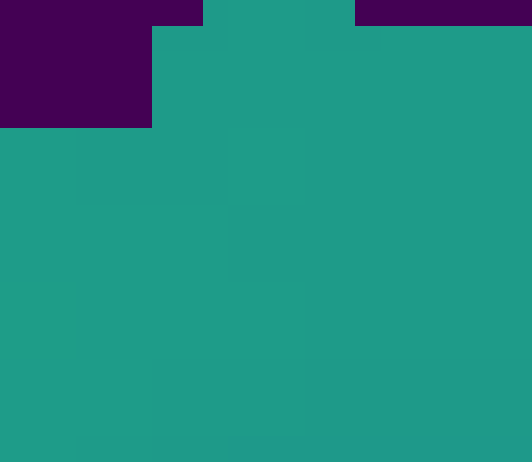
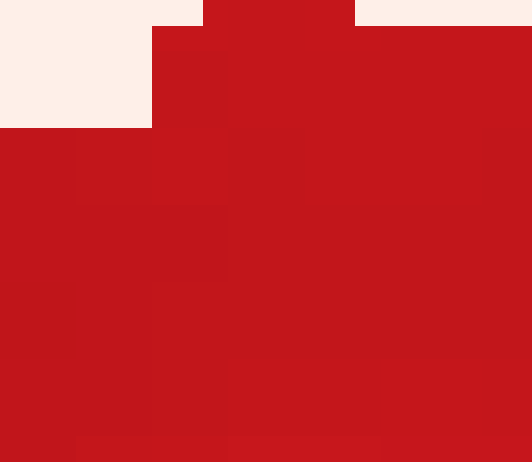
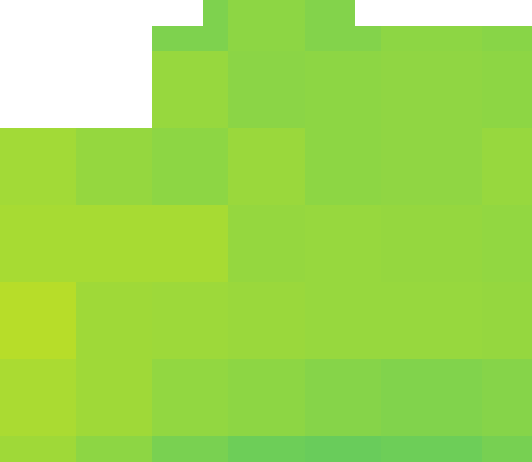
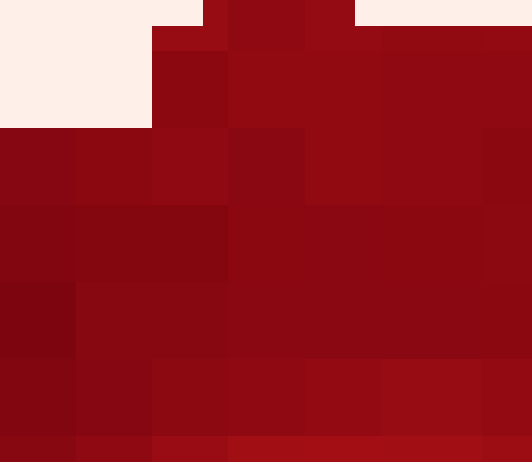

In [39]:
# Create the Folium map with custom settings
# ----------------------------------------------------

def create_folium_map_and_layers(results_dict, germany_gdf, 
                                 map_title="",
                                 overlay_opacity=0.7):
    """
    Creates a folium map, adds all relevant layers for:
      - Section 2 (50-year horizon)
      - Section 3 (100-year horizon)
    using the same naming style as the older code.

    Parameters
    ----------
    results_dict    : dict with keys:
                      - ql_NoUrban_map
                      - ql_Urban_map
                      - EnerUrb_map
                      - ql_UrbanRenew_map
                      - ql_UrbanRenew_max_map
                      - EnerUrbRenew_map
                      - extent
    germany_gdf     : GeoDataFrame for Germany boundary
    map_title       : Title to display at top of the map
    overlay_opacity : Float in [0..1], controlling overlay transparency
    """

    # 1) Basic map creation
    extent = results_dict["extent"]
    
    # Compute center lat/lon from extent
    center_lat = 0.5*(extent[2] + extent[3])
    center_lon = 0.5*(extent[0] + extent[1])
    
    m = folium.Map(location=[center_lat, center_lon], zoom_start=5, 
                   tiles="cartodbpositron")  # or any tile you prefer

    # 2) Add Germany boundary
    add_germany_boundary(m, germany_gdf, name="Germany Boundary")

    # 3) Extract arrays from results
    #ql_NoUrban_map        = results_dict["ql_NoUrban_map"]
    ql_Urban_map          = results_dict["ql_Urban_map"]
    EnerUrb_map           = results_dict["EnerUrb_map"]
    ql_UrbanRenew_map     = results_dict["ql_UrbanRenew_map"]
    ql_UrbanRenew_max_map = results_dict["ql_UrbanRenew_max_map"]
    EnerUrbRenew_map      = results_dict["EnerUrbRenew_map"]
    
    # 4) Define color scales for extraction rate and power
    #    (Adjust as needed for your data)
    ql_vmin,  ql_vmax  = 2, 55      # W/m
    pwr_vmin, pwr_vmax = 100, 6000   # W
    


    # -----------------------------
    # Section 2 (50-year horizon)
    # -----------------------------
    # 4a) No-Urban Delay
    # add_overlay_to_map(
    #     m, ql_NoUrban_map, 
    #     "ql_NoUrban (W/m)",          
    #     cmap_name="viridis", 
    #     extent=extent, 
    #     opacity=overlay_opacity, 
    #     vmin=None, 
    #     vmax=None
    # )

    # 4b) For each "urban delay" scenario: ql_Urban, EnerUrb
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))  # =0→50yrs
    arr_ql_Urban = ql_Urban_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_Urban), np.nanmax(arr_ql_Urban)
    print(f"[50-yr] ql_Urban delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    #for idx, turban in enumerate(turban_sec):
        #years = int(turban / (365*86400))
    add_overlay_to_map(
            m, arr_ql_Urban,
            f"Max Heat Extraction Rate [W/m] (no sustainable, turban = {yrs})",  
            cmap_name="viridis",
            extent=extent,
            opacity=overlay_opacity,
            vmin=ql_vmin,
            vmax=ql_vmax
        )
    # EnerUrb
    arr_EnerUrb = EnerUrb_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrb), np.nanmax(arr_EnerUrb)
    print(f"[50-yr] EnerUrb delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_EnerUrb,
            f"Usable Power [W] (turban = {yrs})",  
            cmap_name="Reds",
            extent=extent,
            opacity=overlay_opacity,
            vmin=pwr_vmin,
            vmax=pwr_vmax
        )

    # --------------------------------
    # Section 3 (100-year horizon)
    # --------------------------------
    # 4c) For each "urban delay" scenario: ql_UrbanRenew, ql_UrbanRenew_max, EnerUrbRenew
    # ----- 100-yr, idx=0 -----
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))
    #for idx, turban in enumerate(turban_sec):
        #years = int(turban / (365*86400))
     # ql_UrbanRenew
    arr_ql_UrbanRenew = ql_UrbanRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_UrbanRenew), np.nanmax(arr_ql_UrbanRenew)
    print(f"[100-yr] ql_UrbanRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_ql_UrbanRenew,
            f"Sustainable Heat Extraction Rate [W/m] (turban = {yrs})",  
            cmap_name="viridis",
            extent=extent,
            opacity=overlay_opacity,
            vmin=ql_vmin,
            vmax=ql_vmax
        )
    # EnerUrbRenew
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))
    arr_EnerUrbRenew = EnerUrbRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrbRenew), np.nanmax(arr_EnerUrbRenew)
    print(f"[100-yr] EnerUrbRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_EnerUrbRenew,
            f"Usable Power [W] under non-renewable rates (turban = {yrs})",  
            cmap_name="Reds",
            extent=extent,
            opacity=overlay_opacity,
            vmin=pwr_vmin,
            vmax=pwr_vmax
        )
        # add_overlay_to_map(
        #     m, EnerUrbRenew_map[:, :, idx],
        #     f"Usable Power under renewable rates [W] (sustainable, 100 years)turban = {years}",  
        #     cmap_name="Reds",
        #     extent=extent,
        #     opacity=overlay_opacity,
        #     vmin=None,
        #     vmax=None
        # )
    # ----- 100-yr max, idx=1 -----
    idx = 1
    yrs = int(turban_sec[idx] / (365*86400))
    # ql_UrbanRenew_max
    arr_ql_UrbanRenew_max = ql_UrbanRenew_max_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_UrbanRenew_max), np.nanmax(arr_ql_UrbanRenew_max)
    print(f"[100-yr] ql_UrbanRenew_max delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
        m, arr_ql_UrbanRenew_max,
        f"Max Sustainable Heat Extraction Rate [W/m] (turban = {yrs})",
        cmap_name="viridis", extent=extent,
        opacity=overlay_opacity, 
        vmin=ql_vmin,
        vmax=ql_vmax
    )
    # EnerUrbRenew again
    idx = 1
    yrs = int(turban_sec[idx] / (365*86400))
    arr_EnerUrbRenew_S = EnerUrbRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrbRenew_S), np.nanmax(arr_EnerUrbRenew_S)
    print(f"[100-yr] EnerUrbRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
        m, arr_EnerUrbRenew_S,
        f"Usable Power under renewable rates [W] (sustainable, turban = {yrs})",
        cmap_name="Reds", extent=extent,
        opacity=overlay_opacity, 
        vmin=pwr_vmin,
        vmax=pwr_vmax
    )

    # 5) Add a layer control so user can toggle layers
    folium.LayerControl().add_to(m)

    # 6) Add colorbar legends for ql (viridis) and power (plasma)
    add_fixed_legend(
        m, "fixed_legend_viridis",
        cmap_name="viridis",
        vmin=ql_vmin, vmax=ql_vmax,
        position='left', top_px=300,
        width=100, height=320,
        legend_title="Heat Extraction Rate (W/m)"
    )
    add_fixed_legend(
        m, "fixed_legend_Reds",
        cmap_name="Reds",
        vmin=pwr_vmin, vmax=pwr_vmax,
        position='right', top_px=300,
        width=100, height=320,
        legend_title="Usable Power (W)"
    )

    # 7) Add a title at the top
    map_title_html = f"""
    <div style="
        position: fixed;
        top: 5px;
        left: 50%;
        transform: translateX(-50%);
        z-index: 9999;
        font-size: 12px;
        font-weight: bold;
        background-color: rgba(255,255,255,0.8);
        padding: 4px;
        border: 1px solid grey;
    ">
      {map_title}
    </div>
    """
    m.get_root().html.add_child(folium.Element(map_title_html))

    return m
# Now we actually create and show the map with a custom title
custom_map_title = "Single BHE Analysis with GEE CMIP6 MIROC Model (ssp245)"
overlay_opacity  = 0.7   # Adjust as you wish

m = create_folium_map_and_layers(
    results_dict=MIROC_ssp245,
    germany_gdf=germany_shape,
    map_title=custom_map_title,
    overlay_opacity=overlay_opacity
)

m


In [40]:
# Load your GeoTIFF file and run the model (Sections 2 & 3)
# -------------------------------------------------------------------

# Provide your local file path here, including directories if needed.
geotiff_path = "MIROC_ssp585_2000_2100_Germany_mean.tif"

# Choose a downsampling factor. Larger factors speed up the computation but lose spatial detail.
ds_factor = 10

# Run the model to get the results dictionary, which includes:
#  - ql_NoUrban_map, ql_Urban_map, EnerUrb_map  (Section 2)
#  - ql_UrbanRenew_map, ql_UrbanRenew_max_map, EnerUrbRenew_map (Section 3)
MIROC_ssp585 = run_model_for_geotiff(
    geotiff_path=geotiff_path, 
    ds_factor=ds_factor
)

print("Model run completed for:", geotiff_path)
print("Results stored in 'MIROC_ssp585'")

Loaded 'MIROC_ssp585_2000_2100_Germany_mean.tif' with shape (176, 203).
Downsampled to shape: (18, 21)
Extent: (5.8839651109828655, 15.001865244796008, 47.2962997088928, 55.20147420914459)


/tmp/ipykernel_109826/3595534842.py:57: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sol_urb = fsolve(lambda ql: fzero_urban(ql, Tm_local), 10.0, xtol=1e-5)[0]


Model run completed for: MIROC_ssp585_2000_2100_Germany_mean.tif
Results stored in 'MIROC_ssp585'


[50-yr] ql_Urban delay=0yr → vmin=10.00, vmax=28.34
[50-yr] EnerUrb delay=0yr → vmin=1500.00, vmax=4250.39
[100-yr] ql_UrbanRenew delay=0yr → vmin=2.00, vmax=31.69
[100-yr] EnerUrbRenew delay=0yr → vmin=300.00, vmax=4753.31
[100-yr] ql_UrbanRenew_max delay=100yr → vmin=44.11, vmax=50.44
[100-yr] EnerUrbRenew delay=100yr → vmin=300.00, vmax=5832.05



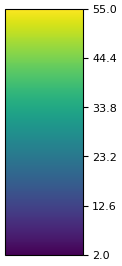
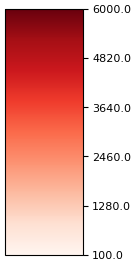
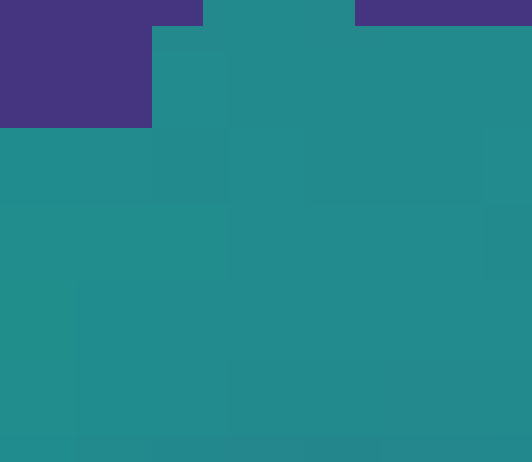
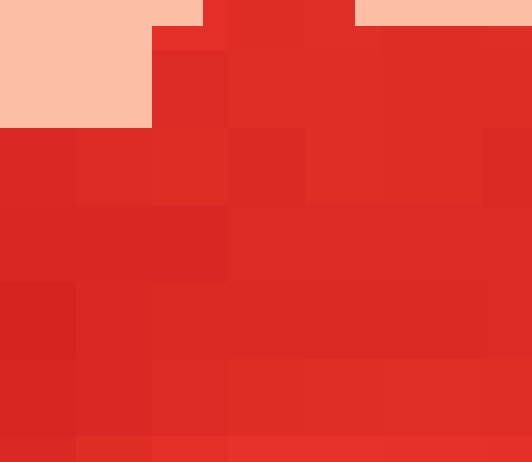
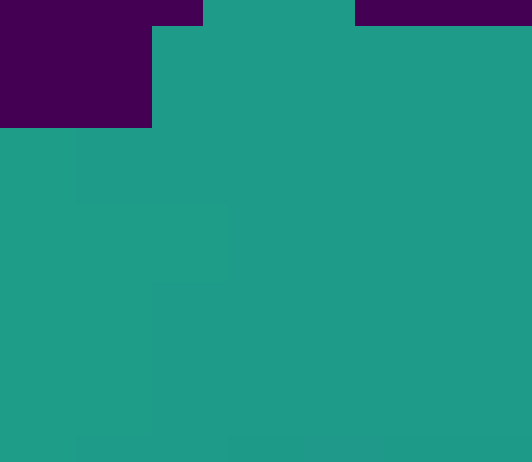
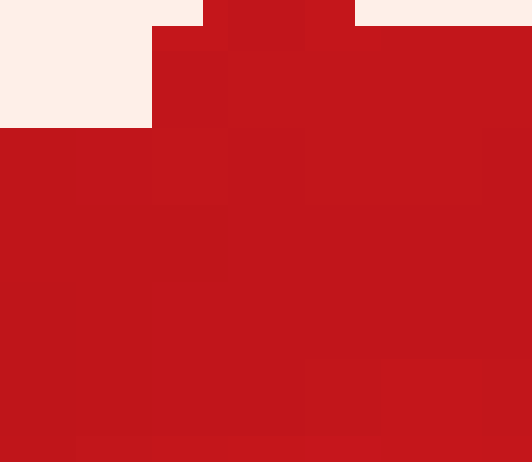
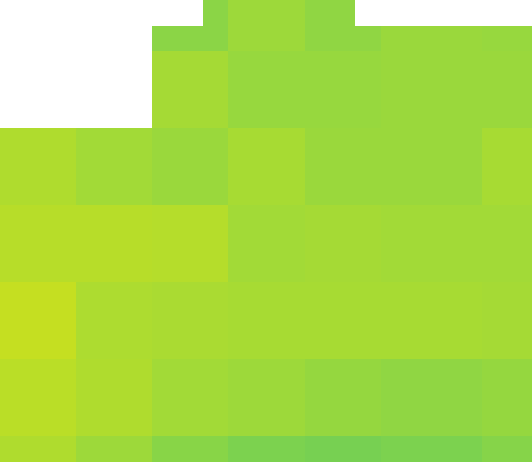
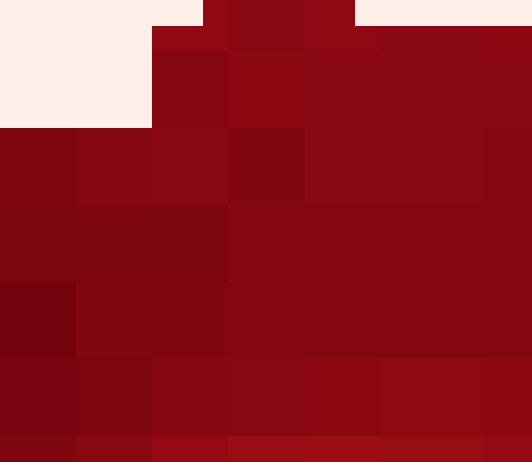

In [42]:
# Create the Folium map with custom settings
# ----------------------------------------------------

def create_folium_map_and_layers(results_dict, germany_gdf, 
                                 map_title="",
                                 overlay_opacity=0.7):
    """
    Creates a folium map, adds all relevant layers for:
      - Section 2 (50-year horizon)
      - Section 3 (100-year horizon)
    using the same naming style as the older code.

    Parameters
    ----------
    results_dict    : dict with keys:
                      - ql_NoUrban_map
                      - ql_Urban_map
                      - EnerUrb_map
                      - ql_UrbanRenew_map
                      - ql_UrbanRenew_max_map
                      - EnerUrbRenew_map
                      - extent
    germany_gdf     : GeoDataFrame for Germany boundary
    map_title       : Title to display at top of the map
    overlay_opacity : Float in [0..1], controlling overlay transparency
    """

    # 1) Basic map creation
    extent = results_dict["extent"]
    
    # Compute center lat/lon from extent
    center_lat = 0.5*(extent[2] + extent[3])
    center_lon = 0.5*(extent[0] + extent[1])
    
    m = folium.Map(location=[center_lat, center_lon], zoom_start=5, 
                   tiles="cartodbpositron")  # or any tile you prefer

    # 2) Add Germany boundary
    add_germany_boundary(m, germany_gdf, name="Germany Boundary")

    # 3) Extract arrays from results
    #ql_NoUrban_map        = results_dict["ql_NoUrban_map"]
    ql_Urban_map          = results_dict["ql_Urban_map"]
    EnerUrb_map           = results_dict["EnerUrb_map"]
    ql_UrbanRenew_map     = results_dict["ql_UrbanRenew_map"]
    ql_UrbanRenew_max_map = results_dict["ql_UrbanRenew_max_map"]
    EnerUrbRenew_map      = results_dict["EnerUrbRenew_map"]
    
    # 4) Define color scales for extraction rate and power
    #    (Adjust as needed for your data)
    ql_vmin,  ql_vmax  = 2, 55      # W/m
    pwr_vmin, pwr_vmax = 100, 6000   # W
    


    # -----------------------------
    # Section 2 (50-year horizon)
    # -----------------------------
    # 4a) No-Urban Delay
    # add_overlay_to_map(
    #     m, ql_NoUrban_map, 
    #     "ql_NoUrban (W/m)",          
    #     cmap_name="viridis", 
    #     extent=extent, 
    #     opacity=overlay_opacity, 
    #     vmin=None, 
    #     vmax=None
    # )

    # 4b) For each "urban delay" scenario: ql_Urban, EnerUrb
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))  # =0→50yrs
    arr_ql_Urban = ql_Urban_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_Urban), np.nanmax(arr_ql_Urban)
    print(f"[50-yr] ql_Urban delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    #for idx, turban in enumerate(turban_sec):
        #years = int(turban / (365*86400))
    add_overlay_to_map(
            m, arr_ql_Urban,
            f"Max Heat Extraction Rate [W/m] (no sustainable, turban = {yrs})",  
            cmap_name="viridis",
            extent=extent,
            opacity=overlay_opacity,
            vmin=ql_vmin,
            vmax=ql_vmax
        )
    # EnerUrb
    arr_EnerUrb = EnerUrb_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrb), np.nanmax(arr_EnerUrb)
    print(f"[50-yr] EnerUrb delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_EnerUrb,
            f"Usable Power [W] (turban = {yrs})",  
            cmap_name="Reds",
            extent=extent,
            opacity=overlay_opacity,
            vmin=pwr_vmin,
            vmax=pwr_vmax
        )

    # --------------------------------
    # Section 3 (100-year horizon)
    # --------------------------------
    # 4c) For each "urban delay" scenario: ql_UrbanRenew, ql_UrbanRenew_max, EnerUrbRenew
    # ----- 100-yr, idx=0 -----
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))
    #for idx, turban in enumerate(turban_sec):
        #years = int(turban / (365*86400))
     # ql_UrbanRenew
    arr_ql_UrbanRenew = ql_UrbanRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_UrbanRenew), np.nanmax(arr_ql_UrbanRenew)
    print(f"[100-yr] ql_UrbanRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_ql_UrbanRenew,
            f"Sustainable Heat Extraction Rate [W/m] (turban = {yrs})",  
            cmap_name="viridis",
            extent=extent,
            opacity=overlay_opacity,
            vmin=ql_vmin,
            vmax=ql_vmax
        )
    # EnerUrbRenew
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))
    arr_EnerUrbRenew = EnerUrbRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrbRenew), np.nanmax(arr_EnerUrbRenew)
    print(f"[100-yr] EnerUrbRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_EnerUrbRenew,
            f"Usable Power [W] under non-renewable rates (turban = {yrs})",  
            cmap_name="Reds",
            extent=extent,
            opacity=overlay_opacity,
            vmin=pwr_vmin,
            vmax=pwr_vmax
        )
        # add_overlay_to_map(
        #     m, EnerUrbRenew_map[:, :, idx],
        #     f"Usable Power under renewable rates [W] (sustainable, 100 years)turban = {years}",  
        #     cmap_name="Reds",
        #     extent=extent,
        #     opacity=overlay_opacity,
        #     vmin=None,
        #     vmax=None
        # )
    # ----- 100-yr max, idx=1 -----
    idx = 1
    yrs = int(turban_sec[idx] / (365*86400))
    # ql_UrbanRenew_max
    arr_ql_UrbanRenew_max = ql_UrbanRenew_max_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_UrbanRenew_max), np.nanmax(arr_ql_UrbanRenew_max)
    print(f"[100-yr] ql_UrbanRenew_max delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
        m, arr_ql_UrbanRenew_max,
        f"Max Sustainable Heat Extraction Rate [W/m] (turban = {yrs})",
        cmap_name="viridis", extent=extent,
        opacity=overlay_opacity, 
        vmin=ql_vmin,
        vmax=ql_vmax
    )
    # EnerUrbRenew again
    idx = 1
    yrs = int(turban_sec[idx] / (365*86400))
    arr_EnerUrbRenew_S = EnerUrbRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrbRenew_S), np.nanmax(arr_EnerUrbRenew_S)
    print(f"[100-yr] EnerUrbRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
        m, arr_EnerUrbRenew_S,
        f"Usable Power under renewable rates [W] (sustainable, turban = {yrs})",
        cmap_name="Reds", extent=extent,
        opacity=overlay_opacity, 
        vmin=pwr_vmin,
        vmax=pwr_vmax
    )

    # 5) Add a layer control so user can toggle layers
    folium.LayerControl().add_to(m)

    # 6) Add colorbar legends for ql (viridis) and power (plasma)
    add_fixed_legend(
        m, "fixed_legend_viridis",
        cmap_name="viridis",
        vmin=ql_vmin, vmax=ql_vmax,
        position='left', top_px=300,
        width=100, height=320,
        legend_title="Heat Extraction Rate (W/m)"
    )
    add_fixed_legend(
        m, "fixed_legend_Reds",
        cmap_name="Reds",
        vmin=pwr_vmin, vmax=pwr_vmax,
        position='right', top_px=300,
        width=100, height=320,
        legend_title="Usable Power (W)"
    )

    # 7) Add a title at the top
    map_title_html = f"""
    <div style="
        position: fixed;
        top: 5px;
        left: 50%;
        transform: translateX(-50%);
        z-index: 9999;
        font-size: 12px;
        font-weight: bold;
        background-color: rgba(255,255,255,0.8);
        padding: 4px;
        border: 1px solid grey;
    ">
      {map_title}
    </div>
    """
    m.get_root().html.add_child(folium.Element(map_title_html))

    return m
# Now we actually create and show the map with a custom title
custom_map_title = "Single BHE Analysis with GEE CMIP6 MIROC Model (ssp585)"
overlay_opacity  = 0.7   # Adjust as you wish

m = create_folium_map_and_layers(
    results_dict=MIROC_ssp585,
    germany_gdf=germany_shape,
    map_title=custom_map_title,
    overlay_opacity=overlay_opacity
)

m


In [43]:
# Load your GeoTIFF file and run the model (Sections 2 & 3)
# -------------------------------------------------------------------

# Provide your local file path here, including directories if needed.
geotiff_path = "MPI_ssp245_2000_2100_Germany_mean.tif"

# Choose a downsampling factor. Larger factors speed up the computation but lose spatial detail.
ds_factor = 10

# Run the model to get the results dictionary, which includes:
#  - ql_NoUrban_map, ql_Urban_map, EnerUrb_map  (Section 2)
#  - ql_UrbanRenew_map, ql_UrbanRenew_max_map, EnerUrbRenew_map (Section 3)
MPI_ssp245 = run_model_for_geotiff(
    geotiff_path=geotiff_path, 
    ds_factor=ds_factor
)

print("Model run completed for:", geotiff_path)
print("Results stored in 'MPI_ssp245'")

Loaded 'MPI_ssp245_2000_2100_Germany_mean.tif' with shape (176, 203).
Downsampled to shape: (18, 21)
Extent: (5.8839651109828655, 15.001865244796008, 47.2962997088928, 55.20147420914459)


/tmp/ipykernel_109826/3595534842.py:57: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sol_urb = fsolve(lambda ql: fzero_urban(ql, Tm_local), 10.0, xtol=1e-5)[0]


Model run completed for: MPI_ssp245_2000_2100_Germany_mean.tif
Results stored in 'MPI_ssp245'


In [ ]:
# Create the Folium map with custom settings
# ----------------------------------------------------

def create_folium_map_and_layers(results_dict, germany_gdf, 
                                 map_title="",
                                 overlay_opacity=0.7):
    """
    Creates a folium map, adds all relevant layers for:
      - Section 2 (50-year horizon)
      - Section 3 (100-year horizon)
    using the same naming style as the older code.

    Parameters
    ----------
    results_dict    : dict with keys:
                      - ql_NoUrban_map
                      - ql_Urban_map
                      - EnerUrb_map
                      - ql_UrbanRenew_map
                      - ql_UrbanRenew_max_map
                      - EnerUrbRenew_map
                      - extent
    germany_gdf     : GeoDataFrame for Germany boundary
    map_title       : Title to display at top of the map
    overlay_opacity : Float in [0..1], controlling overlay transparency
    """

    # 1) Basic map creation
    extent = results_dict["extent"]
    
    # Compute center lat/lon from extent
    center_lat = 0.5*(extent[2] + extent[3])
    center_lon = 0.5*(extent[0] + extent[1])
    
    m = folium.Map(location=[center_lat, center_lon], zoom_start=5, 
                   tiles="cartodbpositron")  # or any tile you prefer

    # 2) Add Germany boundary
    add_germany_boundary(m, germany_gdf, name="Germany Boundary")

    # 3) Extract arrays from results
    #ql_NoUrban_map        = results_dict["ql_NoUrban_map"]
    ql_Urban_map          = results_dict["ql_Urban_map"]
    EnerUrb_map           = results_dict["EnerUrb_map"]
    ql_UrbanRenew_map     = results_dict["ql_UrbanRenew_map"]
    ql_UrbanRenew_max_map = results_dict["ql_UrbanRenew_max_map"]
    EnerUrbRenew_map      = results_dict["EnerUrbRenew_map"]
    
    # 4) Define color scales for extraction rate and power
    #    (Adjust as needed for your data)
    ql_vmin,  ql_vmax  = 2, 55      # W/m
    pwr_vmin, pwr_vmax = 100, 6000   # W
    


    # -----------------------------
    # Section 2 (50-year horizon)
    # -----------------------------
    # 4a) No-Urban Delay
    # add_overlay_to_map(
    #     m, ql_NoUrban_map, 
    #     "ql_NoUrban (W/m)",          
    #     cmap_name="viridis", 
    #     extent=extent, 
    #     opacity=overlay_opacity, 
    #     vmin=None, 
    #     vmax=None
    # )

    # 4b) For each "urban delay" scenario: ql_Urban, EnerUrb
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))  # =0→50yrs
    arr_ql_Urban = ql_Urban_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_Urban), np.nanmax(arr_ql_Urban)
    print(f"[50-yr] ql_Urban delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    #for idx, turban in enumerate(turban_sec):
        #years = int(turban / (365*86400))
    add_overlay_to_map(
            m, arr_ql_Urban,
            f"Max Heat Extraction Rate [W/m] (no sustainable, turban = {yrs})",  
            cmap_name="viridis",
            extent=extent,
            opacity=overlay_opacity,
            vmin=ql_vmin,
            vmax=ql_vmax
        )
    # EnerUrb
    arr_EnerUrb = EnerUrb_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrb), np.nanmax(arr_EnerUrb)
    print(f"[50-yr] EnerUrb delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_EnerUrb,
            f"Usable Power [W] (turban = {yrs})",  
            cmap_name="Reds",
            extent=extent,
            opacity=overlay_opacity,
            vmin=pwr_vmin,
            vmax=pwr_vmax
        )

    # --------------------------------
    # Section 3 (100-year horizon)
    # --------------------------------
    # 4c) For each "urban delay" scenario: ql_UrbanRenew, ql_UrbanRenew_max, EnerUrbRenew
    # ----- 100-yr, idx=0 -----
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))
    #for idx, turban in enumerate(turban_sec):
        #years = int(turban / (365*86400))
     # ql_UrbanRenew
    arr_ql_UrbanRenew = ql_UrbanRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_UrbanRenew), np.nanmax(arr_ql_UrbanRenew)
    print(f"[100-yr] ql_UrbanRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_ql_UrbanRenew,
            f"Sustainable Heat Extraction Rate [W/m] (turban = {yrs})",  
            cmap_name="viridis",
            extent=extent,
            opacity=overlay_opacity,
            vmin=ql_vmin,
            vmax=ql_vmax
        )
    # EnerUrbRenew
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))
    arr_EnerUrbRenew = EnerUrbRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrbRenew), np.nanmax(arr_EnerUrbRenew)
    print(f"[100-yr] EnerUrbRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_EnerUrbRenew,
            f"Usable Power [W] under non-renewable rates (turban = {yrs})",  
            cmap_name="Reds",
            extent=extent,
            opacity=overlay_opacity,
            vmin=pwr_vmin,
            vmax=pwr_vmax
        )
        # add_overlay_to_map(
        #     m, EnerUrbRenew_map[:, :, idx],
        #     f"Usable Power under renewable rates [W] (sustainable, 100 years)turban = {years}",  
        #     cmap_name="Reds",
        #     extent=extent,
        #     opacity=overlay_opacity,
        #     vmin=None,
        #     vmax=None
        # )
    # ----- 100-yr max, idx=1 -----
    idx = 1
    yrs = int(turban_sec[idx] / (365*86400))
    # ql_UrbanRenew_max
    arr_ql_UrbanRenew_max = ql_UrbanRenew_max_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_UrbanRenew_max), np.nanmax(arr_ql_UrbanRenew_max)
    print(f"[100-yr] ql_UrbanRenew_max delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
        m, arr_ql_UrbanRenew_max,
        f"Max Sustainable Heat Extraction Rate [W/m] (turban = {yrs})",
        cmap_name="viridis", extent=extent,
        opacity=overlay_opacity, 
        vmin=ql_vmin,
        vmax=ql_vmax
    )
    # EnerUrbRenew again
    idx = 1
    yrs = int(turban_sec[idx] / (365*86400))
    arr_EnerUrbRenew_S = EnerUrbRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrbRenew_S), np.nanmax(arr_EnerUrbRenew_S)
    print(f"[100-yr] EnerUrbRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
        m, arr_EnerUrbRenew_S,
        f"Usable Power under renewable rates [W] (sustainable, turban = {yrs})",
        cmap_name="Reds", extent=extent,
        opacity=overlay_opacity, 
        vmin=pwr_vmin,
        vmax=pwr_vmax
    )

    # 5) Add a layer control so user can toggle layers
    folium.LayerControl().add_to(m)

    # 6) Add colorbar legends for ql (viridis) and power (plasma)
    add_fixed_legend(
        m, "fixed_legend_viridis",
        cmap_name="viridis",
        vmin=ql_vmin, vmax=ql_vmax,
        position='left', top_px=300,
        width=100, height=320,
        legend_title="Heat Extraction Rate (W/m)"
    )
    add_fixed_legend(
        m, "fixed_legend_Reds",
        cmap_name="Reds",
        vmin=pwr_vmin, vmax=pwr_vmax,
        position='right', top_px=300,
        width=100, height=320,
        legend_title="Usable Power (W)"
    )

    # 8) Add a title at the top
    map_title_html = f"""
    <div style="
        position: fixed;
        top: 5px;
        left: 50%;
        transform: translateX(-50%);
        z-index: 9999;
        font-size: 12px;
        font-weight: bold;
        background-color: rgba(255,255,255,0.8);
        padding: 4px;
        border: 1px solid grey;
    ">
      {map_title}
    </div>
    """
    m.get_root().html.add_child(folium.Element(map_title_html))

    return m
# Now we actually create and show the map with a custom title
custom_map_title = "Single BHE Analysis with GEE CMIP6 MPI Model (ssp245)"
overlay_opacity  = 0.7   # Adjust as you wish

m = create_folium_map_and_layers(
    results_dict=MPI_ssp245,
    germany_gdf=germany_shape,
    map_title=custom_map_title,
    overlay_opacity=overlay_opacity
)

m


In [ ]:
# Load your GeoTIFF file and run the model (Sections 2 & 3)
# -------------------------------------------------------------------

# Provide your local file path here, including directories if needed.
geotiff_path = "MPI_ssp585_2000_2100_Germany_mean.tif"

# Choose a downsampling factor. Larger factors speed up the computation but lose spatial detail.
ds_factor = 10

# Run the model to get the results dictionary, which includes:
#  - ql_NoUrban_map, ql_Urban_map, EnerUrb_map  (Section 2)
#  - ql_UrbanRenew_map, ql_UrbanRenew_max_map, EnerUrbRenew_map (Section 3)
MPI_ssp585 = run_model_for_geotiff(
    geotiff_path=geotiff_path, 
    ds_factor=ds_factor
)

print("Model run completed for:", geotiff_path)
print("Results stored in 'MPI_ssp585'")

In [ ]:
# Create the Folium map with custom settings
# ----------------------------------------------------

def create_folium_map_and_layers(results_dict, germany_gdf, 
                                 map_title="",
                                 overlay_opacity=0.7):
    """
    Creates a folium map, adds all relevant layers for:
      - Section 2 (50-year horizon)
      - Section 3 (100-year horizon)
    using the same naming style as the older code.

    Parameters
    ----------
    results_dict    : dict with keys:
                      - ql_NoUrban_map
                      - ql_Urban_map
                      - EnerUrb_map
                      - ql_UrbanRenew_map
                      - ql_UrbanRenew_max_map
                      - EnerUrbRenew_map
                      - extent
    germany_gdf     : GeoDataFrame for Germany boundary
    map_title       : Title to display at top of the map
    overlay_opacity : Float in [0..1], controlling overlay transparency
    """

    # 1) Basic map creation
    extent = results_dict["extent"]
    
    # Compute center lat/lon from extent
    center_lat = 0.5*(extent[2] + extent[3])
    center_lon = 0.5*(extent[0] + extent[1])
    
    m = folium.Map(location=[center_lat, center_lon], zoom_start=5, 
                   tiles="cartodbpositron")  # or any tile you prefer

    # 2) Add Germany boundary
    add_germany_boundary(m, germany_gdf, name="Germany Boundary")

    # 3) Extract arrays from results
    #ql_NoUrban_map        = results_dict["ql_NoUrban_map"]
    ql_Urban_map          = results_dict["ql_Urban_map"]
    EnerUrb_map           = results_dict["EnerUrb_map"]
    ql_UrbanRenew_map     = results_dict["ql_UrbanRenew_map"]
    ql_UrbanRenew_max_map = results_dict["ql_UrbanRenew_max_map"]
    EnerUrbRenew_map      = results_dict["EnerUrbRenew_map"]
    
    # 4) Define color scales for extraction rate and power
    #    (Adjust as needed for your data)
    ql_vmin,  ql_vmax  = 2, 55      # W/m
    pwr_vmin, pwr_vmax = 100, 6000   # W
    


    # -----------------------------
    # Section 2 (50-year horizon)
    # -----------------------------
    # 4a) No-Urban Delay
    # add_overlay_to_map(
    #     m, ql_NoUrban_map, 
    #     "ql_NoUrban (W/m)",          
    #     cmap_name="viridis", 
    #     extent=extent, 
    #     opacity=overlay_opacity, 
    #     vmin=None, 
    #     vmax=None
    # )

    # 4b) For each "urban delay" scenario: ql_Urban, EnerUrb
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))  # =0→50yrs
    arr_ql_Urban = ql_Urban_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_Urban), np.nanmax(arr_ql_Urban)
    print(f"[50-yr] ql_Urban delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    #for idx, turban in enumerate(turban_sec):
        #years = int(turban / (365*86400))
    add_overlay_to_map(
            m, arr_ql_Urban,
            f"Max Heat Extraction Rate [W/m] (no sustainable, turban = {yrs})",  
            cmap_name="viridis",
            extent=extent,
            opacity=overlay_opacity,
            vmin=ql_vmin,
            vmax=ql_vmax
        )
    # EnerUrb
    arr_EnerUrb = EnerUrb_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrb), np.nanmax(arr_EnerUrb)
    print(f"[50-yr] EnerUrb delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_EnerUrb,
            f"Usable Power [W] (turban = {yrs})",  
            cmap_name="Reds",
            extent=extent,
            opacity=overlay_opacity,
            vmin=pwr_vmin,
            vmax=pwr_vmax
        )

    # --------------------------------
    # Section 3 (100-year horizon)
    # --------------------------------
    # 4c) For each "urban delay" scenario: ql_UrbanRenew, ql_UrbanRenew_max, EnerUrbRenew
    # ----- 100-yr, idx=0 -----
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))
    #for idx, turban in enumerate(turban_sec):
        #years = int(turban / (365*86400))
     # ql_UrbanRenew
    arr_ql_UrbanRenew = ql_UrbanRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_UrbanRenew), np.nanmax(arr_ql_UrbanRenew)
    print(f"[100-yr] ql_UrbanRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_ql_UrbanRenew,
            f"Sustainable Heat Extraction Rate [W/m] (turban = {yrs})",  
            cmap_name="viridis",
            extent=extent,
            opacity=overlay_opacity,
            vmin=ql_vmin,
            vmax=ql_vmax
        )
    # EnerUrbRenew
    idx = 0
    yrs = int(turban_sec[idx] / (365*86400))
    arr_EnerUrbRenew = EnerUrbRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrbRenew), np.nanmax(arr_EnerUrbRenew)
    print(f"[100-yr] EnerUrbRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
            m, arr_EnerUrbRenew,
            f"Usable Power [W] under non-renewable rates (turban = {yrs})",  
            cmap_name="Reds",
            extent=extent,
            opacity=overlay_opacity,
            vmin=pwr_vmin,
            vmax=pwr_vmax
        )
        # add_overlay_to_map(
        #     m, EnerUrbRenew_map[:, :, idx],
        #     f"Usable Power under renewable rates [W] (sustainable, 100 years)turban = {years}",  
        #     cmap_name="Reds",
        #     extent=extent,
        #     opacity=overlay_opacity,
        #     vmin=None,
        #     vmax=None
        # )
    # ----- 100-yr max, idx=1 -----
    idx = 1
    yrs = int(turban_sec[idx] / (365*86400))
    # ql_UrbanRenew_max
    arr_ql_UrbanRenew_max = ql_UrbanRenew_max_map[:, :, idx]
    mn, mx = np.nanmin(arr_ql_UrbanRenew_max), np.nanmax(arr_ql_UrbanRenew_max)
    print(f"[100-yr] ql_UrbanRenew_max delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
        m, arr_ql_UrbanRenew_max,
        f"Max Sustainable Heat Extraction Rate [W/m] (turban = {yrs})",
        cmap_name="viridis", extent=extent,
        opacity=overlay_opacity, 
        vmin=ql_vmin,
        vmax=ql_vmax
    )
    # EnerUrbRenew again
    idx = 1
    yrs = int(turban_sec[idx] / (365*86400))
    arr_EnerUrbRenew_S = EnerUrbRenew_map[:, :, idx]
    mn, mx = np.nanmin(arr_EnerUrbRenew_S), np.nanmax(arr_EnerUrbRenew_S)
    print(f"[100-yr] EnerUrbRenew delay={yrs}yr → vmin={mn:.2f}, vmax={mx:.2f}")
    add_overlay_to_map(
        m, arr_EnerUrbRenew_S,
        f"Usable Power under renewable rates [W] (sustainable, turban = {yrs})",
        cmap_name="Reds", extent=extent,
        opacity=overlay_opacity, 
        vmin=pwr_vmin,
        vmax=pwr_vmax
    )

    # 5) Add a layer control so user can toggle layers
    folium.LayerControl().add_to(m)

    # 6) Add colorbar legends for ql (viridis) and power (plasma)
    add_fixed_legend(
        m, "fixed_legend_viridis",
        cmap_name="viridis",
        vmin=ql_vmin, vmax=ql_vmax,
        position='left', top_px=300,
        width=100, height=320,
        legend_title="Heat Extraction Rate (W/m)"
    )
    add_fixed_legend(
        m, "fixed_legend_Reds",
        cmap_name="Reds",
        vmin=pwr_vmin, vmax=pwr_vmax,
        position='right', top_px=300,
        width=100, height=320,
        legend_title="Usable Power (W)"
    )

    # 7) Add a title at the top
    map_title_html = f"""
    <div style="
        position: fixed;
        top: 5px;
        left: 50%;
        transform: translateX(-50%);
        z-index: 9999;
        font-size: 12px;
        font-weight: bold;
        background-color: rgba(255,255,255,0.8);
        padding: 4px;
        border: 1px solid grey;
    ">
      {map_title}
    </div>
    """
    m.get_root().html.add_child(folium.Element(map_title_html))

    return m
# Now we actually create and show the map with a custom title
custom_map_title = "Single BHE Analysis with GEE CMIP6 MPI Model (ssp585)"
overlay_opacity  = 0.7   # Adjust as you wish

m = create_folium_map_and_layers(
    results_dict=MPI_ssp585,
    germany_gdf=germany_shape,
    map_title=custom_map_title,
    overlay_opacity=overlay_opacity
)

m


In [ ]:
from IPython.display import display
import numpy as np
import folium

# 1) fixed title & opacity:
custom_map_title = "Single BHE Analysis with GEE CMIP6 All Models (ssp245)"
overlay_opacity  = 0.7   # Adjust as you wish

# 2) List of already‐loaded model result dicts
models = [
    BBC_ssp245,
    CanESM_ssp245,
    GFDL_ssp245,
    GISS_ssp245,
    HadGEM_ssp245,
    IPSL_ssp245,
    MIROC_ssp245,
    MPI_ssp245
]

# 3) Fixed global colorbar limits
ql_vmin,  ql_vmax  = 2,   55     # W/m
pwr_vmin, pwr_vmax = 100, 6000   # W

# 4) The six panels: (dict_key, ensemble‐index, legend‐title, cmap)
panels = [
    ("ql_Urban_map",        0, "Max Heat Extraction Rate [W/m] (no sustainable, turban = 0 years)", "viridis"),
    ("EnerUrb_map",         0, "Usable Power [W] (turban = 0 years)",                     "Reds"),
    ("ql_UrbanRenew_map",   0, "Sustainable Heat Extraction Rate [W/m] (turban = 0 years)", "viridis"),
    ("EnerUrbRenew_map",    0, "Usable Power [W] under non-renewable rates (turban = 0 years)", "Reds"),
    ("ql_UrbanRenew_max_map", 1, "Max Sustainable Heat Extraction Rate [W/m] (turban = 100 years)", "viridis"),
    ("EnerUrbRenew_map",    1, "Usable Power under renewable rates [W] (sustainable, turban = 100 years)", "Reds"),
]

# 5) Shared extent + center
extent     = models[0]["extent"]
center_lat = 0.5*(extent[2] + extent[3])
center_lon = 0.5*(extent[0] + extent[1])

# 6) Compute all stats once:
#    stats_dict[(key,idx)] = (mean, p25, p50, p75)
stats_dict = {}
for key, idx, title, cmap in panels:
    arrs  = [m[key][:,:,idx] for m in models]
    stack = np.stack(arrs, axis=0)
    mean = np.nanmean(stack, axis=0)
    p25, p50, p75 = np.nanpercentile(stack, [25,50,75], axis=0)
    stats_dict[(key,idx)] = (mean, p25, p50, p75)

# 7) Helper to build one map for a given statistic index:
def make_stat_map(stat_index, stat_name, map_title):
    m = folium.Map(location=[center_lat, center_lon], zoom_start=5,
                   tiles="cartodbpositron")
    add_germany_boundary(m, germany_shape, name="Germany Boundary")

    for key, idx, legend_title, cmap in panels:
        arr = stats_dict[(key,idx)][stat_index]
        mn, mx = np.nanmin(arr), np.nanmax(arr)
        print(f"{legend_title} ({stat_name}) → vmin={mn:.2f}, vmax={mx:.2f}")

        add_overlay_to_map(
            m, arr,
            f"{stat_name} • {legend_title}",
            cmap_name=cmap, extent=extent,
            opacity=overlay_opacity,
            vmin=(ql_vmin if key.startswith("ql_") else pwr_vmin),
            vmax=(ql_vmax if key.startswith("ql_") else pwr_vmax)
        )

    folium.LayerControl().add_to(m)

    # two fixed legends (same global range for all panels)
    add_fixed_legend(
        m, f"legend_ql_{stat_name}", "viridis",
        vmin=ql_vmin, vmax=ql_vmax,
        position='left', top_px=300,
        width=100, height=320,
        legend_title=f"Heat Extraction ({stat_name})"
    )
    add_fixed_legend(
        m, f"legend_pw_{stat_name}", "Reds",
        vmin=pwr_vmin, vmax=pwr_vmax,
        position='right', top_px=300,
        width=100, height=320,
        legend_title=f"Usable Power ({stat_name})"
    )

    # **HERE** use the **custom** map_title plus the statistic name
    title_html = f"""
      <div style="
         position: fixed;
         top: 5px;
         left: 50%;
         transform: translateX(-50%);
         z-index: 10000;
         background-color: rgba(255,255,255,0.85);
         padding: 4px;
         border: 1px solid #888;
         border-radius: 4px;
         font-size: 12px;
         font-weight: bold;
      ">
        {map_title} — {stat_name.upper()}
      </div>
    """
    m.get_root().html.add_child(folium.Element(title_html))
    return m

# 8) Build & display the four maps with their own titles
for idx, name in enumerate(["mean","25th pct","50th pct","75th pct"]):
    print(f"\n=== {name.upper()} MAP ===")
    m = make_stat_map(idx, name, custom_map_title)
    display(m)


In [ ]:
from IPython.display import display
import numpy as np
import folium

# 1) fixed title & opacity:
custom_map_title = "Single BHE Analysis with GEE CMIP6 All Models (ssp585)"
overlay_opacity  = 0.7   # Adjust as you wish

# 2) List of already‐loaded model result dicts
models = [
    BBC_ssp585,
    CanESM_ssp585,
    GFDL_ssp585,
    GISS_ssp585,
    HadGEM_ssp585,
    IPSL_ssp585,
    MIROC_ssp585,
    MPI_ssp585
]

# 3) Fixed global colorbar limits
ql_vmin,  ql_vmax  = 2,   55     # W/m
pwr_vmin, pwr_vmax = 100, 6000   # W

# 4) The six panels: (dict_key, ensemble‐index, legend‐title, cmap)
panels = [
    ("ql_Urban_map",        0, "Max Heat Extraction Rate [W/m] (no sustainable, turban = 0 years)", "viridis"),
    ("EnerUrb_map",         0, "Usable Power [W] (turban = 0 years)",                     "Reds"),
    ("ql_UrbanRenew_map",   0, "Sustainable Heat Extraction Rate [W/m] (turban = 0 years)", "viridis"),
    ("EnerUrbRenew_map",    0, "Usable Power [W] under non-renewable rates (turban = 0 years)", "Reds"),
    ("ql_UrbanRenew_max_map", 1, "Max Sustainable Heat Extraction Rate [W/m] (turban = 100 years)", "viridis"),
    ("EnerUrbRenew_map",    1, "Usable Power under renewable rates [W] (sustainable, turban = 100 years)", "Reds"),
]

# 5) Shared extent + center
extent     = models[0]["extent"]
center_lat = 0.5*(extent[2] + extent[3])
center_lon = 0.5*(extent[0] + extent[1])

# 6) Compute all stats once:
#    stats_dict[(key,idx)] = (mean, p25, p50, p75)
stats_dict = {}
for key, idx, title, cmap in panels:
    arrs  = [m[key][:,:,idx] for m in models]
    stack = np.stack(arrs, axis=0)
    mean = np.nanmean(stack, axis=0)
    p25, p50, p75 = np.nanpercentile(stack, [25,50,75], axis=0)
    stats_dict[(key,idx)] = (mean, p25, p50, p75)

# 7) Helper to build one map for a given statistic index:
def make_stat_map(stat_index, stat_name, map_title):
    m = folium.Map(location=[center_lat, center_lon], zoom_start=5,
                   tiles="cartodbpositron")
    add_germany_boundary(m, germany_shape, name="Germany Boundary")

    for key, idx, legend_title, cmap in panels:
        arr = stats_dict[(key,idx)][stat_index]
        mn, mx = np.nanmin(arr), np.nanmax(arr)
        print(f"{legend_title} ({stat_name}) → vmin={mn:.2f}, vmax={mx:.2f}")

        add_overlay_to_map(
            m, arr,
            f"{stat_name} • {legend_title}",
            cmap_name=cmap, extent=extent,
            opacity=overlay_opacity,
            vmin=(ql_vmin if key.startswith("ql_") else pwr_vmin),
            vmax=(ql_vmax if key.startswith("ql_") else pwr_vmax)
        )

    folium.LayerControl().add_to(m)

    # two fixed legends (same global range for all panels)
    add_fixed_legend(
        m, f"legend_ql_{stat_name}", "viridis",
        vmin=ql_vmin, vmax=ql_vmax,
        position='left', top_px=300,
        width=100, height=320,
        legend_title=f"Heat Extraction ({stat_name})"
    )
    add_fixed_legend(
        m, f"legend_pw_{stat_name}", "Reds",
        vmin=pwr_vmin, vmax=pwr_vmax,
        position='right', top_px=300,
        width=100, height=320,
        legend_title=f"Usable Power ({stat_name})"
    )

    # **HERE** we use the **custom** map_title plus the statistic name
    title_html = f"""
      <div style="
         position: fixed;
         top: 5px;
         left: 50%;
         transform: translateX(-50%);
         z-index: 10000;
         background-color: rgba(255,255,255,0.85);
         padding: 4px;
         border: 1px solid #888;
         border-radius: 4px;
         font-size: 12px;
         font-weight: bold;
      ">
        {map_title} — {stat_name.upper()}
      </div>
    """
    m.get_root().html.add_child(folium.Element(title_html))
    return m

# 8) Build & display the four maps with their own titles
for idx, name in enumerate(["mean","25th pct","50th pct","75th pct"]):
    print(f"\n=== {name.upper()} MAP ===")
    m = make_stat_map(idx, name, custom_map_title)
    display(m)
